<a href="https://colab.research.google.com/github/diegormsouza/gnc-a-caribbean/blob/main/INPE_Caribbean_Ocean_May_2023.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

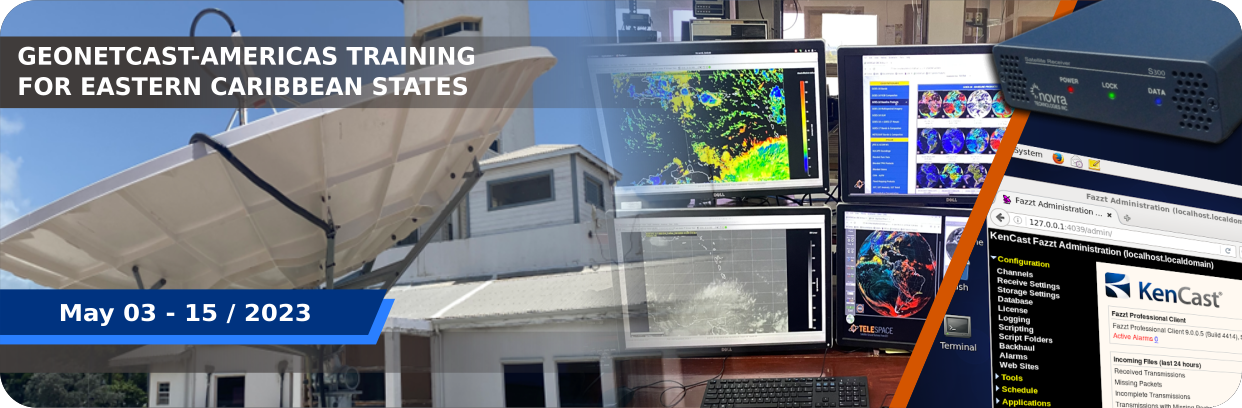

## **OCEANOGRAPHY DATA PROCESSING WITH PYTHON** 
Developed by: INPE / CGCT / DISSM - Brazil

COLAB Notebook Version: March 2023

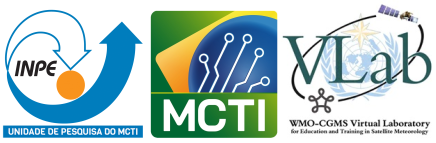

### **Contact:** Diego Souza - INPE / CGCT / DISSM - (diego.souza@inpe.br)
https://github.com/diegormsouza/Oceanography_Python_May_2022

# **Introduction**

Welcome to the **"Oceanography Data Processing With Python"** COLAB Notebook!

---


This interactive COLAB notebook contains instructions for installing the tools needed to create Python scripts to manipulate oceanography data. All instructions and scripts run in the cloud, and there is no need to install tools and download files locally. To execute the instructions, just click on the "Play" icon in square brackets on the left of each cell.

# **Course Slides (May 2022)**

Please download the course slides (Brazilian Portuguese) at the following link:

https://geonetcast.wordpress.com/2022/06/08/vlab-produtos-de-oceanografia-por-satelite-conteudo-completo/

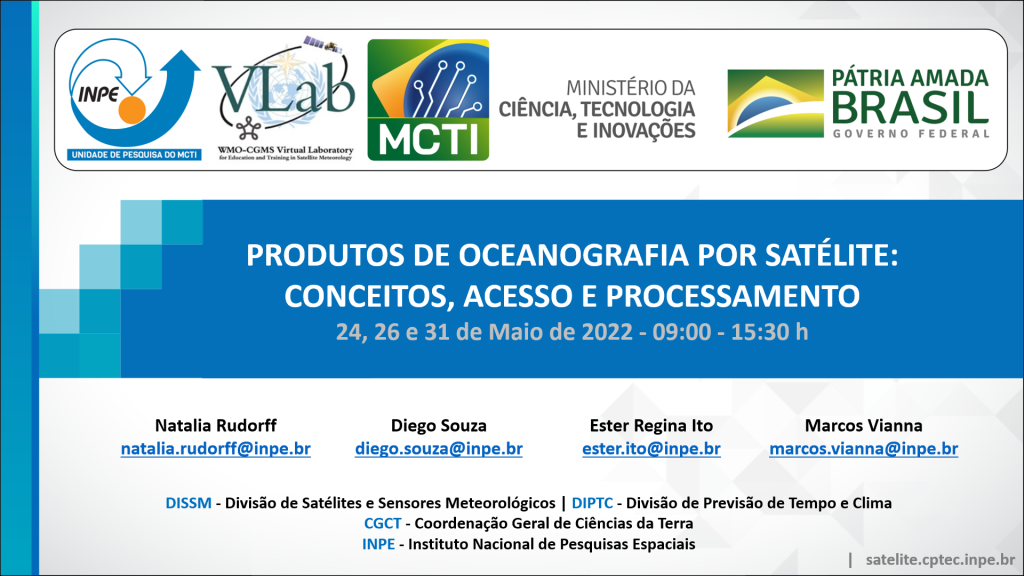

# **Step 1: Checking the Virtual Machine Configuration**

In this step we check the machine configuration and the installed Python version.


In [ ]:
# Verifying the installed O.S.
!cat /etc/issue
!uname -a
print('\n')

# Verifying the available RAM
!grep MemTotal /proc/meminfo
print('\n')

# Verifying the available HD space
!df -h
print('\n')

# Verifying the default Python installation directory
!which python
print('\n')

# Verifying the Python version
!python --version
print('\n')

# **Step 2: Installing the Required Libraries**

Neste passo instalamos as bibliotecas necessárias para a execução dos scripts. Basicamente, as bibliotecas terão a seguinte finalidade:

*   **NetCDF4:** Read satellite data
*   **Cartopy:** Add maps to the plots
*   **Boto3:** Download satellite data from the cloud
*   **GDAL:** Reproject the satellite data 

In [ ]:
# Installing the NetCDF4 library
!pip install netcdf4
print('\n')

# Installing the PyHDF library
!pip install pyhdf
print('\n')

# Installing the Cartopy library
!pip install cartopy
!pip install shapely --no-binary shapely --force
print('\n')

# Installing the Boto3 library
!pip install boto3
print('\n')

# Installing the GDAL library
!apt-add-repository -y ppa:ubuntugis/ubuntugis-unstable
!add-apt-repository -y ppa:ubuntugis/ppa
!apt-get install gdal-bin
!pip install 'gdal==3.0.4'
print('\n')

# **Step 3: Downloading Ancillary Files**

In this step we will download some auxiliary files, necessary for part of the scripts that will be demonstrated in the course:

*   **br_unidades_da_federacao.zip:** Shapefile with Brazilian states
*   **ne_10m_admin_1_states_provinces.zip:** Shapefile with world states and provinces
*   **utilities_ocean.py:** Script to facilitate the download of oceanography files
*   **utilities_goes.py:** Script with some functions for satellite data processing
*   **IR4AVHRR6.cpt:** Color palette for GOES-16 infrared channels
*   **SVGAWVX_TEMP.cpt:** Color palette for GOES-16 water vapor channels
*   **coraltemp_v3.1_20220101.nc:** Global SST file (5 km) sample

In [ ]:
# Downloading the shapefile of the Brazilian states
!wget -c https://geoftp.ibge.gov.br/organizacao_do_territorio/malhas_territoriais/malhas_municipais/municipio_2019/Brasil/BR/br_unidades_da_federacao.zip
print('\n')

# Decompressing the shapefile of the Brazilian states
!unzip -o br_unidades_da_federacao.zip
print('\n')

# Downloading the METAREA V shapefile
!wget -c https://github.com/diegormsouza/Oceanography_Python_May_2022/raw/main/Metareas.zip
print('\n')

# Decompressing the METAREA V shapefile file
!unzip -o Metareas.zip
print('\n')

# Downloading the shapefile of the world states / provinces
!wget -c https://www.naturalearthdata.com/http//www.naturalearthdata.com/download/10m/cultural/ne_10m_admin_1_states_provinces.zip
print('\n')

# Decompressing shapefile file of world states/provinces
!unzip -o ne_10m_admin_1_states_provinces.zip
print('\n')

# Download the script "utilities_ocean.py", to facilitate the download of oceanography files
!wget -c https://raw.githubusercontent.com/diegormsouza/Oceanography_Python_May_2022/main/utilities_ocean.py
print('\n')

# Download the script "utilities_goes.py", from the satellite processing course, with some functions that facilitate the manipulation of satellite data
!wget -c https://raw.githubusercontent.com/diegormsouza/Oceanography_Python_May_2022/main/utilities_goes.py
print('\n')

# Download a sample CPT file (for IR channel enhancement)
!wget -c https://raw.githubusercontent.com/diegormsouza/Oceanography_Python_May_2022/main/IR4AVHRR6.cpt
print('\n')

# Download a sample CPT file (for enhancing WV channels)
!wget -c https://raw.githubusercontent.com/diegormsouza/Oceanography_Python_May_2022/main/SVGAWVX_TEMP.cpt
print('\n')

# Creation of "Samples" and "Output" directories
!mkdir -p Samples
!mkdir -p Output

# Download a SST sample from NOAA's open FTP servers
from ftplib import FTP    # FTP client protocol
import os                 # Operating System Interfaces

# Create the samples directory if it doesn't exist
dir = "Samples"; os.makedirs(dir, exist_ok=True)
# FTP server
ftp = FTP('ftp.star.nesdis.noaa.gov') 
# Log in
ftp.login('', '')
# Directory of interest
path = ('pub/socd/mecb/crw/data/5km/v3.1_op/nc/v1.0/daily/sst/2022/')
ftp.cwd(path)
# File of interest
file_name = 'coraltemp_v3.1_20220101.nc'
# Download the data
ftp.retrbinary("RETR " + file_name, open(dir + '//' + file_name, 'wb').write)
# Finish the connection
ftp.quit()

At this point our libraries are installed and the auxiliary files are downloaded. We are ready to start script development! Let's start with a simple script and gradually increase the complexity with new features.

# **Script 1: Basic Plot**

In this first script we are going to make a basic plot of a global SST data (5 km). Let's see how to use the NetCDF4 library, read the complete data and create a plot with basic settings.

In [ ]:
#---------------------------------------------------------------------------------------------------------------------------
# INPE / CGCT / DISSM - Training: Oceanography Products - Script 1: Basic Plot
# Author: Diego Souza (INPE / CGCT / DISSM)
#---------------------------------------------------------------------------------------------------------------------------
# Required modules
from netCDF4 import Dataset      # Read / Write NetCDF4 files
import matplotlib.pyplot as plt  # Plotting library
#---------------------------------------------------------------------------------------------------------------------------
# Open the file using the NetCDF4 library
file = Dataset("Samples/coraltemp_v3.1_20220101.nc")

# Extract the Sea Surface Temperature
data = file.variables['analysed_sst'][0,:,:]
#---------------------------------------------------------------------------------------------------------------------------
# Choose the plot size (width x height, in inches)
plt.figure(figsize=(10,10))
 
# Plot the image
plt.imshow(data, vmin=-2, vmax=35, origin='lower', cmap='jet')
#--------------------------------------------------------------------------------------------------------------------------- 
# Save the image
plt.savefig('Output/image_01.png')

# Show the image
plt.show()

# **Script 2: Reading Metadata and Adding Legend, Title and Date**

In this script we are going to learn how to read the file's metadata to check its characteristics, we are going to add a legend with the "colorbar" instruction and add a title with the "title" instruction. In the title we will add the date of the file, obtained through the metadata.

In [ ]:
#---------------------------------------------------------------------------------------------------------------------------
# INPE / CGCT / DISSM - Training: Oceanography Products - Script 2: Reading the Metadate, Adding a Legend, Title and Date
# Author: Diego Souza (INPE / CGCT / DISSM)
#---------------------------------------------------------------------------------------------------------------------------
# Required modules
from netCDF4 import Dataset               # Read / Write NetCDF4 files
import matplotlib.pyplot as plt           # Plotting library
from datetime import datetime, timedelta         # Basic date and time types
#---------------------------------------------------------------------------------------------------------------------------
# Open the file using the NetCDF4 library
file = Dataset("Samples/coraltemp_v3.1_20220101.nc")

# Extract the Sea Surface Temperature
data = file.variables['analysed_sst'][0,:,:]
#---------------------------------------------------------------------------------------------------------------------------
# Choose the plot size (width x height, in inches)
plt.figure(figsize=(10,10))
 
# Plot the image
plt.imshow(data, vmin=-2, vmax=35, origin='lower', cmap='jet')

# Add a colorbar
plt.colorbar(label='Sea Surface Temperature (°C)', extend='both', orientation='horizontal', pad=0.05, fraction=0.05)

# Getting the file time and date
add_seconds = int(file.variables['time'][0])
date = datetime(1981,1,1,0) + timedelta(seconds=add_seconds)
date_formatted = date.strftime('%Y-%m-%d')
	
# Add a title
plt.title(f'NOAA Coral Reef Watch Daily 5 km SST - {date_formatted}', fontweight='bold', fontsize=10, loc='left')
plt.title('INPE / CGCT / DISSM', fontsize=10, loc='right')
#--------------------------------------------------------------------------------------------------------------------------- 
# Save the image
plt.savefig('Output/image_02.png')

# Show the image
plt.show()

**Example: Reading available metadata and extracting information**

In [ ]:
# Print the NetCDF variables
print(file.variables.keys())
print('\n')

# Print the content of a variable
print(file.variables['time'])
print('\n')

print("Segundos desde a aquisição: " + str(file.variables['time'][0]) + ' s')
print('\n')

# **Script 3: Adding Maps with Cartopy**

In this example we are going to check how to add maps to our plot with the Cartopy library. Let's also add a background map, reference lines, and latitude and longitude values to the plot.

In [ ]:
#---------------------------------------------------------------------------------------------------------------------------
# INPE / CGCT / DISSM - Training: Oceanography Products - Script 3: Adding Maps with Cartopy
# Author: Diego Souza (INPE / CGCT / DISSM)
#---------------------------------------------------------------------------------------------------------------------------
# Required modules
from netCDF4 import Dataset               # Read / Write NetCDF4 files
import matplotlib.pyplot as plt           # Plotting library
from datetime import datetime, timedelta  # Basic date and time types
import cartopy, cartopy.crs as ccrs       # Plot maps
import cartopy.feature as cfeature        # Common drawing and filtering operations
import numpy as np                        # Import the Numpy package
#---------------------------------------------------------------------------------------------------------------------------
# Open the file using the NetCDF4 library
file = Dataset("Samples/coraltemp_v3.1_20220101.nc")

# Extract the Sea Surface Temperature
data = file.variables['analysed_sst'][0,:,:]

# Reading the lats and lons 
lats = file.variables['lat'][:]
lons = file.variables['lon'][:]
#---------------------------------------------------------------------------------------------------------------------------
# Choose the plot size (width x height, in inches)
plt.figure(figsize=(15,15))

# Use the Cilindrical Equidistant projection in cartopy
ax = plt.axes(projection=ccrs.PlateCarree())

# Define the image extent
img_extent = [lons.min(), lons.max(), lats.min(), lats.max()]

# Add coastlines, borders and gridlines
ax.coastlines(resolution='50m', color='black', linewidth=0.8)
ax.add_feature(cartopy.feature.BORDERS, edgecolor='black', linewidth=0.5)
gl = ax.gridlines(crs=ccrs.PlateCarree(), color='white', alpha=1.0, linestyle='--', linewidth=0.25, xlocs=np.arange(-180, 180, 30), ylocs=np.arange(-90, 90, 10), draw_labels=True)
gl.top_labels = False
gl.right_labels = False

# Add a land mask
ax.add_feature(cfeature.LAND)

# Plot the image
img = ax.imshow(data, vmin=-2, vmax=35, origin='lower', extent=img_extent, cmap='jet')

# Add a colorbar
plt.colorbar(img, label='Sea Surface Temperature (°C)', extend='both', orientation='horizontal', pad=0.05, fraction=0.05)

# Getting the file time and date
add_seconds = int(file.variables['time'][0])
date = datetime(1981,1,1,0) + timedelta(seconds=add_seconds)
date_formatted = date.strftime('%Y-%m-%d')
	
# Add a title
plt.title(f'NOAA Coral Reef Watch Daily 5 km SST - {date_formatted}', fontweight='bold', fontsize=10, loc='left')
plt.title('INPE / CGCT / DISSM', fontsize=10, loc='right')
#---------------------------------------------------------------------------------------------------------------------------
# Save the image
plt.savefig('Output/image_03.png')

# Show the image
plt.show()

# **Script 4: Projections with Cartopy**

One of the features of the Cartopy library is the ability to easily modify the plot projection. Find the list of available projections at the following link: https://scitools.org.uk/cartopy/docs/v0.15/crs/projections.html
Let's see some examples below (Mercator, Robinson and Mollweide projections)

**Script 4.1: Mercator Projection**

In [ ]:
#---------------------------------------------------------------------------------------------------------------------------
# INPE / CGCT / DISSM - Training: Oceanography Products - Script 4.1: Cartopy Projections (Mercator)
# Author: Diego Souza (INPE / CGCT / DISSM)
#---------------------------------------------------------------------------------------------------------------------------
# Required modules
from netCDF4 import Dataset               # Read / Write NetCDF4 files
import matplotlib.pyplot as plt           # Plotting library
from datetime import datetime, timedelta  # Basic date and time types
import cartopy, cartopy.crs as ccrs       # Plot maps
import cartopy.feature as cfeature        # Common drawing and filtering operations
import numpy as np                        # Import the Numpy package
#---------------------------------------------------------------------------------------------------------------------------
# Open the file using the NetCDF4 library
file = Dataset("Samples/coraltemp_v3.1_20220101.nc")

# Extract the Sea Surface Temperature
data = file.variables['analysed_sst'][0,:,:]
#---------------------------------------------------------------------------------------------------------------------------
# Choose the plot size (width x height, in inches)
plt.figure(figsize=(15,15))

# Use the Mercator projection in cartopy
ax = plt.axes(projection=ccrs.Mercator(central_longitude=0.0))

# Method used for "global" plots
ax.set_global()

# Add a background map
ax.stock_img()

# Add coastlines, borders and gridlines
ax.coastlines(resolution='50m', color='black', linewidth=0.8)
ax.add_feature(cartopy.feature.BORDERS, edgecolor='black', linewidth=0.5)
gl = ax.gridlines(crs=ccrs.PlateCarree(), color='white', alpha=1.0, linestyle='--', linewidth=0.25, xlocs=np.arange(-180, 180, 30), ylocs=np.arange(-90, 90, 10), draw_labels=True)
gl.top_labels = False
gl.right_labels = False

# Plot the image
plt.imshow(data, vmin=-2, vmax=35, origin='lower', cmap='jet', transform=ccrs.PlateCarree())

# Add a colorbar
plt.colorbar(label='Sea Surface Temperature (°C)', extend='both', orientation='horizontal', pad=0.05, fraction=0.05)

# Getting the file time and date
add_seconds = int(file.variables['time'][0])
date = datetime(1981,1,1,0) + timedelta(seconds=add_seconds)
date_formatted = date.strftime('%Y-%m-%d')
	
# Add a title
plt.title(f'NOAA Coral Reef Watch Daily 5 km SST - {date_formatted}', fontweight='bold', fontsize=10, loc='left')
plt.title('Mercator Projection', fontsize=10, loc='right')
#--------------------------------------------------------------------------------------------------------------------------- 
# Save the image
plt.savefig('Output/image_04_1.png')

# Show the image
plt.show()

**Script 4.2: Robinson Projection**

In [ ]:
#---------------------------------------------------------------------------------------------------------------------------
# INPE / CGCT / DISSM - Training: Oceanography Products - Script 4.2: Cartopy Projections (Robinson)
# Author: Diego Souza (INPE / CGCT / DISSM)
#---------------------------------------------------------------------------------------------------------------------------
# Required modules
from netCDF4 import Dataset               # Read / Write NetCDF4 files
import matplotlib.pyplot as plt           # Plotting library
from datetime import datetime, timedelta  # Basic date and time types
import cartopy, cartopy.crs as ccrs       # Plot maps
import cartopy.feature as cfeature        # Common drawing and filtering operations
import numpy as np                        # Import the Numpy package
#---------------------------------------------------------------------------------------------------------------------------
# Open the file using the NetCDF4 library
file = Dataset("Samples/coraltemp_v3.1_20220101.nc")

# Extract the Sea Surface Temperature
data = file.variables['analysed_sst'][0,:,:]
#---------------------------------------------------------------------------------------------------------------------------
# Choose the plot size (width x height, in inches)
plt.figure(figsize=(15,15))

# Use the Robinson projection in cartopy
ax = plt.axes(projection=ccrs.Robinson(central_longitude=0.0))

# Method used for "global" plots
ax.set_global()

# Add a background map
ax.stock_img()

# Add coastlines, borders and gridlines
ax.coastlines(resolution='50m', color='black', linewidth=0.8)
ax.add_feature(cartopy.feature.BORDERS, edgecolor='black', linewidth=0.5)
gl = ax.gridlines(crs=ccrs.PlateCarree(), color='white', alpha=1.0, linestyle='--', linewidth=0.25, xlocs=np.arange(-180, 180, 30), ylocs=np.arange(-90, 90, 10), draw_labels=False)

# Plot the image
plt.imshow(data, vmin=-2, vmax=35, origin='lower', cmap='jet', transform=ccrs.PlateCarree())

# Add a colorbar
plt.colorbar(label='Sea Surface Temperature (°C)', extend='both', orientation='horizontal', pad=0.05, fraction=0.05)

# Getting the file time and date
add_seconds = int(file.variables['time'][0])
date = datetime(1981,1,1,0) + timedelta(seconds=add_seconds)
date_formatted = date.strftime('%Y-%m-%d')
	
# Add a title
plt.title(f'NOAA Coral Reef Watch Daily 5 km SST - {date_formatted}', fontweight='bold', fontsize=10, loc='left')
plt.title('Robinson Projection', fontsize=10, loc='right')
#--------------------------------------------------------------------------------------------------------------------------- 
# Save the image
plt.savefig('Output/image_04_2.png')

# Show the image
plt.show()

**Script 4.3: Mollweide Projection**

In [ ]:
#---------------------------------------------------------------------------------------------------------------------------
# INPE / CGCT / DISSM - Training: Oceanography Products - Script 4.3: Cartopy Projections (Mollweide)
# Author: Diego Souza (INPE / CGCT / DISSM)
#---------------------------------------------------------------------------------------------------------------------------
# Required modules
from netCDF4 import Dataset               # Read / Write NetCDF4 files
import matplotlib.pyplot as plt           # Plotting library
from datetime import datetime, timedelta  # Basic date and time types
import cartopy, cartopy.crs as ccrs       # Plot maps
import cartopy.feature as cfeature        # Common drawing and filtering operations
import numpy as np                        # Import the Numpy package
#---------------------------------------------------------------------------------------------------------------------------
# Open the file using the NetCDF4 library
file = Dataset("Samples/coraltemp_v3.1_20220101.nc")

# Extract the Sea Surface Temperature
data = file.variables['analysed_sst'][0,:,:]
#---------------------------------------------------------------------------------------------------------------------------
# Choose the plot size (width x height, in inches)
plt.figure(figsize=(15,15))

# Use the Mollweide projection in cartopy
ax = plt.axes(projection=ccrs.Mollweide(central_longitude=0.0))

# Method used for "global" plots
ax.set_global()

# Add a background map
ax.stock_img()

# Add coastlines, borders and gridlines
ax.coastlines(resolution='50m', color='black', linewidth=0.8)
ax.add_feature(cartopy.feature.BORDERS, edgecolor='black', linewidth=0.5)
gl = ax.gridlines(crs=ccrs.PlateCarree(), color='white', alpha=1.0, linestyle='--', linewidth=0.25, xlocs=np.arange(-180, 180, 30), ylocs=np.arange(-90, 90, 10), draw_labels=False)

# Plot the image
plt.imshow(data, vmin=-2, vmax=35, origin='lower', cmap='jet', transform=ccrs.PlateCarree())

# Add a colorbar
plt.colorbar(label='Sea Surface Temperature (°C)', extend='both', orientation='horizontal', pad=0.05, fraction=0.05)

# Getting the file time and date
add_seconds = int(file.variables['time'][0])
date = datetime(1981,1,1,0) + timedelta(seconds=add_seconds)
date_formatted = date.strftime('%Y-%m-%d')
	
# Add a title
plt.title(f'NOAA Coral Reef Watch Daily 5 km SST - {date_formatted}', fontweight='bold', fontsize=10, loc='left')
plt.title('Mollweide Projection', fontsize=10, loc='right')
#--------------------------------------------------------------------------------------------------------------------------- 
# Save the image
plt.savefig('Output/image_04_3.png')

# Show the image
plt.show()

# **Script 5: Custom Color Palettes (Continuous and Discrete)**

Although matplotlib's default color palettes are quite varied, sometimes it may be necessary to create custom palettes. In these two examples, we'll check out how to create continuous and discrete palettes.

**Script 5.1: Continuous Color Palette**

This first example was based on the NASA Worldview color palette. Color values in hexadecimal can be obtained from: https://imagecolorpicker.com/

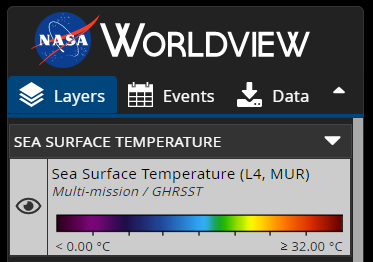

In [ ]:
#---------------------------------------------------------------------------------------------------------------------------
# INPE / CGCT / DISSM - Training: Oceanography Products - Script 5.1: Custom Color Palettes (Continuous)
# Author: Diego Souza (INPE / CGCT / DISSM)
#---------------------------------------------------------------------------------------------------------------------------
# Required modules
from netCDF4 import Dataset               # Read / Write NetCDF4 files
import matplotlib.pyplot as plt           # Plotting library
from datetime import datetime, timedelta  # Basic date and time types
import cartopy, cartopy.crs as ccrs       # Plot maps
import cartopy.feature as cfeature        # Common drawing and filtering operations
import numpy as np                        # Import the Numpy package
import matplotlib.colors                  # Matplotlib colors  
#---------------------------------------------------------------------------------------------------------------------------
# Open the file using the NetCDF4 library
file = Dataset("Samples/coraltemp_v3.1_20220101.nc")

# Extract the Sea Surface Temperature
data = file.variables['analysed_sst'][0,:,:]

# Reading the lats and lons 
lats = file.variables['lat'][:]
lons = file.variables['lon'][:]
#---------------------------------------------------------------------------------------------------------------------------
# Choose the plot size (width x height, in inches)
plt.figure(figsize=(15,15))

# Use the Cilindrical Equidistant projection in cartopy
ax = plt.axes(projection=ccrs.PlateCarree())

# Define the image extent
img_extent = [lons.min(), lons.max(), lats.min(), lats.max()]

# Add coastlines, borders and gridlines
ax.coastlines(resolution='50m', color='black', linewidth=0.8)
ax.add_feature(cartopy.feature.BORDERS, edgecolor='black', linewidth=0.5)
gl = ax.gridlines(crs=ccrs.PlateCarree(), color='white', alpha=1.0, linestyle='--', linewidth=0.25, xlocs=np.arange(-180, 180, 30), ylocs=np.arange(-90, 90, 10), draw_labels=True)
gl.top_labels = False
gl.right_labels = False

# Create a custom color scale:
# Reference color scale from NASA Wordview: https://worldview.earthdata.nasa.gov/
# HEX values got from: https://imagecolorpicker.com/:
colors = ["#2d001c", "#5b0351", "#780777", "#480a5e", "#1e1552", 
          "#1f337d", "#214c9f", "#2776c6", "#2fa5f1", "#1bad1d", 
          "#8ad900", "#ffec00", "#ffab00", "#f46300", "#de3b00", 
          "#ab1900", "#6b0200", '#3c0000']
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", colors)
cmap.set_over('#3c0000')
cmap.set_under('#28000a')
vmin = -2.0
vmax = 35.0

# Add a land mask
ax.add_feature(cfeature.LAND)

# Plot the image
img = ax.imshow(data, vmin=vmin, vmax=vmax, origin='lower', extent=img_extent, cmap=cmap)

# Add a colorbar
plt.colorbar(img, label='Sea Surface Temperature (°C)', extend='both', orientation='horizontal', pad=0.05, fraction=0.05)

# Getting the file time and date
add_seconds = int(file.variables['time'][0])
date = datetime(1981,1,1,0) + timedelta(seconds=add_seconds)
date_formatted = date.strftime('%Y-%m-%d')
	
# Add a title
plt.title(f'NOAA Coral Reef Watch Daily 5 km SST - {date_formatted}', fontweight='bold', fontsize=10, loc='left')
plt.title('INPE / CGCT / DISSM', fontsize=10, loc='right')
#--------------------------------------------------------------------------------------------------------------------------- 
# Save the image
plt.savefig('Output/image_05.png')

# Show the image
plt.show()

**Script 5.2: Discrete Color Palette**

The second example was based on the NOAA color palette. Color values in hexadecimal can be obtained from: https://imagecolorpicker.com/

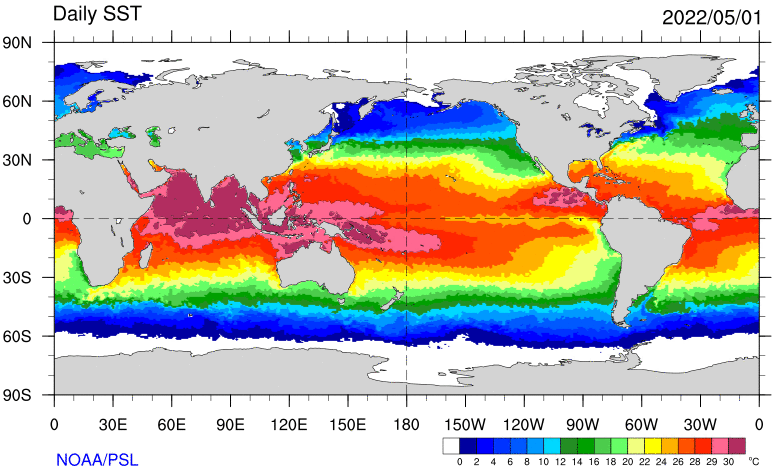

In [ ]:
#---------------------------------------------------------------------------------------------------------------------------
# INPE / CGCT / DISSM - Training: Oceanography Products - Script 5.2: Custom Color Palettes (Discrete)
# Author: Diego Souza (INPE / CGCT / DISSM)
#---------------------------------------------------------------------------------------------------------------------------
# Required modules
from netCDF4 import Dataset               # Read / Write NetCDF4 files
import matplotlib.pyplot as plt           # Plotting library
from datetime import datetime, timedelta  # Basic date and time types
import cartopy, cartopy.crs as ccrs       # Plot maps
import cartopy.feature as cfeature        # Common drawing and filtering operations
import numpy as np                        # Import the Numpy package
import matplotlib.colors                  # Matplotlib colors  
#---------------------------------------------------------------------------------------------------------------------------
# Open the file using the NetCDF4 library
file = Dataset("Samples/coraltemp_v3.1_20220101.nc")

# Extract the Sea Surface Temperature
data = file.variables['analysed_sst'][0,:,:]

# Reading the lats and lons 
lats = file.variables['lat'][:]
lons = file.variables['lon'][:]
#---------------------------------------------------------------------------------------------------------------------------
# Choose the plot size (width x height, in inches)
plt.figure(figsize=(15,15))

# Use the Cilindrical Equidistant projection in cartopy
ax = plt.axes(projection=ccrs.PlateCarree())

# Define the image extent
img_extent = [lons.min(), lons.max(), lats.min(), lats.max()]

# Add coastlines, borders and gridlines
ax.coastlines(resolution='50m', color='black', linewidth=0.8)
ax.add_feature(cartopy.feature.BORDERS, edgecolor='black', linewidth=0.5)
gl = ax.gridlines(crs=ccrs.PlateCarree(), color='white', alpha=1.0, linestyle='--', linewidth=0.25, xlocs=np.arange(-180, 180, 30), ylocs=np.arange(-90, 90, 10), draw_labels=True)
gl.top_labels = False
gl.right_labels = False

# Create a custom color scale:
# Reference color scale from NOAA: https://psl.noaa.gov/map/clim/sst.shtml
# HEX values got from: https://imagecolorpicker.com/:
colors = ["#0000a1", "#0000fe", "#0034ff", "#0356fc", "#0199fc", 
          "#01daff", "#238e25", "#00a001", "#4bcc4e", "#62fe64", 
          "#f5fe81", "#ffff02", "#ffb200", "#fd5106", "#ff2600", 
          "#fb6a94", "#b52c64"]
cmap = matplotlib.colors.ListedColormap(colors)
cmap.set_over('#b52c64')
cmap.set_under('#0000a1')
vmin = 0.0
vmax = 34.0

# Add a land mask
ax.add_feature(cfeature.LAND)

# Plot the image
img = ax.imshow(data, vmin=vmin, vmax=vmax, origin='lower', extent=img_extent, cmap=cmap)

# Define the ticks to be shown
ticks = [-2, 0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30, 32, 34]

# Add a colorbar
plt.colorbar(img, label='Sea Surface Temperature (°C)', extend='both', orientation='horizontal', pad=0.05, fraction=0.05, ticks=ticks)

# Getting the file time and date
add_seconds = int(file.variables['time'][0])
date = datetime(1981,1,1,0) + timedelta(seconds=add_seconds)
date_formatted = date.strftime('%Y-%m-%d')
	
# Add a title
plt.title(f'NOAA Coral Reef Watch Daily 5 km SST - {date_formatted}', fontweight='bold', fontsize=10, loc='left')
plt.title('INPE / CGCT / DISSM', fontsize=10, loc='right')
#--------------------------------------------------------------------------------------------------------------------------- 
# Save the image
plt.savefig('Output/image_05.png')

# Show the image
plt.show()

# **Script 6: Plotting a Specific Region**

We don't always want to plot the global data. In this example we will check how to plot a specific region of the data, finding the indices of our coordinates in the latitudes and longitudes matrices.

In [ ]:
#---------------------------------------------------------------------------------------------------------------------------
# INPE / CGCT / DISSM - Training: Oceanography Products - Script 6: Plotting a Specific Region
# Author:zx
from netCDF4 import Dataset               # Read / Write NetCDF4 files
import matplotlib.pyplot as plt           # Plotting library
from datetime import datetime, timedelta  # Basic date and time types
import cartopy, cartopy.crs as ccrs       # Plot maps
import cartopy.feature as cfeature        # Common drawing and filtering operations
import numpy as np                        # Import the Numpy package
import matplotlib.colors                  # Matplotlib colors  
#---------------------------------------------------------------------------------------------------------------------------
# Open the file using the NetCDF4 library
file = Dataset("Samples/coraltemp_v3.1_20220101.nc")
#---------------------------------------------------------------------------------------------------------------------------
# Select the extent [min. lon, min. lat, max. lon, max. lat]
extent = [-93.0, -60.00, -25.00, 18.00] # South America
       
# Reading lats and lons 
lats = file.variables['lat'][:]
lons = file.variables['lon'][:]

# Latitude lower and upper index
latli = np.argmin( np.abs( lats - extent[1] ) )
latui = np.argmin( np.abs( lats - extent[3] ) )
 
# Longitude lower and upper index
lonli = np.argmin( np.abs( lons - extent[0] ) )
lonui = np.argmin( np.abs( lons - extent[2] ) )
 
# Extract the Sea Surface Temperature
data = file.variables['analysed_sst'][ 0 , latli:latui , lonli:lonui ]
#---------------------------------------------------------------------------------------------------------------------------
# Choose the plot size (width x height, in inches)
plt.figure(figsize=(15,15))

# Use the Cilindrical Equidistant projection in cartopy
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([extent[0], extent[2], extent[1], extent[3]], ccrs.PlateCarree())

# Define the image extent
img_extent = [extent[0], extent[2], extent[1], extent[3]]

# Add coastlines, borders and gridlines
ax.coastlines(resolution='50m', color='black', linewidth=0.8)
ax.add_feature(cartopy.feature.BORDERS, edgecolor='black', linewidth=0.5)
gl = ax.gridlines(crs=ccrs.PlateCarree(), color='white', alpha=1.0, linestyle='--', linewidth=0.25, xlocs=np.arange(-180, 180, 10), ylocs=np.arange(-90, 90, 10), draw_labels=True)
gl.top_labels = False
gl.right_labels = False

# Create a custom color scale:
colors = ["#2d001c", "#5b0351", "#780777", "#480a5e", "#1e1552", 
          "#1f337d", "#214c9f", "#2776c6", "#2fa5f1", "#1bad1d", 
          "#8ad900", "#ffec00", "#ffab00", "#f46300", "#de3b00", 
          "#ab1900", "#6b0200", '#3c0000']
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", colors)
cmap.set_over('#3c0000')
cmap.set_under('#28000a')
vmin = -2.0
vmax = 35.0

# Add a land mask
ax.add_feature(cfeature.LAND)

# Plot the image
img = ax.imshow(data, vmin=vmin, vmax=vmax, origin='lower', extent=img_extent, cmap=cmap)

# Add a colorbar
plt.colorbar(img, label='Sea Surface Temperature (°C)', extend='both', orientation='vertical', pad=0.02, fraction=0.05)

# Getting the file time and date
add_seconds = int(file.variables['time'][0])
date = datetime(1981,1,1,0) + timedelta(seconds=add_seconds)
date_formatted = date.strftime('%Y-%m-%d')
	
# Add a title
plt.title(f'NOAA Coral Reef Watch Daily 5 km SST - {date_formatted}', fontweight='bold', fontsize=13, loc='left')
plt.title('Region: ' + str(extent), fontsize=13, loc='right')
#--------------------------------------------------------------------------------------------------------------------------- 
# Save the image
plt.savefig('Output/image_06.png')

# Show the image
plt.show()

# **Script 7: Adding Shapefiles and Texts**

Now that we know how to plot a specific region, let's add some decorations to our plots. In this example, we are going to add two shapefiles, one for states and provinces worldwide, and another for **METAREA V** (Brazil's area of responsibility before the WMO, for which the Marine Meteorological Service issues weather warnings and meteorological forecasts to sailors and the entire maritime community). In addition, we will add some text indicating the subregions of METAREA V and additional text, inside a box, in the lower right corner.

In [ ]:
#---------------------------------------------------------------------------------------------------------------------------
# INPE / CGCT / DISSM - Training: Oceanography Products - Script 7: Adding Shapefiles and Texts
# Author: Diego Souza (INPE / CGCT / DISSM)
#---------------------------------------------------------------------------------------------------------------------------
# Required modules
from netCDF4 import Dataset                # Read / Write NetCDF4 files
import matplotlib.pyplot as plt            # Plotting library
from datetime import datetime, timedelta   # Basic date and time types
import cartopy, cartopy.crs as ccrs        # Plot maps
import cartopy.feature as cfeature         # Common drawing and filtering operations
import cartopy.io.shapereader as shpreader # Import shapefiles
import numpy as np                         # Import the Numpy package
import matplotlib.colors                   # Matplotlib colors  
#---------------------------------------------------------------------------------------------------------------------------
# Open the file using the NetCDF4 library
file = Dataset("Samples/coraltemp_v3.1_20220101.nc")
#---------------------------------------------------------------------------------------------------------------------------
# Select the extent [min. lon, min. lat, max. lon, max. lat]
extent = [-93.0, -60.00, -10.00, 18.00] # South America
       
# Reading lats and lons 
lats = file.variables['lat'][:]
lons = file.variables['lon'][:]

# Latitude lower and upper index
latli = np.argmin( np.abs( lats - extent[1] ) )
latui = np.argmin( np.abs( lats - extent[3] ) )
 
# Longitude lower and upper index
lonli = np.argmin( np.abs( lons - extent[0] ) )
lonui = np.argmin( np.abs( lons - extent[2] ) )
 
# Extract the Sea Surface Temperature
data = file.variables['analysed_sst'][ 0 , latli:latui , lonli:lonui ]
#---------------------------------------------------------------------------------------------------------------------------
# Choose the plot size (width x height, in inches)
plt.figure(figsize=(15,15))

# Use the Cilindrical Equidistant projection in cartopy
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([extent[0], extent[2], extent[1], extent[3]], ccrs.PlateCarree())

# Define the image extent
img_extent = [extent[0], extent[2], extent[1], extent[3]]

# Add coastlines, borders and gridlines
ax.coastlines(resolution='50m', color='black', linewidth=0.8)
ax.add_feature(cartopy.feature.BORDERS, edgecolor='black', linewidth=0.5)
gl = ax.gridlines(crs=ccrs.PlateCarree(), color='white', alpha=1.0, linestyle='--', linewidth=0.25, xlocs=np.arange(-180, 180, 10), ylocs=np.arange(-90, 90, 10), draw_labels=True)
gl.top_labels = False
gl.right_labels = False

# Create a custom color scale:
colors = ["#2d001c", "#5b0351", "#780777", "#480a5e", "#1e1552", 
          "#1f337d", "#214c9f", "#2776c6", "#2fa5f1", "#1bad1d", 
          "#8ad900", "#ffec00", "#ffab00", "#f46300", "#de3b00", 
          "#ab1900", "#6b0200", '#3c0000']
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", colors)
cmap.set_over('#3c0000')
cmap.set_under('#28000a')
vmin = -2.0
vmax = 35.0

# Add a background map
ax.stock_img()

# Plot the image
img = ax.imshow(data, vmin=vmin, vmax=vmax, origin='lower', extent=img_extent, cmap=cmap)

# Add a shapefile
shapefile = list(shpreader.Reader('ne_10m_admin_1_states_provinces.shp').geometries())
ax.add_geometries(shapefile, ccrs.PlateCarree(), edgecolor='gray',facecolor='none', linewidth=0.3)

# Add a shapefile
shapefile = list(shpreader.Reader('Metareas.shp').geometries())
ax.add_geometries(shapefile, ccrs.PlateCarree(), edgecolor='black',facecolor='none', linewidth=1.0)

# Add a colorbar
plt.colorbar(img, label='Sea Surface Temperature (°C)', extend='both', orientation='vertical', pad=0.02, fraction=0.05)

# Getting the file time and date
add_seconds = int(file.variables['time'][0])
date = datetime(1981,1,1,0) + timedelta(seconds=add_seconds)
date_formatted = date.strftime('%Y-%m-%d')
	
# Add a title
plt.title(f'NOAA Coral Reef Watch Daily 5 km SST - {date_formatted}', fontweight='bold', fontsize=13, loc='left')
plt.title('Region: ' + str(extent), fontsize=13, loc='right')

# Add a text inside the plot
from matplotlib.offsetbox import AnchoredText
text = AnchoredText("INPE / CGCT / DISSM", loc=4, prop={'size': 12}, frameon=True)
ax.add_artist(text)

# Add texts
txt1 = ax.annotate("METAREA V", xy=(-28, 9), xycoords=ccrs.PlateCarree()._as_mpl_transform(ax), color='black', size=20, clip_on=True, annotation_clip=True, horizontalalignment='center', verticalalignment='center', transform=ccrs.PlateCarree())
txt2 = ax.annotate("A", xy=(-48, -32), xycoords=ccrs.PlateCarree()._as_mpl_transform(ax), color='black', size=20, clip_on=True, annotation_clip=True, horizontalalignment='center', verticalalignment='center', transform=ccrs.PlateCarree())
txt3 = ax.annotate("B", xy=(-43, -27), xycoords=ccrs.PlateCarree()._as_mpl_transform(ax), color='black', size=20, clip_on=True, annotation_clip=True, horizontalalignment='center', verticalalignment='center', transform=ccrs.PlateCarree())
txt4 = ax.annotate("C", xy=(-46, -25), xycoords=ccrs.PlateCarree()._as_mpl_transform(ax), color='black', size=20, clip_on=True, annotation_clip=True, horizontalalignment='center', verticalalignment='center', transform=ccrs.PlateCarree())
txt5 = ax.annotate("D", xy=(-38, -22), xycoords=ccrs.PlateCarree()._as_mpl_transform(ax), color='black', size=20, clip_on=True, annotation_clip=True, horizontalalignment='center', verticalalignment='center', transform=ccrs.PlateCarree())
txt6 = ax.annotate("E", xy=(-36, -17), xycoords=ccrs.PlateCarree()._as_mpl_transform(ax), color='black', size=20, clip_on=True, annotation_clip=True, horizontalalignment='center', verticalalignment='center', transform=ccrs.PlateCarree())
txt7 = ax.annotate("F", xy=(-33, -10), xycoords=ccrs.PlateCarree()._as_mpl_transform(ax), color='black', size=20, clip_on=True, annotation_clip=True, horizontalalignment='center', verticalalignment='center', transform=ccrs.PlateCarree())
txt8 = ax.annotate("G", xy=(-36, -2), xycoords=ccrs.PlateCarree()._as_mpl_transform(ax), color='black', size=20, clip_on=True, annotation_clip=True, horizontalalignment='center', verticalalignment='center', transform=ccrs.PlateCarree())
txt9 = ax.annotate("H", xy=(-46, 2), xycoords=ccrs.PlateCarree()._as_mpl_transform(ax), color='black', size=20, clip_on=True, annotation_clip=True, horizontalalignment='center', verticalalignment='center', transform=ccrs.PlateCarree())
txt10 = ax.annotate("N", xy=(-22, -13), xycoords=ccrs.PlateCarree()._as_mpl_transform(ax), color='black', size=20, clip_on=True, annotation_clip=True, horizontalalignment='center', verticalalignment='center', transform=ccrs.PlateCarree())
txt11 = ax.annotate("S", xy=(-22, -17), xycoords=ccrs.PlateCarree()._as_mpl_transform(ax), color='black', size=20, clip_on=True, annotation_clip=True, horizontalalignment='center', verticalalignment='center', transform=ccrs.PlateCarree())


#--------------------------------------------------------------------------------------------------------------------------- 
# Save the image
plt.savefig('Output/image_07.png')

# Show the image
plt.show()

# **Script 8: Reading Data from a Coordinate and Adding to the Plot**

Let's add to our plot the value of our variable at a given coordinate. For this, similar to the methodology used to plot a certain region, we will find the correct indices in our latitude and longitude matrices to extract the correct point from the data matrix. After this extraction, let's add the information in a stylized frame.

In [ ]:
#---------------------------------------------------------------------------------------------------------------------------
# INPE / CGCT / DISSM - Training: Oceanography Products - Script 8: Reading Data from a Coordinate and Adding it to the Plot
# Author: Diego Souza (INPE / CGCT / DISSM)
#---------------------------------------------------------------------------------------------------------------------------
# Required modules
from netCDF4 import Dataset                # Read / Write NetCDF4 files
import matplotlib.pyplot as plt            # Plotting library
from datetime import datetime, timedelta   # Basic date and time types
import cartopy, cartopy.crs as ccrs        # Plot maps
import cartopy.feature as cfeature         # Common drawing and filtering operations
import cartopy.io.shapereader as shpreader # Import shapefiles
import numpy as np                         # Import the Numpy package
import matplotlib.colors                   # Matplotlib colors  
#---------------------------------------------------------------------------------------------------------------------------
# Open the file using the NetCDF4 library
file = Dataset("Samples/coraltemp_v3.1_20220101.nc")
#---------------------------------------------------------------------------------------------------------------------------
# Select the extent [min. lon, min. lat, max. lon, max. lat]
extent = [-93.0, -60.00, -10.00, 18.00] # South America
       
# Reading lats and lons 
lats = file.variables['lat'][:]
lons = file.variables['lon'][:]

# Latitude lower and upper index
latli = np.argmin( np.abs( lats - extent[1] ) )
latui = np.argmin( np.abs( lats - extent[3] ) )
 
# Longitude lower and upper index
lonli = np.argmin( np.abs( lons - extent[0] ) )
lonui = np.argmin( np.abs( lons - extent[2] ) )
 
# Extract the Sea Surface Temperature
data = file.variables['analysed_sst'][ 0 , latli:latui , lonli:lonui ]
#---------------------------------------------------------------------------------------------------------------------------
# Choose the plot size (width x height, in inches)
plt.figure(figsize=(15,15))

# Use the Cilindrical Equidistant projection in cartopy
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([extent[0], extent[2], extent[1], extent[3]], ccrs.PlateCarree())

# Define the image extent
img_extent = [extent[0], extent[2], extent[1], extent[3]]

# Add coastlines, borders and gridlines
ax.coastlines(resolution='50m', color='black', linewidth=0.8)
ax.add_feature(cartopy.feature.BORDERS, edgecolor='black', linewidth=0.5)
gl = ax.gridlines(crs=ccrs.PlateCarree(), color='white', alpha=1.0, linestyle='--', linewidth=0.25, xlocs=np.arange(-180, 180, 10), ylocs=np.arange(-90, 90, 10), draw_labels=True)
gl.top_labels = False
gl.right_labels = False

# Create a custom color scale:
colors = ["#2d001c", "#5b0351", "#780777", "#480a5e", "#1e1552", 
          "#1f337d", "#214c9f", "#2776c6", "#2fa5f1", "#1bad1d", 
          "#8ad900", "#ffec00", "#ffab00", "#f46300", "#de3b00", 
          "#ab1900", "#6b0200", '#3c0000']
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", colors)
cmap.set_over('#3c0000')
cmap.set_under('#28000a')
vmin = -2.0
vmax = 35.0

# Add a background map
ax.stock_img()

# Plot the image
img = ax.imshow(data, vmin=vmin, vmax=vmax, origin='lower', extent=img_extent, cmap=cmap)

# Add a shapefile
shapefile = list(shpreader.Reader('ne_10m_admin_1_states_provinces.shp').geometries())
ax.add_geometries(shapefile, ccrs.PlateCarree(), edgecolor='gray',facecolor='none', linewidth=0.3)

# Add a shapefile
shapefile = list(shpreader.Reader('Metareas.shp').geometries())
ax.add_geometries(shapefile, ccrs.PlateCarree(), edgecolor='black',facecolor='none', linewidth=1.0)

# Add a colorbar
plt.colorbar(img, label='Sea Surface Temperature (°C)', extend='both', orientation='vertical', pad=0.02, fraction=0.05)

# Getting the file time and date
add_seconds = int(file.variables['time'][0])
date = datetime(1981,1,1,0) + timedelta(seconds=add_seconds)
date_formatted = date.strftime('%Y-%m-%d')
	
# Add a title
plt.title(f'NOAA Coral Reef Watch Daily 5 km SST - {date_formatted}', fontweight='bold', fontsize=13, loc='left')
plt.title('Region: ' + str(extent), fontsize=13, loc='right')

# Add a text inside the plot
from matplotlib.offsetbox import AnchoredText
text = AnchoredText("INPE / CGCT / DISSM", loc=4, prop={'size': 12}, frameon=True)
ax.add_artist(text)

# Add texts
txt1 = ax.annotate("METAREA V", xy=(-28, 9), xycoords=ccrs.PlateCarree()._as_mpl_transform(ax), color='black', size=20, clip_on=True, annotation_clip=True, horizontalalignment='center', verticalalignment='center', transform=ccrs.PlateCarree())
txt2 = ax.annotate("A", xy=(-48, -32), xycoords=ccrs.PlateCarree()._as_mpl_transform(ax), color='black', size=20, clip_on=True, annotation_clip=True, horizontalalignment='center', verticalalignment='center', transform=ccrs.PlateCarree())
txt3 = ax.annotate("B", xy=(-43, -27), xycoords=ccrs.PlateCarree()._as_mpl_transform(ax), color='black', size=20, clip_on=True, annotation_clip=True, horizontalalignment='center', verticalalignment='center', transform=ccrs.PlateCarree())
txt4 = ax.annotate("C", xy=(-46, -25), xycoords=ccrs.PlateCarree()._as_mpl_transform(ax), color='black', size=20, clip_on=True, annotation_clip=True, horizontalalignment='center', verticalalignment='center', transform=ccrs.PlateCarree())
txt5 = ax.annotate("D", xy=(-38, -22), xycoords=ccrs.PlateCarree()._as_mpl_transform(ax), color='black', size=20, clip_on=True, annotation_clip=True, horizontalalignment='center', verticalalignment='center', transform=ccrs.PlateCarree())
txt6 = ax.annotate("E", xy=(-36, -17), xycoords=ccrs.PlateCarree()._as_mpl_transform(ax), color='black', size=20, clip_on=True, annotation_clip=True, horizontalalignment='center', verticalalignment='center', transform=ccrs.PlateCarree())
txt7 = ax.annotate("F", xy=(-33, -10), xycoords=ccrs.PlateCarree()._as_mpl_transform(ax), color='black', size=20, clip_on=True, annotation_clip=True, horizontalalignment='center', verticalalignment='center', transform=ccrs.PlateCarree())
txt8 = ax.annotate("G", xy=(-36, -2), xycoords=ccrs.PlateCarree()._as_mpl_transform(ax), color='black', size=20, clip_on=True, annotation_clip=True, horizontalalignment='center', verticalalignment='center', transform=ccrs.PlateCarree())
txt9 = ax.annotate("H", xy=(-46, 2), xycoords=ccrs.PlateCarree()._as_mpl_transform(ax), color='black', size=20, clip_on=True, annotation_clip=True, horizontalalignment='center', verticalalignment='center', transform=ccrs.PlateCarree())
txt10 = ax.annotate("N", xy=(-22, -13), xycoords=ccrs.PlateCarree()._as_mpl_transform(ax), color='black', size=20, clip_on=True, annotation_clip=True, horizontalalignment='center', verticalalignment='center', transform=ccrs.PlateCarree())
txt11 = ax.annotate("S", xy=(-22, -17), xycoords=ccrs.PlateCarree()._as_mpl_transform(ax), color='black', size=20, clip_on=True, annotation_clip=True, horizontalalignment='center', verticalalignment='center', transform=ccrs.PlateCarree())

# Reading the data from a coordinate
lat_point = -30
lon_point = -40
lat_idx = np.argmin(np.abs(lats - lat_point))
lon_idx = np.argmin(np.abs(lons - lon_point))
data_point = file.variables['analysed_sst'][ 0 , lat_idx , lon_idx ].round(2)

# Adding the data as an annotation
# Add a circle
ax.plot(lon_point, lat_point, 'o', color='red', markersize=8, transform=ccrs.Geodetic(), markeredgewidth=1.0, markeredgecolor=(0, 0, 0, 1))
# Add a text
txt_offset_x = 0.8
txt_offset_y = 0.8
plt.annotate("Lat: " + str(lat_point) + "\n" + "Lon: " + str(lon_point) + "\n" + "SST: \n" + str(data_point) + ' °C', xy=(lon_point + txt_offset_x, lat_point + txt_offset_y), xycoords=ccrs.PlateCarree()._as_mpl_transform(ax), fontsize=12, fontweight='bold', color='gold', bbox=dict(boxstyle="round",fc=(0.0, 0.0, 0.0, 0.5), ec=(1., 1., 1.)), alpha = 1.0)

#--------------------------------------------------------------------------------------------------------------------------- 
# Save the image
plt.savefig('Output/image_08.png')

# Show the image
plt.show()

# **Script 9: Downloading Data Using Functions**

In this training we are using data from NOAA open FTP links. We can download these files manually (using software like Filezilla) and we can also download them using scripts. Python's **ftplib** library facilitates this operation. Let's check in this script how to use it.

The download options implemented in this script are:

*   **'SST':** Sea Surface Temperature (daily)
*   **'SST-Monthly-Min':** Sea Surface Temperature (monthly minimum)
*   **'SST-Monthly-Mean':** Sea Surface Temperature (monthly average)
*   **'SST-Monthly-Max':** Sea Surface Temperature (monthly maximum)
*   **'SST-Annual-Min':** Sea Surface Temperature (annual minimum)
*   **'SST-Annual-Mean':** Sea Surface Temperature (annual average)
*   **'SST-Annual-Max':** Sea Surface Temperature (annual maximum)
*   **'SST-A':** Sea Surface Temperature Anomaly (daily)
*   **'SST-A-Monthly-Min':** Sea Surface Temperature Anomaly (monthly minimum)
*   **'SST-A-Monthly-Mean':** Sea Surface Temperature Anomaly (monthly average)
*   **'SST-A-Monthly-Max':** Sea Surface Temperature Anomaly (monthly maximum)
*   **'SST-A-Annual-Min':** Sea Surface Temperature Anomaly (annual minimum)
*   **'SST-A-Annual-Mean':** Sea Surface Temperature Anomaly (annual average)
*   **'SST-A-Annual-Max':** Sea Surface Temperature Anomaly (annual maximum)
*   **'SST-LEO':** Sea Surface Temperature (NOAA-20 and S-NPP - Daily)
*   **'SST-T':** Sea Surface Temperature - 7-day Trend 
*   **'BAA':** Bleaching Alert Area (Daily)
*   **'BAA-Monthly-Max':** Bleaching Alert Area (monthly maximum)
*   **'BAA-Annual-Max':** Bleaching Alert Area (annual maximum)
*   **'BHS':** Bleaching Alert Area - Hotspot (daily)
*   **'BHS-Monthly-Max':** Bleaching Alert Area (monthly maximum)
*   **'BHS-Annual-Max':** Bleaching Alert Area - Hotspot (annual maximum)
*   **'DWH':** Coral Bleaching Heat Stress Degree Heating Week (daily)
*   **'DWH-Monthly-Max':** Coral Bleaching Heat Stress Degree Heating Week (monthly maximum)
*   **'DWH-Annual-Max':** Coral Bleaching Heat Stress Degree Heating Week (annual maximum)
*   **'CLO':** Chlorophyll-a - Ocean Color (daily)
*   **'SLA':** Sea Level Anomaly (daily)
*   **'ASC-A-a-hdf':** ASCAT Winds (METOP-B - ascending orbit) - HDF
*   **'ASC-A-d-hdf':** ASCAT Winds (METOP-B - descending orbit) - HDF
*   **'ASC-B-a-hdf':** ASCAT Winds (METOP-B - ascending orbit) - HDF
*   **'ASC-B-d-hdf':** ASCAT Winds (METOP-B - descending orbit) - HDF
*   **'ASC-C-a-hdf':** ASCAT Winds (METOP-C - ascending orbit) - HDF
*   **'ASC-C-d-hdf':** ASCAT Winds (METOP-C - descending orbit) - HDF

In [ ]:
#---------------------------------------------------------------------------------------------------------------------------
# INPE / CGCT / DISSM - Training: Oceanography Products - Script 9: Downloading Data Using Funtions 
# Author: Diego Souza (INPE / CGCT / DISSM)
#---------------------------------------------------------------------------------------------------------------------------
# Required modules
from netCDF4 import Dataset                # Read / Write NetCDF4 files
import matplotlib.pyplot as plt            # Plotting library
from datetime import datetime, timedelta   # Basic date and time types
import cartopy, cartopy.crs as ccrs        # Plot maps
import cartopy.feature as cfeature         # Common drawing and filtering operations
import cartopy.io.shapereader as shpreader # Import shapefiles
import numpy as np                         # Import the Numpy package
import matplotlib.colors                   # Matplotlib colors  
from datetime import datetime, timedelta   # Basic Dates and time types
import os                                  # Miscellaneous operating system interfaces
import time as t                           # Time access and conversion                                          
from ftplib import FTP                     # FTP protocol client
#---------------------------------------------------------------------------------------------------------------------------

def download_OCEAN(product, date, path_dest):

  #-----------------------------------------------------------------------------------------------------------
  
  # FTP data description:

  # SEA SURFACE TEMPERATURE:
  # SST         (Global - 5 km): ftp.star.nesdis.noaa.gov/pub/socd/mecb/crw/data/5km/v3.1_op/nc/v1.0/daily/sst
  # SST Monthly - min / mean / max (Global - 5 km)          : ftp.star.nesdis.noaa.gov/pub/socd/mecb/crw/data/5km/v3.1_op/nc/v1.0/monthly
  # SST Annual - min / mean / max (Global - 5 km)          : ftp.star.nesdis.noaa.gov/pub/socd/mecb/crw/data/5km/v3.1_op/nc/v1.0/annual

  # SEA SURFACE TEMPERATURE ANOMALY:
  # SST-Anomaly (Global - 5 km): ftp.star.nesdis.noaa.gov/pub/socd/mecb/crw/data/5km/v3.1_op/nc/v1.0/daily/ssta
  # SST-Anomaly Monthly - - min / mean / max (Global - 5 km): ftp.star.nesdis.noaa.gov/pub/socd/mecb/crw/data/5km/v3.1_op/nc/v1.0/monthly
  # SST-Anomaly Annual - - min / mean / max (Global - 5 km): ftp.star.nesdis.noaa.gov/pub/socd/mecb/crw/data/5km/v3.1_op/nc/v1.0/annual

  # SEA SURFACE TEMPERATURE - 7 DAY TREND:
  # SST-Trend   (Global - 5 km): ftp.star.nesdis.noaa.gov/pub/socd/mecb/crw/data/5km/v3.1_op/nc/v1.0/daily/sst-trend-7d

  # BLEACHING ALERT AREA:
  # BAA (Global - 5 km)              : ftp.star.nesdis.noaa.gov/pub/socd/mecb/crw/data/5km/v3.1_op/nc/v1.0/daily/baa
  # BAA Monthly - max (Global - 5 km): ftp.star.nesdis.noaa.gov/pub/socd/mecb/crw/data/5km/v3.1_op/nc/v1.0/monthly
  # BAA Annual - max (Global - 5 km) : ftp.star.nesdis.noaa.gov/pub/socd/mecb/crw/data/5km/v3.1_op/nc/v1.0/annual

  # CORAL BLEACHING HOTSPOT:
  # BHS (Global - 5 km)              : ftp.star.nesdis.noaa.gov/pub/socd/mecb/crw/data/5km/v3.1_op/nc/v1.0/daily/hs
  # BHS Monthly - max (Global - 5 km): ftp.star.nesdis.noaa.gov/pub/socd/mecb/crw/data/5km/v3.1_op/nc/v1.0/monthly
  # BHS Annual - max (Global - 5 km) : ftp.star.nesdis.noaa.gov/pub/socd/mecb/crw/data/5km/v3.1_op/nc/v1.0/annual

  # CORAL BLEACHING HEAT STRESS DEGREE HEATING WEEK:
  # DHW (Global - 5 km)              : ftp.star.nesdis.noaa.gov/pub/socd/mecb/crw/data/5km/v3.1_op/nc/v1.0/daily/dhw
  # DHW Monthly - max (Global - 5 km): ftp.star.nesdis.noaa.gov/pub/socd/mecb/crw/data/5km/v3.1_op/nc/v1.0/monthly
  # DHW Annual - max (Global - 5 km) : ftp.star.nesdis.noaa.gov/pub/socd/mecb/crw/data/5km/v3.1_op/nc/v1.0/annual

  # OCEAN COLOR:
  # OC [filled] (Global - 9 km): ftp.star.nesdis.noaa.gov/pub/socd1/mecb/coastwatch/viirs/nrt/L3/global/chlora/dineof
  # OC Granules (S-NPP)        : ftpcoastwatch.noaa.gov/pub/socd1/mecb/coastwatch/viirs/nrt/L2/
  # OC Granules (NOAA-20)      : ftpcoastwatch.noaa.gov/pub/socd2/mecb/coastwatch/viirs/n20/nrt/L2/

  # ALTIMETRY
  # Sea Level Anomaly          : ftpcoastwatch.noaa.gov/pub/socd/lsa/rads/sla/daily/nrt
  # Granules (JASON 2)         : ftp-oceans.ncei.noaa.gov/pub/data.nodc/jason2
  # Granules (JASON 3)         : ftp-oceans.ncei.noaa.gov/pub/data.nodc/jason2
  # JASON 3                    : ftpcoastwatch.noaa.gov/pub/socd/lsa/johnk/coastwatch/j3 

  # ASCAT WINDS:
  # (NetCDF) Daily             : ftpcoastwatch.noaa.gov/pub/socd7/coastwatch/metop/ascat/netcdf/day
  # (NetCDF) 4hr               : ftpcoastwatch.noaa.gov/pub/socd7/coastwatch/metop/ascat/netcdf/4hr
  # (HDF) Daily and 4hr        : ftpcoastwatch.noaa.gov/pub/socd1/coastwatch/products/ascat/4hr/hdf

  # SST LEO Global (0.02°)     : ftpcoastwatch.noaa.gov/pub/socd2/coastwatch/sst/nrt/l3s/leo/pm/
  #-----------------------------------------------------------------------------------------------------------

  print('-----------------------------------')
  print('NOAA FTP Download - Script started.')
  print('-----------------------------------')

  # Start the time counter
  start_time = t.time()  

  #-----------------------------------------------------------------------------------------------------------

  # Download directory
  #dir = "Samples"; os.makedirs(dir, exist_ok=True)
  # Download directory
  dir = path_dest; os.makedirs(dir, exist_ok=True)

  # Product selection
  product = product 
  # Options: 
  # 'SST', 'SST-A' (Anomaly), 'SST-T' (Trend), 'BAA' (Bleaching Alert), 'BHS' (Bleaching Hotspot), 'DHW' (Degree Heating Week), 'CLO' (Ocean Color), 'SLA' (Sea Level Anomaly), 'JAS' (JASON-3), 
  # 'SST-Monthly-Min', 'SST-Monthly-Mean', 'SST-Monthly-Max', 
  # 'SST-Annual-Min', 'SST-Annual-Mean', 'SST-Annual-Max'
  # 'SST-A-Monthly-Min', 'SST-A-Monthly-Mean', 'SST-A-Monthly-Max'
  # 'SST-A-Annual-Min', 'SST-A-Annual-Mean', 'SST-A-Annual-Max'
  # 'BAA-Monthly-Max', 'BAA-Annual-Max'
  # 'BHS-Monthly-Max', 'BHS-Annual-Max'
  # 'DHW-Monthly-Max', 'DHW-Annual-Max'
  # 'SST-LEO'
  # 'ASC-A-a-hdf', 'ASC-A-d-hdf', 'ASC-B-a-hdf, 'ASC-B-d-hdf', 'ASC-C-a-hdf, 'ASC-C-d-hdf' (ASCAT Winds)

  # Desired year (four digit)
  year = date[0:4]
  #year = '2021'

  # Desired month (two digit)
  month = date[4:6]
  #month = '06'

  # Desired day (two digit)
  day = date[6:8] 
  #day = '28' 

  #-----------------------------------------------------------------------------------------------------------

  # FTP Address
  if (product == 'SST' or product == 'SST-A' or product == 'SST-T' or product == 'BAA' or 
      product == 'BHS' or product == 'DHW' or product == 'CLO' or product == 'SST-Monthly-Min' or product == 'SST-Monthly-Mean' or 
      product == 'SST-Monthly-Max' or product == 'SST-Annual-Min' or product == 'SST-Annual-Mean' or 
      product == 'SST-Annual-Max' or product == 'SST-A-Monthly-Min' or product == 'SST-A-Monthly-Mean' or 
      product == 'SST-A-Monthly-Max' or product == 'SST-A-Annual-Min' or product == 'SST-A-Annual-Mean' or 
      product == 'SST-A-Annual-Max' or product == 'BAA-Monthly-Max' or product == 'BHA-Annual-Max' or
      product == 'BHS-Monthly-Max' or product == 'BHS-Annual-Max' or 
      product == 'DHW-Monthly-Max' or product == 'DHW-Annual-Max'):
    ftp = FTP('ftp.star.nesdis.noaa.gov') 
  elif (product == 'ASC-A-a-hdf' or 'ASC-A-a-hdf' or 'ASC-B-a-hdf' or 'ASC-B-d-hdf' or 'ASC-C-a-hdf' or 'ASC-C-d-hdf' or product == 'SLA' or product == 'JAS' or product == 'SST-LEO'):
    ftp = FTP('ftpcoastwatch.noaa.gov') 

  # FTP Credentials 
  ftp.login('', '') 

  #-----------------------------------------------------------------------------------------------------------

  # Access the FTP folder, based on the desired product
  if (product == 'SST'):
      # FTP Path
      path = ('pub/socd/mecb/crw/data/5km/v3.1_op/nc/v1.0/daily/sst/' + year + '/')
      naming_convention = 'coraltemp_v3.1'
      extension = '.nc'
      file_name = naming_convention + '_' + year + month + day + extension

  elif (product == 'SST-Monthly-Max'):
      # FTP Path
      path = ('pub/socd/mecb/crw/data/5km/v3.1_op/nc/v1.0/monthly/' + year + '/')
      naming_convention = 'ct5km_sst-max_v3.1'
      extension = '.nc'
      file_name = naming_convention + '_' + year + month + extension

  elif (product == 'SST-Monthly-Mean'):
      # FTP Path
      path = ('pub/socd/mecb/crw/data/5km/v3.1_op/nc/v1.0/monthly/' + year + '/')
      naming_convention = 'ct5km_sst-mean_v3.1'
      extension = '.nc'
      file_name = naming_convention + '_' + year + month + extension

  elif (product == 'SST-Monthly-Min'):
      # FTP Path
      path = ('pub/socd/mecb/crw/data/5km/v3.1_op/nc/v1.0/monthly/' + year + '/')
      naming_convention = 'ct5km_sst-min_v3.1'
      extension = '.nc'
      file_name = naming_convention + '_' + year + month + extension

  elif (product == 'SST-Annual-Max'):
      # FTP Path
      path = ('pub/socd/mecb/crw/data/5km/v3.1_op/nc/v1.0/annual/')
      naming_convention = 'ct5km_sst-max_v3.1'
      extension = '.nc'
      file_name = naming_convention + '_' + year + extension

  elif (product == 'SST-Annual-Mean'):
      # FTP Path
      path = ('pub/socd/mecb/crw/data/5km/v3.1_op/nc/v1.0/annual/')
      naming_convention = 'ct5km_sst-mean_v3.1'
      extension = '.nc'
      file_name = naming_convention + '_' + year + extension

  elif (product == 'SST-Annual-Min'):
      # FTP Path
      path = ('pub/socd/mecb/crw/data/5km/v3.1_op/nc/v1.0/annual/')
      naming_convention = 'ct5km_sst-min_v3.1'
      extension = '.nc'
      file_name = naming_convention + '_' + year + extension

  elif (product == 'SST-A'):
      # FTP Path
      path = ('pub/socd/mecb/crw/data/5km/v3.1_op/nc/v1.0/daily/ssta/' + year + '/')
      naming_convention = 'ct5km_ssta_v3.1'
      extension = '.nc'
      file_name = naming_convention + '_' + year + month + day + extension

  elif (product == 'SST-A-Monthly-Max'):
      # FTP Path
      path = ('pub/socd/mecb/crw/data/5km/v3.1_op/nc/v1.0/monthly/' + year + '/')
      naming_convention = 'ct5km_ssta-max_v3.1'
      extension = '.nc'
      file_name = naming_convention + '_' + year + month + extension

  elif (product == 'SST-A-Monthly-Mean'):
      # FTP Path
      path = ('pub/socd/mecb/crw/data/5km/v3.1_op/nc/v1.0/monthly/' + year + '/')
      naming_convention = 'ct5km_ssta-mean_v3.1'
      extension = '.nc'
      file_name = naming_convention + '_' + year + month + extension

  elif (product == 'SST-A-Monthly-Min'):
      # FTP Path
      path = ('pub/socd/mecb/crw/data/5km/v3.1_op/nc/v1.0/monthly/' + year + '/')
      naming_convention = 'ct5km_ssta-min_v3.1'
      extension = '.nc'
      file_name = naming_convention + '_' + year + month + extension

  elif (product == 'SST-A-Annual-Max'):
      # FTP Path
      path = ('pub/socd/mecb/crw/data/5km/v3.1_op/nc/v1.0/annual/')
      naming_convention = 'ct5km_ssta-max_v3.1'
      extension = '.nc'
      file_name = naming_convention + '_' + year + extension

  elif (product == 'SST-A-Annual-Mean'):
      # FTP Path
      path = ('pub/socd/mecb/crw/data/5km/v3.1_op/nc/v1.0/annual/')
      naming_convention = 'ct5km_ssta-mean_v3.1'
      extension = '.nc'
      file_name = naming_convention + '_' + year + extension

  elif (product == 'SST-A-Annual-Min'):
      # FTP Path
      path = ('pub/socd/mecb/crw/data/5km/v3.1_op/nc/v1.0/annual/')
      naming_convention = 'ct5km_ssta-min_v3.1'
      extension = '.nc'
      file_name = naming_convention + '_' + year + extension

  elif (product == 'SST-T'):
      # FTP Path
      path = ('pub/socd/mecb/crw/data/5km/v3.1_op/nc/v1.0/daily/sst-trend-7d/' + year + '/')
      naming_convention = 'ct5km_sst-trend-7d_v3.1'
      extension = '.nc'
      file_name = naming_convention + '_' + year + month + day + extension

  elif (product == 'BAA'):
      # FTP Path
      path = ('pub/socd/mecb/crw/data/5km/v3.1_op/nc/v1.0/daily/baa/' + year + '/')
      naming_convention = 'ct5km_baa_v3.1'
      extension = '.nc'
      file_name = naming_convention + '_' + year + month + day + extension

  elif (product == 'BAA-Monthly-Max'):
      # FTP Path
      path = ('pub/socd/mecb/crw/data/5km/v3.1_op/nc/v1.0/monthly/' + year + '/')
      naming_convention = 'ct5km_baa-max_v3.1'
      extension = '.nc'
      file_name = naming_convention + '_' + year + month + extension

  elif (product == 'BAA-Annual-Max'):
      # FTP Path
      path = ('pub/socd/mecb/crw/data/5km/v3.1_op/nc/v1.0/annual/')
      naming_convention = 'ct5km_baa-max_v3.1'
      extension = '.nc'
      file_name = naming_convention + '_' + year + extension

  elif (product == 'BHS'):
      # FTP Path
      path = ('pub/socd/mecb/crw/data/5km/v3.1_op/nc/v1.0/daily/hs/' + year + '/')
      naming_convention = 'ct5km_hs_v3.1'
      extension = '.nc'
      file_name = naming_convention + '_' + year + month + day + extension

  elif (product == 'BHS-Monthly-Max'):
      # FTP Path
      path = ('pub/socd/mecb/crw/data/5km/v3.1_op/nc/v1.0/monthly/' + year + '/')
      naming_convention = 'ct5km_hs-max_v3.1'
      extension = '.nc'
      file_name = naming_convention + '_' + year + month + extension

  elif (product == 'BHS-Annual-Max'):
      # FTP Path
      path = ('pub/socd/mecb/crw/data/5km/v3.1_op/nc/v1.0/annual/')
      naming_convention = 'ct5km_hs-max_v3.1'
      extension = '.nc'
      file_name = naming_convention + '_' + year + extension

  elif (product == 'DHW'):
      # FTP Path
      path = ('pub/socd/mecb/crw/data/5km/v3.1_op/nc/v1.0/daily/dhw/' + year + '/')
      naming_convention = 'ct5km_dhw_v3.1'
      extension = '.nc'
      file_name = naming_convention + '_' + year + month + day + extension

  elif (product == 'DHW-Monthly-Max'):
      # FTP Path
      path = ('pub/socd/mecb/crw/data/5km/v3.1_op/nc/v1.0/monthly/' + year + '/')
      naming_convention = 'ct5km_dhw-max_v3.1'
      extension = '.nc'
      file_name = naming_convention + '_' + year + month + extension

  elif (product == 'DHW-Annual-Max'):
      # FTP Path
      path = ('pub/socd/mecb/crw/data/5km/v3.1_op/nc/v1.0/annual/')
      naming_convention = 'ct5km_dhw-max_v3.1'
      extension = '.nc'
      file_name = naming_convention + '_' + year + extension

  elif (product == 'CLO'):
      # Converting date to julian day
      import datetime
      fmt = '%Y%m%d'
      s = year + month + day
      dt = datetime.datetime.strptime(s, fmt)
      tt = dt.timetuple()
      jday = str(tt.tm_yday).zfill(3)
      # FTP Path
      path = ('pub/socd1/mecb/coastwatch/viirs/nrt/L3/global/chlora/dineof/' + year + '/')
      naming_convention = '_a1_WW00_chlora'
      extension = '.nc'
      file_name = 'V' + year + jday + naming_convention + extension

  elif (product == 'SLA'):
      # FTP Path
      path = ('pub/socd/lsa/rads/sla/daily/nrt/' + year + '/')
      naming_convention = 'rads_global_nrt_sla'
      extension = '.nc'
      date_1 = year + month + day
      date_2 = str(datetime(int(year), int(month), int(day)) + timedelta(days=1))
      date_2 = datetime.strptime(date_2, '%Y-%m-%d %H:%M:%S').strftime('%Y%m%d')   
      file_name = naming_convention + '_' + date_1 + '_' + date_2 + '_' + '001' + extension

  elif (product == 'ASC-A-a-hdf'):
      # Converting date to julian day
      import datetime
      fmt = '%Y%m%d'
      s = year + month + day
      dt = datetime.datetime.strptime(s, fmt)
      tt = dt.timetuple()
      jday = str(tt.tm_yday).zfill(3)
      # FTP Path
      path = ('pub/socd1/coastwatch/products/ascat/4hr/hdf/')
      naming_convention = 'AS'
      extension = '.hdf'
      file_name = naming_convention + year + jday + 'Aas_WW' + extension

  elif (product == 'ASC-A-d-hdf'):
      # Converting date to julian day
      import datetime
      fmt = '%Y%m%d'
      s = year + month + day
      dt = datetime.datetime.strptime(s, fmt)
      tt = dt.timetuple()
      jday = str(tt.tm_yday).zfill(3)
      # FTP Path
      path = ('pub/socd1/coastwatch/products/ascat/4hr/hdf/')
      naming_convention = 'AS'
      extension = '.hdf'
      file_name = naming_convention + year + jday + 'Ads_WW' + extension

  elif (product == 'ASC-B-a-hdf'):
      # Converting date to julian day
      import datetime
      fmt = '%Y%m%d'
      s = year + month + day
      dt = datetime.datetime.strptime(s, fmt)
      tt = dt.timetuple()
      jday = str(tt.tm_yday).zfill(3)
      # FTP Path
      path = ('pub/socd1/coastwatch/products/ascat/4hr/hdf/')
      naming_convention = 'AS'
      extension = '.hdf'
      file_name = naming_convention + year + jday + 'Bas_WW' + extension

  elif (product == 'ASC-B-d-hdf'):
      # Converting date to julian day
      import datetime
      fmt = '%Y%m%d'
      s = year + month + day
      dt = datetime.datetime.strptime(s, fmt)
      tt = dt.timetuple()
      jday = str(tt.tm_yday).zfill(3)
      # FTP Path
      path = ('pub/socd1/coastwatch/products/ascat/4hr/hdf/')
      naming_convention = 'AS'
      extension = '.hdf'
      file_name = naming_convention + year + jday + 'Bds_WW' + extension

  elif (product == 'ASC-C-a-hdf'):
      # Converting date to julian day
      import datetime
      fmt = '%Y%m%d'
      s = year + month + day
      dt = datetime.datetime.strptime(s, fmt)
      tt = dt.timetuple()
      jday = str(tt.tm_yday).zfill(3)
      # FTP Path
      path = ('pub/socd1/coastwatch/products/ascat/4hr/hdf/')
      naming_convention = 'AS'
      extension = '.hdf'
      file_name = naming_convention + year + jday + 'Cas_WW' + extension

  elif (product == 'ASC-C-d-hdf'):
      # Converting date to julian day
      import datetime
      fmt = '%Y%m%d'
      s = year + month + day
      dt = datetime.datetime.strptime(s, fmt)
      tt = dt.timetuple()
      jday = str(tt.tm_yday).zfill(3)
      # FTP Path
      path = ('pub/socd1/coastwatch/products/ascat/4hr/hdf/')
      naming_convention = 'AS'
      extension = '.hdf'
      file_name = naming_convention + year + jday + 'Cds_WW' + extension

  elif (product == 'JAS'):
      # FTP Path
      path = ('pub/socd/lsa/johnk/coastwatch/j3/')
      naming_convention = 'j3'
      extension = '.nc'
      file_name = naming_convention + '_' + year + month + day + extension

  elif (product == 'SST-LEO'):
    # Converting date to julian day
    import datetime
    fmt = '%Y%m%d'
    s = year + month + day
    dt = datetime.datetime.strptime(s, fmt)
    tt = dt.timetuple()
    jday = str(tt.tm_yday).zfill(3)
    # FTP Path
    path = ('pub/socd2/coastwatch/sst/nrt/l3s/leo/pm/' + year + '/' + jday)
    naming_convention = '120000-STAR-L3S_GHRSST-SSTsubskin-LEO_PM_D-ACSPO_V2.80-v02.0-fv01.0'
    extension = '.nc'
    file_name = year + month + day + naming_convention + extension

#-----------------------------------------------------------------------------------------------------------

  # Download the file
  print('\n---------------------')
  print('Checking the FTP File:') 
  print('---------------------')
  print('Product: ' + product)
  print('Date: ' + year + month + day)
  print('File Name: ' + file_name)

  try:
    # Enter the FTP Path
    ftp.cwd(path)
    # Check if the file exists
    if os.path.exists(dir + '//' + file_name):
      print("")
      print('The file ' + dir + '/' + file_name + ' already exists.')
      print("")
    else:
      # If not, download the file
      print("Downloading the file...")
      ftp.retrbinary("RETR " + file_name, open(dir + '//' + file_name, 'wb').write)  
      print("")
      print('\n---------------------')
      print('Download Finished.') 
      print('---------------------')
      print("")
      # End the time counter
      print('\nTotal Download Time:', round((t.time() - start_time),2), 'seconds.') 
      print("")
  except:
    print("\nFile not available!")
    print("")

  # Quit the FPT connection
  ftp.quit()

  #-----------------------------------------------------------------------------------------------------------
  # Return the file name
  return f'{file_name}'
  #-----------------------------------------------------------------------------------------------------------

# Input and output directories
input = "/content/Samples"; os.makedirs(input, exist_ok=True)
output = "/content/Output"; os.makedirs(output, exist_ok=True)

# Time / Date for download
date = '20220101' # YYYYMMDD

# Download the file (product, date, directory)
file = download_OCEAN('SST', date, input)

**Plotting the Downloaded Data**

In [ ]:
#---------------------------------------------------------------------------------------------------------------------------
# Open the file using the NetCDF4 library
file = Dataset(f'{input}/{file}')
#---------------------------------------------------------------------------------------------------------------------------
# Select the extent [min. lon, min. lat, max. lon, max. lat]
extent = [-93.0, -60.00, -10.00, 18.00] # South America
       
# Reading lats and lons 
lats = file.variables['lat'][:]
lons = file.variables['lon'][:]

# Latitude lower and upper index
latli = np.argmin( np.abs( lats - extent[1] ) )
latui = np.argmin( np.abs( lats - extent[3] ) )
 
# Longitude lower and upper index
lonli = np.argmin( np.abs( lons - extent[0] ) )
lonui = np.argmin( np.abs( lons - extent[2] ) )
 
# Extract the Sea Surface Temperature
data = file.variables['analysed_sst'][ 0 , latli:latui , lonli:lonui ]
#---------------------------------------------------------------------------------------------------------------------------
# Choose the plot size (width x height, in inches)
plt.figure(figsize=(15,15))

# Use the Cilindrical Equidistant projection in cartopy
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([extent[0], extent[2], extent[1], extent[3]], ccrs.PlateCarree())

# Define the image extent
img_extent = [extent[0], extent[2], extent[1], extent[3]]

# Add coastlines, borders and gridlines
ax.coastlines(resolution='50m', color='black', linewidth=0.8)
ax.add_feature(cartopy.feature.BORDERS, edgecolor='black', linewidth=0.5)
gl = ax.gridlines(crs=ccrs.PlateCarree(), color='white', alpha=1.0, linestyle='--', linewidth=0.25, xlocs=np.arange(-180, 180, 10), ylocs=np.arange(-90, 90, 10), draw_labels=True)
gl.top_labels = False
gl.right_labels = False

# Create a custom color scale:
colors = ["#2d001c", "#5b0351", "#780777", "#480a5e", "#1e1552", 
          "#1f337d", "#214c9f", "#2776c6", "#2fa5f1", "#1bad1d", 
          "#8ad900", "#ffec00", "#ffab00", "#f46300", "#de3b00", 
          "#ab1900", "#6b0200", '#3c0000']
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", colors)
cmap.set_over('#3c0000')
cmap.set_under('#28000a')
vmin = -2.0
vmax = 35.0

# Add a background image
ax.stock_img()

# Plot the image
img = ax.imshow(data, vmin=vmin, vmax=vmax, origin='lower', extent=img_extent, cmap=cmap)

# Add a shapefile
shapefile = list(shpreader.Reader('ne_10m_admin_1_states_provinces.shp').geometries())
ax.add_geometries(shapefile, ccrs.PlateCarree(), edgecolor='gray',facecolor='none', linewidth=0.3)

# Add a shapefile
shapefile = list(shpreader.Reader('Metareas.shp').geometries())
ax.add_geometries(shapefile, ccrs.PlateCarree(), edgecolor='black',facecolor='none', linewidth=1.0)

# Add a colorbar
plt.colorbar(img, label='Sea Surface Temperature (°C)', extend='both', orientation='vertical', pad=0.02, fraction=0.05)

# Getting the file time and date
add_seconds = int(file.variables['time'][0])
date = datetime(1981,1,1,0) + timedelta(seconds=add_seconds)
date_formatted = date.strftime('%Y-%m-%d')
	
# Add a title
plt.title(f'NOAA Coral Reef Watch Daily 5 km SST - {date_formatted}', fontweight='bold', fontsize=13, loc='left')
plt.title('Region: ' + str(extent), fontsize=13, loc='right')

# Add a text inside the plot
from matplotlib.offsetbox import AnchoredText
text = AnchoredText("INPE / CGCT / DISSM", loc=4, prop={'size': 12}, frameon=True)
ax.add_artist(text)

# Add texts
txt1 = ax.annotate("METAREA V", xy=(-28, 9), xycoords=ccrs.PlateCarree()._as_mpl_transform(ax), color='black', size=20, clip_on=True, annotation_clip=True, horizontalalignment='center', verticalalignment='center', transform=ccrs.PlateCarree())
txt2 = ax.annotate("A", xy=(-48, -32), xycoords=ccrs.PlateCarree()._as_mpl_transform(ax), color='black', size=20, clip_on=True, annotation_clip=True, horizontalalignment='center', verticalalignment='center', transform=ccrs.PlateCarree())
txt3 = ax.annotate("B", xy=(-43, -27), xycoords=ccrs.PlateCarree()._as_mpl_transform(ax), color='black', size=20, clip_on=True, annotation_clip=True, horizontalalignment='center', verticalalignment='center', transform=ccrs.PlateCarree())
txt4 = ax.annotate("C", xy=(-46, -25), xycoords=ccrs.PlateCarree()._as_mpl_transform(ax), color='black', size=20, clip_on=True, annotation_clip=True, horizontalalignment='center', verticalalignment='center', transform=ccrs.PlateCarree())
txt5 = ax.annotate("D", xy=(-38, -22), xycoords=ccrs.PlateCarree()._as_mpl_transform(ax), color='black', size=20, clip_on=True, annotation_clip=True, horizontalalignment='center', verticalalignment='center', transform=ccrs.PlateCarree())
txt6 = ax.annotate("E", xy=(-36, -17), xycoords=ccrs.PlateCarree()._as_mpl_transform(ax), color='black', size=20, clip_on=True, annotation_clip=True, horizontalalignment='center', verticalalignment='center', transform=ccrs.PlateCarree())
txt7 = ax.annotate("F", xy=(-33, -10), xycoords=ccrs.PlateCarree()._as_mpl_transform(ax), color='black', size=20, clip_on=True, annotation_clip=True, horizontalalignment='center', verticalalignment='center', transform=ccrs.PlateCarree())
txt8 = ax.annotate("G", xy=(-36, -2), xycoords=ccrs.PlateCarree()._as_mpl_transform(ax), color='black', size=20, clip_on=True, annotation_clip=True, horizontalalignment='center', verticalalignment='center', transform=ccrs.PlateCarree())
txt9 = ax.annotate("H", xy=(-46, 2), xycoords=ccrs.PlateCarree()._as_mpl_transform(ax), color='black', size=20, clip_on=True, annotation_clip=True, horizontalalignment='center', verticalalignment='center', transform=ccrs.PlateCarree())
txt10 = ax.annotate("N", xy=(-22, -13), xycoords=ccrs.PlateCarree()._as_mpl_transform(ax), color='black', size=20, clip_on=True, annotation_clip=True, horizontalalignment='center', verticalalignment='center', transform=ccrs.PlateCarree())
txt11 = ax.annotate("S", xy=(-22, -17), xycoords=ccrs.PlateCarree()._as_mpl_transform(ax), color='black', size=20, clip_on=True, annotation_clip=True, horizontalalignment='center', verticalalignment='center', transform=ccrs.PlateCarree())

# Reading the data from a coordinate
lat_point = -30
lon_point = -30
lat_idx = (np.abs(lats - lat_point)).argmin()
lon_idx = (np.abs(lons - lon_point)).argmin()
data_point = file.variables['analysed_sst'][ : , lat_idx , lon_idx ][0].round(2)

# Adding the data as an annotation
# Add a circle
ax.plot(lon_point, lat_point, 'o', color='red', markersize=8, transform=ccrs.Geodetic(), markeredgewidth=1.0, markeredgecolor=(0, 0, 0, 1))
# Add a text
txt_offset_x = 0.8
txt_offset_y = 0.8
plt.annotate("Lat: " + str(lat_point) + "\n" + "Lon: " + str(lon_point) + "\n" + "SST: \n" + str(data_point) + ' °C', xy=(lon_point + txt_offset_x, lat_point + txt_offset_y), xycoords=ccrs.PlateCarree()._as_mpl_transform(ax), fontsize=12, fontweight='bold', color='gold', bbox=dict(boxstyle="round",fc=(0.0, 0.0, 0.0, 0.5), ec=(1., 1., 1.)), alpha = 1.0)

#--------------------------------------------------------------------------------------------------------------------------- 
# Save the image
plt.savefig('Output/image_09.png')

# Show the image
plt.show()

# **Script 10: Downloading Data Using Functions - External File**

Scripts get a bit long when using the download function within the script itself. In the example below we are calling the function **"download_OCEAN"** from an external file **"utilities_ocean.py"**, downloaded automatically at the beginning of this procedure. So our scripts are more compact.

In [ ]:
#---------------------------------------------------------------------------------------------------------------------------
# INPE / CGCT / DISSM - Training: Oceanography Products - Script 10: Downloading Data Using Funtions - External File
# Author: Diego Souza (INPE / CGCT / DISSM)
#---------------------------------------------------------------------------------------------------------------------------
# Required modules
from netCDF4 import Dataset                # Read / Write NetCDF4 files
import matplotlib.pyplot as plt            # Plotting library
from datetime import datetime, timedelta   # Basic date and time types
import cartopy, cartopy.crs as ccrs        # Plot maps
import cartopy.feature as cfeature         # Common drawing and filtering operations
import cartopy.io.shapereader as shpreader # Import shapefiles
import numpy as np                         # Import the Numpy package
import matplotlib.colors                   # Matplotlib colors  
from datetime import datetime, timedelta   # Basic Dates and time types
import os                                  # Miscellaneous operating system interfaces
import time as t                           # Time access and conversion                                          
from ftplib import FTP                     # FTP protocol client
from utilities_ocean import download_OCEAN # Our function for download
#---------------------------------------------------------------------------------------------------------------------------
# Input and output directories
input = "/content/Samples"; os.makedirs(input, exist_ok=True)
output = "/content/Output"; os.makedirs(output, exist_ok=True)

# Time / Date for download
date = '20220101' # YYYYMMDD

# Download the file (product, date, directory)
file = download_OCEAN('SST', date, input)
#---------------------------------------------------------------------------------------------------------------------------

**Plotting the Downloaded Data**

In [ ]:
# Open the file using the NetCDF4 library
file = Dataset(f'{input}/{file}')
#---------------------------------------------------------------------------------------------------------------------------
# Select the extent [min. lon, min. lat, max. lon, max. lat]
extent = [-93.0, -60.00, -10.00, 18.00] # South America
       
# Reading lats and lons 
lats = file.variables['lat'][:]
lons = file.variables['lon'][:]

# Latitude lower and upper index
latli = np.argmin( np.abs( lats - extent[1] ) )
latui = np.argmin( np.abs( lats - extent[3] ) )
 
# Longitude lower and upper index
lonli = np.argmin( np.abs( lons - extent[0] ) )
lonui = np.argmin( np.abs( lons - extent[2] ) )
 
# Extract the Sea Surface Temperature
data = file.variables['analysed_sst'][ 0 , latli:latui , lonli:lonui ]

print(data.shape)
#---------------------------------------------------------------------------------------------------------------------------
# Choose the plot size (width x height, in inches)
plt.figure(figsize=(15,15))

# Use the Cilindrical Equidistant projection in cartopy
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([extent[0], extent[2], extent[1], extent[3]], ccrs.PlateCarree())

# Define the image extent
img_extent = [extent[0], extent[2], extent[1], extent[3]]

# Add coastlines, borders and gridlines
ax.coastlines(resolution='50m', color='black', linewidth=0.8)
ax.add_feature(cartopy.feature.BORDERS, edgecolor='black', linewidth=0.5)
gl = ax.gridlines(crs=ccrs.PlateCarree(), color='white', alpha=1.0, linestyle='--', linewidth=0.25, xlocs=np.arange(-180, 180, 10), ylocs=np.arange(-90, 90, 10), draw_labels=True)
gl.top_labels = False
gl.right_labels = False

# Create a custom color scale:
colors = ["#2d001c", "#5b0351", "#780777", "#480a5e", "#1e1552", 
          "#1f337d", "#214c9f", "#2776c6", "#2fa5f1", "#1bad1d", 
          "#8ad900", "#ffec00", "#ffab00", "#f46300", "#de3b00", 
          "#ab1900", "#6b0200", '#3c0000']
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", colors)
cmap.set_over('#3c0000')
cmap.set_under('#28000a')
vmin = -2.0
vmax = 35.0

# Add a background image
ax.stock_img()

# Plot the image
img = ax.imshow(data, vmin=-2, vmax=35, origin='lower', extent=img_extent, cmap=cmap)

# Add a shapefile
shapefile = list(shpreader.Reader('ne_10m_admin_1_states_provinces.shp').geometries())
ax.add_geometries(shapefile, ccrs.PlateCarree(), edgecolor='gray',facecolor='none', linewidth=0.3)

# Add a shapefile
shapefile = list(shpreader.Reader('Metareas.shp').geometries())
ax.add_geometries(shapefile, ccrs.PlateCarree(), edgecolor='black',facecolor='none', linewidth=1.0)

# Add a colorbar
plt.colorbar(img, label='Sea Surface Temperature (°C)', extend='both', orientation='vertical', pad=0.02, fraction=0.05)

# Getting the file time and date
add_seconds = int(file.variables['time'][0])
date = datetime(1981,1,1,0) + timedelta(seconds=add_seconds)
date_formatted = date.strftime('%Y-%m-%d')
	
# Add a title
plt.title(f'NOAA Coral Reef Watch Daily 5 km SST - {date_formatted}', fontweight='bold', fontsize=13, loc='left')
plt.title('Region: ' + str(extent), fontsize=13, loc='right')

# Add a text inside the plot
from matplotlib.offsetbox import AnchoredText
text = AnchoredText("INPE / CGCT / DISSM", loc=4, prop={'size': 12}, frameon=True)
ax.add_artist(text)

# Add texts
txt1 = ax.annotate("METAREA V", xy=(-28, 9), xycoords=ccrs.PlateCarree()._as_mpl_transform(ax), color='black', size=20, clip_on=True, annotation_clip=True, horizontalalignment='center', verticalalignment='center', transform=ccrs.PlateCarree())
txt2 = ax.annotate("A", xy=(-48, -32), xycoords=ccrs.PlateCarree()._as_mpl_transform(ax), color='black', size=20, clip_on=True, annotation_clip=True, horizontalalignment='center', verticalalignment='center', transform=ccrs.PlateCarree())
txt3 = ax.annotate("B", xy=(-43, -27), xycoords=ccrs.PlateCarree()._as_mpl_transform(ax), color='black', size=20, clip_on=True, annotation_clip=True, horizontalalignment='center', verticalalignment='center', transform=ccrs.PlateCarree())
txt4 = ax.annotate("C", xy=(-46, -25), xycoords=ccrs.PlateCarree()._as_mpl_transform(ax), color='black', size=20, clip_on=True, annotation_clip=True, horizontalalignment='center', verticalalignment='center', transform=ccrs.PlateCarree())
txt5 = ax.annotate("D", xy=(-38, -22), xycoords=ccrs.PlateCarree()._as_mpl_transform(ax), color='black', size=20, clip_on=True, annotation_clip=True, horizontalalignment='center', verticalalignment='center', transform=ccrs.PlateCarree())
txt6 = ax.annotate("E", xy=(-36, -17), xycoords=ccrs.PlateCarree()._as_mpl_transform(ax), color='black', size=20, clip_on=True, annotation_clip=True, horizontalalignment='center', verticalalignment='center', transform=ccrs.PlateCarree())
txt7 = ax.annotate("F", xy=(-33, -10), xycoords=ccrs.PlateCarree()._as_mpl_transform(ax), color='black', size=20, clip_on=True, annotation_clip=True, horizontalalignment='center', verticalalignment='center', transform=ccrs.PlateCarree())
txt8 = ax.annotate("G", xy=(-36, -2), xycoords=ccrs.PlateCarree()._as_mpl_transform(ax), color='black', size=20, clip_on=True, annotation_clip=True, horizontalalignment='center', verticalalignment='center', transform=ccrs.PlateCarree())
txt9 = ax.annotate("H", xy=(-46, 2), xycoords=ccrs.PlateCarree()._as_mpl_transform(ax), color='black', size=20, clip_on=True, annotation_clip=True, horizontalalignment='center', verticalalignment='center', transform=ccrs.PlateCarree())
txt10 = ax.annotate("N", xy=(-22, -13), xycoords=ccrs.PlateCarree()._as_mpl_transform(ax), color='black', size=20, clip_on=True, annotation_clip=True, horizontalalignment='center', verticalalignment='center', transform=ccrs.PlateCarree())
txt11 = ax.annotate("S", xy=(-22, -17), xycoords=ccrs.PlateCarree()._as_mpl_transform(ax), color='black', size=20, clip_on=True, annotation_clip=True, horizontalalignment='center', verticalalignment='center', transform=ccrs.PlateCarree())

# Reading the data from a coordinate
lat_point = -30
lon_point = -30
lat_idx = (np.abs(lats - lat_point)).argmin()
lon_idx = (np.abs(lons - lon_point)).argmin()
data_point = file.variables['analysed_sst'][ : , lat_idx , lon_idx ][0].round(2)

# Adding the data as an annotation
# Add a circle
ax.plot(lon_point, lat_point, 'o', color='red', markersize=8, transform=ccrs.Geodetic(), markeredgewidth=1.0, markeredgecolor=(0, 0, 0, 1))
# Add a text
txt_offset_x = 0.8
txt_offset_y = 0.8
plt.annotate("Lat: " + str(lat_point) + "\n" + "Lon: " + str(lon_point) + "\n" + "SST: \n" + str(data_point) + ' °C', xy=(lon_point + txt_offset_x, lat_point + txt_offset_y), xycoords=ccrs.PlateCarree()._as_mpl_transform(ax), fontsize=12, fontweight='bold', color='gold', bbox=dict(boxstyle="round",fc=(0.0, 0.0, 0.0, 0.5), ec=(1., 1., 1.)), alpha = 1.0)

#--------------------------------------------------------------------------------------------------------------------------- 
# Save the image
plt.savefig('Output/image_10.png')

# Show the image
plt.show()

# **Script 11: Creating an Animation**

Now that we know how to download files using functions, let's see how to download files from different periods, generate plots for each file and create an animation with the generated plots.

In [ ]:
#---------------------------------------------------------------------------------------------------------------------------
# INPE / CGCT / DISSM - Training: Oceanography Products - Script 11: Creating an Animation
# Author: Diego Souza (INPE / CGCT / DISSM)
#---------------------------------------------------------------------------------------------------------------------------
# Required modules
from netCDF4 import Dataset                # Read / Write NetCDF4 files
import matplotlib.pyplot as plt            # Plotting library
from datetime import datetime, timedelta   # Basic date and time types
import cartopy, cartopy.crs as ccrs        # Plot maps
import cartopy.feature as cfeature         # Common drawing and filtering operations
import cartopy.io.shapereader as shpreader # Import shapefiles
import numpy as np                         # Import the Numpy package
import matplotlib.colors                   # Matplotlib colors  
from datetime import datetime, timedelta   # Basic Dates and time types
import os                                  # Miscellaneous operating system interfaces
import time as t                           # Time access and conversion                                          
from ftplib import FTP                     # FTP protocol client
from utilities_ocean import download_OCEAN # Our function for download
#---------------------------------------------------------------------------------------------------------------------------
# Input and output directories
input = "/content/Samples"; os.makedirs(input, exist_ok=True)
output = "/content/Output"; os.makedirs(output, exist_ok=True)

# Time / Date for download
year = '2021'
month_ini = 1
month_end = 12
month_int = 1

for month in range(month_ini, month_end + 1, month_int):

  # Time / Date for download
  month = str(month).zfill(2)
  date = year + month # YYYYMM

  # Download the file (product, date, directory)
  file = download_OCEAN('SST-Monthly-Mean', date, input) # options: 'SST', 'SST-A' (Anomaly), 'SST-T' (Trend), 'CLO' (Ocean Color), 'SLA' (Sea Level Anomaly), 'ASC-A-a', ASC-A-d, ASC-B-a, ASC-B-d, (ASCAT Winds), 'JAS' (JASON-3)
  #---------------------------------------------------------------------------------------------------------------------------
  if not os.path.exists(f'{input}/{file}'):
    break

  # Open the file using the NetCDF4 library
  file = Dataset(f'{input}/{file}')
  #---------------------------------------------------------------------------------------------------------------------------
  # Select the extent [min. lon, min. lat, max. lon, max. lat]
  extent = [-93.0, -60.00, -10.00, 18.00] # South America
        
  # Reading lats and lons 
  lats = file.variables['lat'][:]
  lons = file.variables['lon'][:]

  # Latitude lower and upper index
  latli = np.argmin( np.abs( lats - extent[1] ) )
  latui = np.argmin( np.abs( lats - extent[3] ) )
  
  # Longitude lower and upper index
  lonli = np.argmin( np.abs( lons - extent[0] ) )
  lonui = np.argmin( np.abs( lons - extent[2] ) )
  
  # Extract the Sea Surface Temperature
  data = file.variables['sea_surface_temperature'][ 0 , latui:latli , lonli:lonui ]
  #---------------------------------------------------------------------------------------------------------------------------
  # Choose the plot size (width x height, in inches)
  plt.figure(figsize=(15,15))

  # Use the Cilindrical Equidistant projection in cartopy
  ax = plt.axes(projection=ccrs.PlateCarree())
  ax.set_extent([extent[0], extent[2], extent[1], extent[3]], ccrs.PlateCarree())

  # Define the image extent
  img_extent = [extent[0], extent[2], extent[1], extent[3]]

  # Add coastlines, borders and gridlines
  ax.coastlines(resolution='50m', color='black', linewidth=0.8)
  ax.add_feature(cartopy.feature.BORDERS, edgecolor='black', linewidth=0.5)
  gl = ax.gridlines(crs=ccrs.PlateCarree(), color='white', alpha=1.0, linestyle='--', linewidth=0.25, xlocs=np.arange(-180, 180, 10), ylocs=np.arange(-90, 90, 10), draw_labels=True)
  gl.top_labels = False
  gl.right_labels = False

  # Create a custom color scale:
  colors = ["#2d001c", "#5b0351", "#780777", "#480a5e", "#1e1552", 
            "#1f337d", "#214c9f", "#2776c6", "#2fa5f1", "#1bad1d", 
            "#8ad900", "#ffec00", "#ffab00", "#f46300", "#de3b00", 
            "#ab1900", "#6b0200", '#3c0000']
  cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", colors)
  cmap.set_over('#3c0000')
  cmap.set_under('#28000a')
  vmin = -2.0
  vmax = 35.0

  # Add a background image
  ax.stock_img()

  # Plot the image
  img = ax.imshow(data, vmin=vmin, vmax=vmax, origin='upper', extent=img_extent, cmap=cmap)

  # Add a shapefile
  shapefile = list(shpreader.Reader('ne_10m_admin_1_states_provinces.shp').geometries())
  ax.add_geometries(shapefile, ccrs.PlateCarree(), edgecolor='gray',facecolor='none', linewidth=0.3)

  # Add a colorbar
  plt.colorbar(img, label='Sea Surface Temperature (°C)', extend='both', orientation='vertical', pad=0.02, fraction=0.05)

  # Getting the file time and date
  add_seconds = int(file.variables['time'][0])
  date_satellite = datetime(1981,1,1,0) + timedelta(seconds=add_seconds)
  date_formatted = date_satellite.strftime('%Y-%m')
    
  # Add a title
  plt.title(f'NOAA Coral Reef Watch Daily 5 km SST - {date_formatted}', fontweight='bold', fontsize=13, loc='left')
  plt.title('Region: ' + str(extent), fontsize=13, loc='right')

  # Add a text inside the plot
  from matplotlib.offsetbox import AnchoredText
  text = AnchoredText("INPE / CGCT / DISSM", loc=4, prop={'size': 12}, frameon=True)
  ax.add_artist(text)

  #--------------------------------------------------------------------------------------------------------------------------- 
  # Save the image
  plt.savefig(f'{output}/SSTAVG_{date}.png', bbox_inches='tight', pad_inches=0, dpi=100)

  # Show the image
  plt.show()

**Creating animation with plots generated by the script**

In [ ]:
#---------------------------------------------------------------------------------------------------------------------------
# INPE / CGCT / DISSM - Training: Oceanography Products - Script 11.2: Creating an Animation
# Author: Diego Souza (INPE / CGCT / DISSM)
#---------------------------------------------------------------------------------------------------------------------------

import imageio        # Python interface to read and write a wide range of image data
import glob           # Unix style pathname pattern expansion
import os             # Miscellaneous operating system interfaces

# Images we want to include in the GIF

# Example 1:
#files = ['Output/SSTAVG_202101.png', 'Output/SSTAVG_202102.png', 'Output/SSTAVG_202103.png', 'Output/SSTAVG_202104.png', 'Output/SSTAVG_202105.png', 'Output/SSTAVG_202106.png',
#         'Output/SSTAVG_202107.png', 'Output/SSTAVG_202108.png', 'Output/SSTAVG_202109.png', 'Output/SSTAVG_202110.png', 'Output/SSTAVG_202111.png', 'Output/SSTAVG_202112.png']

# Example 2:
files = sorted(glob.glob(f'{output}/SSTAVG_*.png'), key=os.path.getmtime)

# Create the GIF
images = []
for file in files:
    images.append(imageio.imread(file))
imageio.mimsave(f'{output}/animation.gif', images, fps=1)

# Open the GIF
print("\nOpening the GIF..\n")
from IPython.display import Image
Image(open(f'{output}/animation.gif','rb').read())

**Option 2: Using the PIL library**

In [ ]:
#---------------------------------------------------------------------------------------------------------------------------
# INPE / CGCT / DISSM - Training: Oceanography Products - Script 11.3: Creating an Animation
# Author: Diego Souza (INPE / CGCT / DISSM)
#---------------------------------------------------------------------------------------------------------------------------

from PIL import Image #  Provides a number of factory functions, including functions to load images from files, and to create new images

# Images we want to include in the GIF
files = sorted(glob.glob(f'{output}/SSTAVG_*.png'), key=os.path.getmtime)

# Create the GIF
img, *imgs = [Image.open(f) for f in files]
img.save(fp=f'{output}/animation_PIL.gif', format='GIF', append_images=imgs,
     save_all=True, duration=1000, loop=0)

# Open the GIF
print("\nOpening the GIF..\n")
from IPython.display import Image
Image(open(f'{output}/animation_PIL.gif','rb').read())

# **Script 12: Performing Operations Between Files**

With the download of files, we are going to demonstrate in this example the possibility of carrying out operations between different files. In this case, we subtract the monthly average TSM between two months to verify the heating / cooling of the pixels between one month and another.

In [ ]:
#---------------------------------------------------------------------------------------------------------------------------
# INPE / CGCT / DISSM - Training: Oceanography Products - Script 12: Operations Between Files
# Author: Diego Souza (INPE / CGCT / DISSM)
#---------------------------------------------------------------------------------------------------------------------------
# Required modules
from netCDF4 import Dataset                # Read / Write NetCDF4 files
import matplotlib.pyplot as plt            # Plotting library
from datetime import datetime, timedelta   # Basic date and time types
import cartopy, cartopy.crs as ccrs        # Plot maps
import cartopy.feature as cfeature         # Common drawing and filtering operations
import cartopy.io.shapereader as shpreader # Import shapefiles
import numpy as np                         # Import the Numpy package
import matplotlib.colors                   # Matplotlib colors  
from datetime import datetime, timedelta   # Basic Dates and time types
import os                                  # Miscellaneous operating system interfaces
import time as t                           # Time access and conversion                                          
from ftplib import FTP                     # FTP protocol client
from utilities_ocean import download_OCEAN # Our function for download
#---------------------------------------------------------------------------------------------------------------------------
# Input and output directories
input = "/content/Samples"; os.makedirs(input, exist_ok=True)
output = "/content/Output"; os.makedirs(output, exist_ok=True)
#---------------------------------------------------------------------------------------------------------------------------
# Time / Date for download
date1 = '202202' # YYYYMM

# Download the file (product, date, directory)
file1 = download_OCEAN('SST-Monthly-Mean', date1, input)

# Open the file using the NetCDF4 library
file1 = Dataset(f'{input}/{file1}')
#---------------------------------------------------------------------------------------------------------------------------
# Time / Date for download
date2 = '202203' # YYYYMM

# Download the file (product, date, directory)
file2 = download_OCEAN('SST-Monthly-Mean', date2, input) # options: 'SST', 'SST-A' (Anomaly), 'SST-T' (Trend), 'CLO' (Ocean Color), 'SLA' (Sea Level Anomaly), 'ASC-A-a', ASC-A-d, ASC-B-a, ASC-B-d, (ASCAT Winds), 'JAS' (JASON-3)

# Open the file using the NetCDF4 library
file2 = Dataset(f'{input}/{file2}')
#---------------------------------------------------------------------------------------------------------------------------
# Select the extent [min. lon, min. lat, max. lon, max. lat]
extent = [-70.0, -50.00, 25.00, 30.00]  # South Atlantic

# Reading lats and lons 
lats = file1.variables['lat'][:]
lons = file1.variables['lon'][:]

# Latitude lower and upper index
latli = np.argmin( np.abs( lats - extent[1] ) )
latui = np.argmin( np.abs( lats - extent[3] ) )
 
# Longitude lower and upper index
lonli = np.argmin( np.abs( lons - extent[0] ) )
lonui = np.argmin( np.abs( lons - extent[2] ) )
 
# Extract the Sea Surface Temperature - Monthly Mean
data1 = file1.variables['sea_surface_temperature'][ 0 , latui:latli , lonli:lonui ]

# Extract the Sea Surface Temperature - Monthly Mean
data2 = file2.variables['sea_surface_temperature'][ 0 , latui:latli , lonli:lonui ]

# Calculate the difference
data = data2 - data1
#---------------------------------------------------------------------------------------------------------------------------
# Choose the plot size (width x height, in inches)
plt.figure(figsize=(15,15))

# Use the Cilindrical Equidistant projection in cartopy
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([extent[0], extent[2], extent[1], extent[3]], ccrs.PlateCarree())

# Define the image extent
img_extent = [extent[0], extent[2], extent[1], extent[3]]

# Add coastlines, borders and gridlines
ax.coastlines(resolution='50m', color='black', linewidth=0.8)
ax.add_feature(cartopy.feature.BORDERS, edgecolor='black', linewidth=0.5)
gl = ax.gridlines(crs=ccrs.PlateCarree(), color='white', alpha=1.0, linestyle='--', linewidth=0.25, xlocs=np.arange(-180, 180, 10), ylocs=np.arange(-90, 90, 10), draw_labels=True)
gl.top_labels = False
gl.right_labels = False

# Create a custom color scale:
cmap = 'coolwarm'
vmin = -3.0
vmax = 3.0

# Add a background image
ax.stock_img()

# Plot the image
img = ax.imshow(data, vmin=vmin, vmax=vmax, origin='upper', extent=img_extent, cmap=cmap)

# Add a shapefile
shapefile = list(shpreader.Reader('ne_10m_admin_1_states_provinces.shp').geometries())
ax.add_geometries(shapefile, ccrs.PlateCarree(), edgecolor='gray',facecolor='none', linewidth=0.3)

# Add a colorbar
plt.colorbar(img, label='SST Difference (°C)', extend='both', orientation='horizontal', pad=0.04, fraction=0.05)

# Getting the file time and date 1
add_seconds = int(file1.variables['time'][0])
date1 = datetime(1981,1,1,0) + timedelta(seconds=add_seconds)
date_formatted_1 = date1.strftime('%Y-%m')

# Getting the file time and date 2
add_seconds = int(file2.variables['time'][0])
date2 = datetime(1981,1,1,0) + timedelta(seconds=add_seconds)
date_formatted_2 = date2.strftime('%Y-%m')
	
# Add a title
plt.title(f'NOAA Coral Reef Watch Monthly 5 km SST Difference - {date_formatted_1} and {date_formatted_2}', fontweight='bold', fontsize=13, loc='left')
plt.title('Region: ' + str(extent), fontsize=13, loc='right')

# Add a text inside the plot
from matplotlib.offsetbox import AnchoredText
text = AnchoredText("INPE / CGCT / DISSM", loc=4, prop={'size': 12}, frameon=True)
ax.add_artist(text)
#--------------------------------------------------------------------------------------------------------------------------- 
# Save the image
plt.savefig('Output/image_12.png')

# Show the image
plt.show()

# **Script 13: Time Series**

We already know how to download several files using functions and how to extract data from a specific coordinate. In this example script, we are going to create a graph with data for the same coordinate as a function of time.

In [ ]:
#---------------------------------------------------------------------------------------------------------------------------
# INPE / CGCT / DISSM - Training: Oceanography Products - Script 13: Time Series
# Author: Diego Souza (INPE / CGCT / DISSM)
#---------------------------------------------------------------------------------------------------------------------------
# Required modules
from netCDF4 import Dataset                # Read / Write NetCDF4 files
import matplotlib.pyplot as plt            # Plotting library
from datetime import datetime, timedelta   # Basic date and time types
import cartopy, cartopy.crs as ccrs        # Plot maps
import cartopy.feature as cfeature         # Common drawing and filtering operations
import cartopy.io.shapereader as shpreader # Import shapefiles
import numpy as np                         # Import the Numpy package
import matplotlib.colors                   # Matplotlib colors  
from datetime import datetime, timedelta   # Basic Dates and time types
import os                                  # Miscellaneous operating system interfaces
import time as t                           # Time access and conversion                                          
from ftplib import FTP                     # FTP protocol client
from utilities_ocean import download_OCEAN # Our function for download
#---------------------------------------------------------------------------------------------------------------------------
# Input and output directories
input = "/content/Samples"; os.makedirs(input, exist_ok=True)
output = "/content/Output"; os.makedirs(output, exist_ok=True)

# Time / Date for download
year = '2021'    # Year
month_ini = 1    # Starting month
month_end = 12   # End month
month_int = 1    # Interval

# Create the lists that will store our data
data_min = []; data_mean = []; data_max = []; dates = []

# For each month between start and end, increase one month
for month in range(month_ini, month_end + 1, month_int):

  # Time / Date for download
  month = str(month).zfill(2)    # Convert month to two digit
  date = year + month # YYYYMM   # Data is year (four digit) + month (two digit)

  # MIN SST - MONTHLY
  #---------------------------------------------------------------------------------------------------------------------------
  # Download the file (product, date, directory)
  file = download_OCEAN('SST-Monthly-Min', date, input) 
  
  if os.path.exists(f'{input}/{file}'):
    # Open the file using the NetCDF4 library
    file = Dataset(f'{input}/{file}')
    
    # Reading lats and lons 
    lats = file.variables['lat'][:]
    lons = file.variables['lon'][:]

    # Reading the data from a coordinate
    lat_point = -30
    lon_point = -30
    lat_idx = np.argmin(np.abs(lats - lat_point))
    lon_idx = np.argmin(np.abs(lons - lon_point))
    data_point = file.variables['sea_surface_temperature'][ 0 , lat_idx , lon_idx ].round(2)
    
    # Add the data to the list
    data_min.append(data_point)

  # MEAN SST - MONTHLY
  #---------------------------------------------------------------------------------------------------------------------------
  # Download the file (product, date, directory)
  file = download_OCEAN('SST-Monthly-Mean', date, input) # options: 'SST', 'SST-A' (Anomaly), 'SST-T' (Trend), 'CLO' (Ocean Color), 'SLA' (Sea Level Anomaly), 'ASC-A-a', ASC-A-d, ASC-B-a, ASC-B-d, (ASCAT Winds), 'JAS' (JASON-3)
  
  if os.path.exists(f'{input}/{file}'):
    # Open the file using the NetCDF4 library
    file = Dataset(f'{input}/{file}')

    # Reading lats and lons 
    lats = file.variables['lat'][:]
    lons = file.variables['lon'][:]

    # Reading the data from a coordinate
    lat_point = -30
    lon_point = -30
    lat_idx = np.argmin(np.abs(lats - lat_point))
    lon_idx = np.argmin(np.abs(lons - lon_point))
    data_point = file.variables['sea_surface_temperature'][ 0 , lat_idx , lon_idx ].round(2)

    # Add the data to the list
    data_mean.append(data_point)

  # MAX SST - MONTHLY
  #---------------------------------------------------------------------------------------------------------------------------
  # Download the file (product, date, directory)
  file = download_OCEAN('SST-Monthly-Max', date, input) # options: 'SST', 'SST-A' (Anomaly), 'SST-T' (Trend), 'CLO' (Ocean Color), 'SLA' (Sea Level Anomaly), 'ASC-A-a', ASC-A-d, ASC-B-a, ASC-B-d, (ASCAT Winds), 'JAS' (JASON-3)
  
  if os.path.exists(f'{input}/{file}'):
    # Open the file using the NetCDF4 library
    file = Dataset(f'{input}/{file}')

    # Reading lats and lons 
    lats = file.variables['lat'][:]
    lons = file.variables['lon'][:]

    # Reading the data from a coordinate
    lat_point = -30
    lon_point = -30
    lat_idx = np.argmin(np.abs(lats - lat_point))
    lon_idx = np.argmin(np.abs(lons - lon_point))
    data_point = file.variables['sea_surface_temperature'][ 0 , lat_idx , lon_idx ].round(2)

    # Add the data to the list
    data_max.append(data_point)

    # Getting the file time and date 
    add_seconds = int(file.variables['time'][0])
    date = datetime(1981,1,1,0) + timedelta(seconds=add_seconds)
    date_formatted = date.strftime('%Y-%m')
    
    # Add the date to the list
    dates.append(date_formatted)
#---------------------------------------------------------------------------------------------------------------------------
# Choose the plot size (width x height, in inches)
fig, ax = plt.subplots(figsize=(16, 8))

# Plot title
plt.title(f'Temperatura da Superfície do Mar - Lat.: {lat_point}° - Lon.: {lon_point}°',  fontsize=12, fontweight='bold')

# X axis
x = dates
plt.xlabel("Datas", fontsize=12, fontweight='bold')
plt.xticks(rotation=90)

# Y axis
plt.ylabel("TSM Mensal (°C)", fontsize=12, fontweight='bold')
y_min = data_min
y_mean = data_mean
y_max = data_max

# Create the line plot
#plt.plot(x,y_min, '-bo', label='TSM - Mínima Mensal')
plt.plot(x,y_min, linestyle='-', color='blue', marker='o', label='TSM - Mínima Mensal')

#plt.plot(x,y_mean, '-yo', label='TSM - Média Mensal')
plt.plot(x,y_mean, linestyle='-', color='yellow', marker='o', label='TSM - Média Mensal')

#plt.plot(x,y_max, '-ro', label='TSM - Máximo Mensal')
plt.plot(x,y_max, linestyle='-', color='red', marker='o', label='TSM - Média Mensal')

# Add a legend
plt.legend()

# Add grids
plt.grid(axis='x', color='0.95')
plt.grid(axis='y', color='0.95')
#---------------------------------------------------------------------------------------------------------------------------
# Save the figure
plt.savefig('Output/image_13.png', bbox_inches='tight', pad_inches=0, dpi=300)

# Show the plot
plt.show()

Agora vamos explorar os demais arquivos disponíveis para download dos links FTP abertos da NOAA através da nossa função criada.

# **Script 14: Sea Surface Temperature Anomaly**

The first example we are going to look at in this series of downloads is the sea surface temperature anomaly plot. There are few details that change between one script and another, such as the color palette, the name of the NetCDF file datasets, subtitles and titles.

In [ ]:
#---------------------------------------------------------------------------------------------------------------------------
# INPE / CGCT / DISSM - Training: Oceanography Products - Script 14: Sea Surface Temperature Anomaly
# Author: Diego Souza (INPE / CGCT / DISSM)
#---------------------------------------------------------------------------------------------------------------------------
# Required modules
from netCDF4 import Dataset                # Read / Write NetCDF4 files
import matplotlib.pyplot as plt            # Plotting library
from datetime import datetime, timedelta   # Basic date and time types
import cartopy, cartopy.crs as ccrs        # Plot maps
import cartopy.feature as cfeature         # Common drawing and filtering operations
import cartopy.io.shapereader as shpreader # Import shapefiles
import numpy as np                         # Import the Numpy package
import matplotlib.colors                   # Matplotlib colors  
from datetime import datetime, timedelta   # Basic Dates and time types
import os                                  # Miscellaneous operating system interfaces
import time as t                           # Time access and conversion                                          
from ftplib import FTP                     # FTP protocol client
from utilities_ocean import download_OCEAN # Our function for download
#---------------------------------------------------------------------------------------------------------------------------
# Input and output directories
input = "/content/Samples"; os.makedirs(input, exist_ok=True)
output = "/content/Output"; os.makedirs(output, exist_ok=True)

# Time / Date for download
date = '20220101' # YYYYMMDD

# Download the file (product, date, directory)
file = download_OCEAN('SST-A', date, input)
#---------------------------------------------------------------------------------------------------------------------------
# Open the file using the NetCDF4 library
file = Dataset(f'{input}/{file}')
#---------------------------------------------------------------------------------------------------------------------------
# Select the extent [min. lon, min. lat, max. lon, max. lat]
extent = [-93.0, -60.00, -25.00, 18.00] # South America
       
# Reading lats and lons 
lats = file.variables['lat'][:]
lons = file.variables['lon'][:]
 
# Latitude lower and upper index
latli = np.argmin( np.abs( lats - extent[1] ) )
latui = np.argmin( np.abs( lats - extent[3] ) )
 
# Longitude lower and upper index
lonli = np.argmin( np.abs( lons - extent[0] ) )
lonui = np.argmin( np.abs( lons - extent[2] ) )
 
# Extract the SST Anomaly
data = file.variables['sea_surface_temperature_anomaly'][ 0 , latui:latli , lonli:lonui ]
#---------------------------------------------------------------------------------------------------------------------------
# Choose the plot size (width x height, in inches)
plt.figure(figsize=(15,15))

# Use the Cilindrical Equidistant projection in cartopy
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([extent[0], extent[2], extent[1], extent[3]], ccrs.PlateCarree())

# Define the image extent
img_extent = [extent[0], extent[2], extent[1], extent[3]]

# Add coastlines, borders and gridlines
ax.coastlines(resolution='10m', color='black', linewidth=0.8)
ax.add_feature(cartopy.feature.BORDERS, edgecolor='black', linewidth=0.5)
gl = ax.gridlines(crs=ccrs.PlateCarree(), color='white', alpha=1.0, linestyle='--', linewidth=0.25, xlocs=np.arange(-180, 180, 10), ylocs=np.arange(-90, 90, 10), draw_labels=True)
gl.top_labels = False
gl.right_labels = False

# Create a custom color scale:
colors = ["#57004d", "#730069", "#910087", "#2c0699", "#4d32af", 
          "#6b5ac3", "#0004a4", "#0014c0", "#0024dc", "#0043ff",
          "#005fff", "#007bff", "#00a5ff", "#00e1ff", "#ffffff", 
          "#ffffff", "#ffffff", "#f3f000", "#ffd200", "#f0be00",
          "#f0aa00", "#f09600", "#fd7800", "#f56400", "#ef5500", 
          "#fb3000", "#eb1800", "#db0000", "#a02000", "#8a0f00", 
          "#7d0400"]
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", colors)
cmap.set_over('#3c0000')
cmap.set_under('#28000a')
vmin = -5.0
vmax = 5.0

# Add land mask
ax.add_feature(cfeature.LAND)

# Plot the image
img = ax.imshow(data, vmin=vmin, vmax=vmax, origin='upper', extent=img_extent, cmap=cmap)

# Add a shapefile
shapefile = list(shpreader.Reader('ne_10m_admin_1_states_provinces.shp').geometries())
ax.add_geometries(shapefile, ccrs.PlateCarree(), edgecolor='gray',facecolor='none', linewidth=0.3)

# Add a colorbar
plt.colorbar(img, label='SST Anomalies (°C)', extend='both', orientation='vertical', pad=0.02, fraction=0.05)

# Getting the file time and date
add_seconds = int(file.variables['time'][0])
date = datetime(1981,1,1,0) + timedelta(seconds=add_seconds)
date_formatted = date.strftime('%Y-%m-%d')

# Add a title
plt.title(f'NOAA Coral Reef Watch Daily 5 km SST Anomalies - {date_formatted}', fontweight='bold', fontsize=13, loc='left')
plt.title('Region: ' + str(extent), fontsize=13, loc='right')

# Add a text inside the plot
from matplotlib.offsetbox import AnchoredText
text = AnchoredText("INPE / CGCT / DISSM", loc=4, prop={'size': 12}, frameon=True)
ax.add_artist(text)
#--------------------------------------------------------------------------------------------------------------------------- 
# Save the image
plt.savefig('Output/image_14.png')

# Show the image
plt.show()

# **Script 15: Sea Surface Temperature Trend (7 days)**

In this second example, we will see a plot of the sea surface temperature trend (7 days)

In [ ]:
#---------------------------------------------------------------------------------------------------------------------------
# INPE / CGCT / DISSM - Training: Oceanography Products - Script 15: Sea Surface Temperature Trend
# Author: Diego Souza (INPE / CGCT / DISSM)
#---------------------------------------------------------------------------------------------------------------------------
# Required modules
from netCDF4 import Dataset                # Read / Write NetCDF4 files
import matplotlib.pyplot as plt            # Plotting library
from datetime import datetime, timedelta   # Basic date and time types
import cartopy, cartopy.crs as ccrs        # Plot maps
import cartopy.feature as cfeature         # Common drawing and filtering operations
import cartopy.io.shapereader as shpreader # Import shapefiles
import numpy as np                         # Import the Numpy package
import matplotlib.colors                   # Matplotlib colors  
from datetime import datetime, timedelta   # Basic Dates and time types
import os                                  # Miscellaneous operating system interfaces
import time as t                           # Time access and conversion                                          
from ftplib import FTP                     # FTP protocol client
from utilities_ocean import download_OCEAN # Our function for download
#---------------------------------------------------------------------------------------------------------------------------
# Input and output directories
input = "/content/Samples"; os.makedirs(input, exist_ok=True)
output = "/content/Output"; os.makedirs(output, exist_ok=True)

# Time / Date for download
date = '20190401' # YYYYMMDD

# Download the file (product, date, directory)
file = download_OCEAN('SST-T', date, input)
#---------------------------------------------------------------------------------------------------------------------------
# Open the file using the NetCDF4 library
file = Dataset(f'{input}/{file}')
#---------------------------------------------------------------------------------------------------------------------------
# Select the extent [min. lon, min. lat, max. lon, max. lat]
extent = [-93.0, -60.00, -25.00, 18.00] # South America
       
# Reading lats and lons 
lats = file.variables['lat'][:]
lons = file.variables['lon'][:]
 
# Latitude lower and upper index
latli = np.argmin( np.abs( lats - extent[1] ) )
latui = np.argmin( np.abs( lats - extent[3] ) )
 
# Longitude lower and upper index
lonli = np.argmin( np.abs( lons - extent[0] ) )
lonui = np.argmin( np.abs( lons - extent[2] ) )
 
# Extract the 7-Day SST Trend
data = file.variables['trend'][ 0 , latui:latli , lonli:lonui ]
#---------------------------------------------------------------------------------------------------------------------------
# Choose the plot size (width x height, in inches)
plt.figure(figsize=(15,15))

# Use the Cilindrical Equidistant projection in cartopy
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([extent[0], extent[2], extent[1], extent[3]], ccrs.PlateCarree())

# Define the image extent
img_extent = [extent[0], extent[2], extent[1], extent[3]]

# Add coastlines, borders and gridlines
ax.coastlines(resolution='10m', color='black', linewidth=0.8)
ax.add_feature(cartopy.feature.BORDERS, edgecolor='black', linewidth=0.5)
gl = ax.gridlines(crs=ccrs.PlateCarree(), color='white', alpha=1.0, linestyle='--', linewidth=0.25, xlocs=np.arange(-180, 180, 10), ylocs=np.arange(-90, 90, 10), draw_labels=True)
gl.top_labels = False
gl.right_labels = False

# Create a custom color scale:
colors = ["#640064", "#6300f9", "#2259d3", "#0078ff", "#00bdfe", 
          "#00ffff", "#0ba062", "#ffff00", "#ffbe00", "#ff5000",  
          "#db0000", "#950000", "#640000"]
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", colors)
cmap.set_over('#640000')
cmap.set_under('#640064')
vmin = -3.0
vmax = 3.0

# Add a land mask
ax.add_feature(cfeature.LAND)

# Plot the image
img = ax.imshow(data, vmin=vmin, vmax=vmax, origin='upper', extent=img_extent, cmap=cmap)

# Add a shapefile
shapefile = list(shpreader.Reader('ne_10m_admin_1_states_provinces.shp').geometries())
ax.add_geometries(shapefile, ccrs.PlateCarree(), edgecolor='gray',facecolor='none', linewidth=0.3)

# Add a colorbar
plt.colorbar(img, label='SST Trend - Past 7 Days (°C/Week)', extend='both', orientation='vertical', pad=0.02, fraction=0.05)

# Getting the file time and date
add_seconds = int(file.variables['time'][0])
date = datetime(1981,1,1,0) + timedelta(seconds=add_seconds)
date_formatted = date.strftime('%Y-%m-%d')

# Add a title
plt.title(f'NOAA Coral Reef Watch Daily 5 km SST Trend (Past 7 Days) - {date_formatted}', fontweight='bold', fontsize=12, loc='left')
plt.title('Region: ' + str(extent), fontsize=13, loc='right')

# Add a text inside the plot
from matplotlib.offsetbox import AnchoredText
text = AnchoredText("INPE / CGCT / DISSM", loc=4, prop={'size': 12}, frameon=True)
ax.add_artist(text)
#---------------------------------------------------------------------------------------------------------------------------
# Save the image
plt.savefig('Output/image_15.png')

# Show the image
plt.show()

# **Script 16: Coral Bleaching Alert Area - Legend with Texts**

In this example, let's see how to put texts in the legend of discrete colors (instead of numbers).

In [ ]:
#---------------------------------------------------------------------------------------------------------------------------
# INPE / CGCT / DISSM - Training: Oceanography Products - Script 16: Coral Bleaching Alert Area
# Author: Diego Souza (INPE / CGCT / DISSM)
#---------------------------------------------------------------------------------------------------------------------------
# Required modules
from netCDF4 import Dataset                # Read / Write NetCDF4 files
import matplotlib.pyplot as plt            # Plotting library
from datetime import datetime, timedelta   # Basic date and time types
import cartopy, cartopy.crs as ccrs        # Plot maps
import cartopy.feature as cfeature         # Common drawing and filtering operations
import cartopy.io.shapereader as shpreader # Import shapefiles
import numpy as np                         # Import the Numpy package
import matplotlib.colors                   # Matplotlib colors  
from datetime import datetime, timedelta   # Basic Dates and time types
import os                                  # Miscellaneous operating system interfaces
import time as t                           # Time access and conversion                                          
from ftplib import FTP                     # FTP protocol client
from utilities_ocean import download_OCEAN # Our function for download
#---------------------------------------------------------------------------------------------------------------------------
# Input and output directories
input = "/content/Samples"; os.makedirs(input, exist_ok=True)
output = "/content/Output"; os.makedirs(output, exist_ok=True)

# Time / Date for download
date = '20190401' # YYYYMMDD

# Download the file (product, date, directory)
file = download_OCEAN('BAA', date, input)
#---------------------------------------------------------------------------------------------------------------------------
# Open the file using the NetCDF4 library
file = Dataset(f'{input}/{file}')
#---------------------------------------------------------------------------------------------------------------------------
# Select the extent [min. lon, min. lat, max. lon, max. lat]
extent = [-93.0, -60.00, -25.00, 18.00] # South America
       
# Reading lats and lons 
lats = file.variables['lat'][:]
lons = file.variables['lon'][:]
 
# Latitude lower and upper index
latli = np.argmin( np.abs( lats - extent[1] ) )
latui = np.argmin( np.abs( lats - extent[3] ) )
 
# Longitude lower and upper index
lonli = np.argmin( np.abs( lons - extent[0] ) )
lonui = np.argmin( np.abs( lons - extent[2] ) )
 
# Extract the Bleaching Alert Area
data = file.variables['bleaching_alert_area'][ 0 , latui:latli , lonli:lonui ]
#---------------------------------------------------------------------------------------------------------------------------
# Choose the plot size (width x height, in inches)
plt.figure(figsize=(15,15))

# Use the Cilindrical Equidistant projection in cartopy
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([extent[0], extent[2], extent[1], extent[3]], ccrs.PlateCarree())

# Define the image extent
img_extent = [extent[0], extent[2], extent[1], extent[3]]

# Add coastlines, borders and gridlines
ax.coastlines(resolution='10m', color='black', linewidth=0.8)
ax.add_feature(cartopy.feature.BORDERS, edgecolor='black', linewidth=0.5)
gl = ax.gridlines(crs=ccrs.PlateCarree(), color='white', alpha=1.0, linestyle='--', linewidth=0.25, xlocs=np.arange(-180, 180, 10), ylocs=np.arange(-90, 90, 10), draw_labels=True)
gl.top_labels = False
gl.right_labels = False

# Create a custom color scale:
colors = ["#c8fafa", "#fff000", "#faaa0a", "#f00000", "#960000"]
cmap = matplotlib.colors.ListedColormap(colors)
cmap.set_over('#960000')
cmap.set_under('#c8fafa')
vmin = 0
vmax = 5

# Add a land mask
ax.add_feature(cfeature.LAND)

# Plot the image
img = ax.imshow(data, vmin=vmin, vmax=vmax, origin='upper', extent=img_extent, cmap=cmap)

# Add a shapefile
shapefile = list(shpreader.Reader('ne_10m_admin_1_states_provinces.shp').geometries())
ax.add_geometries(shapefile, ccrs.PlateCarree(), edgecolor='gray',facecolor='none', linewidth=0.3)

# Define the ticks to be shown
ticks = [0.5, 1.5, 2.5, 3.5, 4.5]

# Add a colorbar
cbar = plt.colorbar(img, label='Bleaching Alert Area', extend='neither', orientation='horizontal', pad=0.05, fraction=0.04, ticks=ticks)

# Add custom ticklabels
cbar.set_ticklabels(["No Stress","Watch","Warning","Alert Level 1","Alert Level 2"])
cbar.ax.tick_params(labelsize=13)
cbar.set_label("Bleaching Alert Area", labelpad=10, size=15, weight='bold')

# Getting the file time and date
add_seconds = int(file.variables['time'][0])
date = datetime(1981,1,1,0) + timedelta(seconds=add_seconds)
date_formatted = date.strftime('%Y-%m-%d')

# Add a title
plt.title(f'NOAA Coral Reef Watch Daily 5 km Bleaching Alert Area - {date_formatted}', fontweight='bold', fontsize=11, loc='left')
plt.title('Region: ' + str(extent), fontsize=11, loc='right')

# Add a text inside the plot
from matplotlib.offsetbox import AnchoredText
text = AnchoredText("INPE / CGCT / DISSM", loc=4, prop={'size': 12}, frameon=True)
ax.add_artist(text)
#--------------------------------------------------------------------------------------------------------------------------- 
# Save the image
plt.savefig('Output/image_16.png')

# Show the image
plt.show()

In [ ]:
# Print the NetCDF variables
print(file.variables.keys())
print('\n')

# Print the content of a variable
print(file.variables['bleaching_alert_area'])
print('\n')

# **Script 17: Coral Bleaching (Heat Stress) - Eliminating Values - Ocean Mask**

In this example, we will see how to not show certain values in our plot, assigning them the value "NaN" (not a number), and also, we will add an ocean mask in a specific color, to fill in the gaps left by the "NaN" values .

In [ ]:
#---------------------------------------------------------------------------------------------------------------------------
# INPE / CGCT / DISSM - Training: Oceanography Products - Script 17: Coral Bleaching Heat Stress HotSpot
# Author: Diego Souza (INPE / CGCT / DISSM)
#---------------------------------------------------------------------------------------------------------------------------
# Required modules
from netCDF4 import Dataset                # Read / Write NetCDF4 files
import matplotlib.pyplot as plt            # Plotting library
from datetime import datetime, timedelta   # Basic date and time types
import cartopy, cartopy.crs as ccrs        # Plot maps
import cartopy.feature as cfeature         # Common drawing and filtering operations
import cartopy.io.shapereader as shpreader # Import shapefiles
import numpy as np                         # Import the Numpy package
import matplotlib.colors                   # Matplotlib colors  
from datetime import datetime, timedelta   # Basic Dates and time types
import os                                  # Miscellaneous operating system interfaces
import time as t                           # Time access and conversion                                          
from ftplib import FTP                     # FTP protocol client
from utilities_ocean import download_OCEAN # Our function for download
#---------------------------------------------------------------------------------------------------------------------------
# Input and output directories
input = "/content/Samples"; os.makedirs(input, exist_ok=True)
output = "/content/Output"; os.makedirs(output, exist_ok=True)

# Time / Date for download
date = '20190401' # YYYYMMDD

# Download the file (product, date, directory)
file = download_OCEAN('BHS', date, input)
#---------------------------------------------------------------------------------------------------------------------------
# Open the file using the NetCDF4 library
file = Dataset(f'{input}/{file}')
#---------------------------------------------------------------------------------------------------------------------------
# Select the extent [min. lon, min. lat, max. lon, max. lat]
extent = [-93.0, -60.00, -25.00, 18.00] # South America
       
# Reading lats and lons 
lats = file.variables['lat'][:]
lons = file.variables['lon'][:]
 
# Latitude lower and upper index
latli = np.argmin( np.abs( lats - extent[1] ) )
latui = np.argmin( np.abs( lats - extent[3] ) )
 
# Longitude lower and upper index
lonli = np.argmin( np.abs( lons - extent[0] ) )
lonui = np.argmin( np.abs( lons - extent[2] ) )
 
# Extract the Hotspot
data = file.variables['hotspot'][ 0 , latui:latli , lonli:lonui ]

# NaN if smaller than 0
data[data < 0] = np.nan
#---------------------------------------------------------------------------------------------------------------------------
# Choose the plot size (width x height, in inches)
plt.figure(figsize=(15,15))

# Use the Cilindrical Equidistant projection in cartopy
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([extent[0], extent[2], extent[1], extent[3]], ccrs.PlateCarree())

# Define the image extent
img_extent = [extent[0], extent[2], extent[1], extent[3]]

# Add coastlines, borders and gridlines
ax.coastlines(resolution='10m', color='black', linewidth=0.8)
ax.add_feature(cartopy.feature.BORDERS, edgecolor='black', linewidth=0.5)
gl = ax.gridlines(crs=ccrs.PlateCarree(), color='white', alpha=1.0, linestyle='--', linewidth=0.25, xlocs=np.arange(-180, 180, 10), ylocs=np.arange(-90, 90, 10), draw_labels=True)
gl.top_labels = False
gl.right_labels = False

# Create a custom color scale:
colors = ["#6e50ff", "#7355ff", "#785aff", "#7d5fff", "#8264ff","#9678ff", "#9b7dff", "#a082ff", "#a587ff", "#aa8cff",
          "#edff00", "#eff700", "#f1ef00", "#f3e700", "#f5df00","#f7c500", "#f9bd00", "#fbb500", "#fdad00", "#ffa500",
          "#ff8700", "#fd8200", "#fb7d00", "#f97800", "#f77300","#f55f00", "#f35a00", "#f15500", "#ef5000", "#ed4b00",
          "#ff3200", "#fa2d00", "#f52800", "#f02300", "#eb1e00","#dc1400", "#d70f00", "#d20a00", "#cd0500", "#c80000",
          "#aa2400", "#a52000", "#a01c00", "#9b1800", "#961400","#821000", "#7d0c00", "#7d0c00", "#780800", "#6e0000",]
cmap = matplotlib.colors.ListedColormap(colors)
cmap.set_over('#6e0000')
vmin = 0
vmax = 5

# Add a land mask
ax.add_feature(cfeature.LAND)
# Add an ocean mask
ax.add_feature(cfeature.OCEAN, facecolor='#c8fafa')

# Plot the image
img = ax.imshow(data, vmin=vmin, vmax=vmax, origin='upper', extent=img_extent, cmap=cmap)

# Add a shapefile
shapefile = list(shpreader.Reader('ne_10m_admin_1_states_provinces.shp').geometries())
ax.add_geometries(shapefile, ccrs.PlateCarree(), edgecolor='gray',facecolor='none', linewidth=0.3)

# Define the ticks to be shown
ticks = [0, 1, 2, 3, 4, 5]

# Add a colorbar
cbar = plt.colorbar(img, label='Coral Bleaching Heat Stress HotSpot (°C)', extend='max', orientation='horizontal', pad=0.05, fraction=0.04, ticks=ticks)

# Getting the file time and date
add_seconds = int(file.variables['time'][0])
date = datetime(1981,1,1,0) + timedelta(seconds=add_seconds)
date_formatted = date.strftime('%Y-%m-%d')

# Add a title
plt.title(f'NOAA Coral Reef Watch Daily 5km Bleaching HotSpot - {date_formatted}', fontweight='bold', fontsize=11, loc='left')
plt.title('Region: ' + str(extent), fontsize=11, loc='right')

# Add a text inside the plot
from matplotlib.offsetbox import AnchoredText
text = AnchoredText("INPE / CGCT / DISSM", loc=4, prop={'size': 12}, frameon=True)
ax.add_artist(text)
#--------------------------------------------------------------------------------------------------------------------------- 
# Save the image
plt.savefig('Output/image_17.png')

# Show the image
plt.show()

# **Script 18: Coral Bleaching (Accumulated Heat Stress)**

In this example we will download and plot an accumulated heat stress file.

In [ ]:
#---------------------------------------------------------------------------------------------------------------------------
# INPE / CGCT / DISSM - Training: Oceanography Products - Script 18: Coral Bleaching Heat Stress Degree Heating Week
# Author: Diego Souza (INPE / CGCT / DISSM)
#---------------------------------------------------------------------------------------------------------------------------
# Required modules
from netCDF4 import Dataset                # Read / Write NetCDF4 files
import matplotlib.pyplot as plt            # Plotting library
from datetime import datetime, timedelta   # Basic date and time types
import cartopy, cartopy.crs as ccrs        # Plot maps
import cartopy.feature as cfeature         # Common drawing and filtering operations
import cartopy.io.shapereader as shpreader # Import shapefiles
import numpy as np                         # Import the Numpy package
import matplotlib.colors                   # Matplotlib colors  
from datetime import datetime, timedelta   # Basic Dates and time types
import os                                  # Miscellaneous operating system interfaces
import time as t                           # Time access and conversion                                          
from ftplib import FTP                     # FTP protocol client
from utilities_ocean import download_OCEAN # Our function for download
#---------------------------------------------------------------------------------------------------------------------------
# Input and output directories
input = "/content/Samples"; os.makedirs(input, exist_ok=True)
output = "/content/Output"; os.makedirs(output, exist_ok=True)

# Time / Date for download
date = '20190401' # YYYYMMDD

# Download the file (product, date, directory)
file = download_OCEAN('DHW', date, input)
#---------------------------------------------------------------------------------------------------------------------------
# Open the file using the NetCDF4 library
file = Dataset(f'{input}/{file}')
#---------------------------------------------------------------------------------------------------------------------------
# Select the extent [min. lon, min. lat, max. lon, max. lat]
extent = [-93.0, -60.00, -25.00, 18.00] # South America
       
# Reading lats and lons 
lats = file.variables['lat'][:]
lons = file.variables['lon'][:]
 
# Latitude lower and upper index
latli = np.argmin( np.abs( lats - extent[1] ) )
latui = np.argmin( np.abs( lats - extent[3] ) )
 
# Longitude lower and upper index
lonli = np.argmin( np.abs( lons - extent[0] ) )
lonui = np.argmin( np.abs( lons - extent[2] ) )
 
# Extract the Degree Heating Week
data = file.variables['degree_heating_week'][ 0 , latui:latli , lonli:lonui ]

# NaN if smaller than 0
data[data <= 0] = np.nan
#---------------------------------------------------------------------------------------------------------------------------
# Choose the plot size (width x height, in inches)
plt.figure(figsize=(15,15))

# Use the Cilindrical Equidistant projection in cartopy
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([extent[0], extent[2], extent[1], extent[3]], ccrs.PlateCarree())

# Define the image extent
img_extent = [extent[0], extent[2], extent[1], extent[3]]

# Add coastlines, borders and gridlines
ax.coastlines(resolution='10m', color='black', linewidth=0.8)
ax.add_feature(cartopy.feature.BORDERS, edgecolor='black', linewidth=0.5)
gl = ax.gridlines(crs=ccrs.PlateCarree(), color='white', alpha=1.0, linestyle='--', linewidth=0.25, xlocs=np.arange(-180, 180, 10), ylocs=np.arange(-90, 90, 10), draw_labels=True)
gl.top_labels = False
gl.right_labels = False

# Create a custom color scale:
colors = ["#463278", "#645096", "#826eb4", "#a08cd2", "#ffff00","#ffdc00", "#ffb900", "#ff9600", "#ff0000", "#d20000",
          "#a00000", "#6e0000", "#e67d46", "#b45a28", "#7d3c1e","#552d14", "#f000f0", "#c800c8", "#a000a0", "#780078"]
cmap = matplotlib.colors.ListedColormap(colors)
cmap.set_over('#320032')
vmin = 0
vmax = 20

# Add a land mask
ax.add_feature(cfeature.LAND)
# Add an ocean mask
ax.add_feature(cfeature.OCEAN, facecolor='#c8fafa')

# Plot the image
img = ax.imshow(data, vmin=vmin, vmax=vmax, origin='upper', extent=img_extent, cmap=cmap)

# Add a shapefile
shapefile = list(shpreader.Reader('ne_10m_admin_1_states_provinces.shp').geometries())
ax.add_geometries(shapefile, ccrs.PlateCarree(), edgecolor='gray',facecolor='none', linewidth=0.3)

# Define the ticks to be shown
ticks = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]

# Add a colorbar
cbar = plt.colorbar(img, label='Coral Bleaching Heat Stress Degree Heating Week (°C-Weeks)', extend='max', orientation='horizontal', pad=0.05, fraction=0.04, ticks=ticks)

# Getting the file time and date
add_seconds = int(file.variables['time'][0])
date = datetime(1981,1,1,0) + timedelta(seconds=add_seconds)
date_formatted = date.strftime('%Y-%m-%d')

# Add a title
plt.title(f'NOAA Coral Reef Watch Daily 5km Bleaching HotSpot Coral Bleaching Heat Stress Degree Heating Week - {date_formatted}', fontweight='bold', fontsize=7, loc='left')
plt.title('Region: ' + str(extent), fontsize=7, loc='right')

# Add a text inside the plot
from matplotlib.offsetbox import AnchoredText
text = AnchoredText("INPE / CGCT / DISSM", loc=4, prop={'size': 12}, frameon=True)
ax.add_artist(text)
#--------------------------------------------------------------------------------------------------------------------------- 
# Save the image
plt.savefig('Output/image_18.png')

# Show the image
plt.show()

# **Script 19: Surface Chlorophyll**

In this example we will download and plot the surface concentration of chlorophyll. The novelty of this plot is the color bar with logarithmic scale.

In [ ]:
#---------------------------------------------------------------------------------------------------------------------------
# INPE / CGCT / DISSM - Training: Oceanography Products - Script 19: Ocean Color
# Author: Diego Souza (INPE / CGCT / DISSM)
#---------------------------------------------------------------------------------------------------------------------------
# Required modules
from netCDF4 import Dataset                # Read / Write NetCDF4 files
import matplotlib.pyplot as plt            # Plotting library
from datetime import datetime, timedelta   # Basic date and time types
import cartopy, cartopy.crs as ccrs        # Plot maps
import cartopy.feature as cfeature         # Common drawing and filtering operations
import cartopy.io.shapereader as shpreader # Import shapefiles
import numpy as np                         # Import the Numpy package
import matplotlib.colors                   # Matplotlib colors  
from datetime import datetime, timedelta   # Basic Dates and time types
import os                                  # Miscellaneous operating system interfaces
import time as t                           # Time access and conversion                                          
from ftplib import FTP                     # FTP protocol client
from utilities_ocean import download_OCEAN # Our function for download
#---------------------------------------------------------------------------------------------------------------------------
# Input and output directories
input = "/content/Samples"; os.makedirs(input, exist_ok=True)
output = "/content/Output"; os.makedirs(output, exist_ok=True)

# Time / Date for download
date = '20220101' # YYYYMMDD

# Download the file (product, date, directory)
file = download_OCEAN('CLO', date, input)
#---------------------------------------------------------------------------------------------------------------------------
# Open the file using the NetCDF4 library
file = Dataset(f'{input}/{file}')
#---------------------------------------------------------------------------------------------------------------------------
# Select the extent [min. lon, min. lat, max. lon, max. lat]
extent = [-93.0, -56.00, -25.00, 18.00] # South America

# Reading lats and lons 
lats = file.variables['lat'][:]
lons = file.variables['lon'][:]
 
# Latitude lower and upper index
latli = np.argmin( np.abs( lats - extent[1] ) )
latui = np.argmin( np.abs( lats - extent[3] ) )
 
# Longitude lower and upper index
lonli = np.argmin( np.abs( lons - extent[0] ) )
lonui = np.argmin( np.abs( lons - extent[2] ) )
 
# Extract the Chlorophyll Concentration
data = file.variables['chlor_a'][ 0 , 0 , latui:latli , lonli:lonui ]
#---------------------------------------------------------------------------------------------------------------------------
# Choose the plot size (width x height, in inches)
plt.figure(figsize=(15,15))

# Use the Cilindrical Equidistant projection in cartopy
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([extent[0], extent[2], extent[1], extent[3]], ccrs.PlateCarree())

# Define the image extent
img_extent = [extent[0], extent[2], extent[1], extent[3]]

# Add coastlines, borders and gridlines
ax.coastlines(resolution='10m', color='black', linewidth=0.8)
ax.add_feature(cartopy.feature.BORDERS, edgecolor='black', linewidth=0.5)
gl = ax.gridlines(crs=ccrs.PlateCarree(), color='white', alpha=1.0, linestyle='--', linewidth=0.25, xlocs=np.arange(-180, 180, 10), ylocs=np.arange(-90, 90, 10), draw_labels=True)
gl.top_labels = False
gl.right_labels = False

# Create a custom color scale:
colors = ["#84007c", "#1d00e1", "#0066ff", "#00ffe7", "#00ff00",
          "#ffff00", "#ff8a00", "#ff0000", "#bb0000", "#b46464"]
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", colors)
cmap.set_over('#b46464')
cmap.set_under('#84007c')
vmin = 0.01
vmax = 67.00

# Add a land mask
ax.add_feature(cfeature.LAND)

# Plot the image
from matplotlib import colors, cm
norm = colors.LogNorm(vmin, vmax, clip='False')
img = ax.imshow(data, norm=norm, origin='upper', extent=img_extent, cmap=cmap)

# Add a shapefile
shapefile = list(shpreader.Reader('ne_10m_admin_1_states_provinces.shp').geometries())
ax.add_geometries(shapefile, ccrs.PlateCarree(), edgecolor='gray',facecolor='none', linewidth=0.3)

# Add a colorbar
cb = plt.colorbar(img, label='Chlorophyll-a (mg/m³)', extend='both', orientation='vertical', pad=0.02, fraction=0.05)
ticks = [0.01, 0.1, 1, 10, 67]
cb.set_ticks(ticks)
cb.set_ticklabels([f"{t:g}" for t in ticks])
cb.minorticks_on()

# Getting the file time and date
add_seconds = int(file.variables['time'][0])
date = datetime(1970,1,1,0) + timedelta(seconds=add_seconds)
date_formatted = date.strftime('%Y-%m-%d')

# Add a title
plt.title(f'NOAA Ocean Color [S-NPP + NOAA-20] (Gap-Filled Analysis) - {date_formatted}', fontweight='bold', fontsize=12, loc='left')
plt.title('Region: ' + str(extent), fontsize=13, loc='right')

# Add a text inside the plot
from matplotlib.offsetbox import AnchoredText
text = AnchoredText("INPE / CGCT / DISSM", loc=4, prop={'size': 12}, frameon=True)
ax.add_artist(text)
#---------------------------------------------------------------------------------------------------------------------------
# Save the image
plt.savefig('Output/image_19.png')

# Show the image
plt.show()

# **Script 20: Sea Level Anomaly (Multimission - Jason-3, AltiKa, Cryosat-2, Sentinel-3A, and Sentinel-3B)**

The following sea level anomaly plot is from a multimission product derived from several polar satellites.

In [ ]:
#---------------------------------------------------------------------------------------------------------------------------
# INPE / CGCT / DISSM - Training: Oceanography Products - Script 20: Sea Level Anomaly (multi-mission)
# Author: Diego Souza (INPE / CGCT / DISSM)
#---------------------------------------------------------------------------------------------------------------------------
# Required modules
from netCDF4 import Dataset                # Read / Write NetCDF4 files
import matplotlib.pyplot as plt            # Plotting library
from datetime import datetime, timedelta   # Basic date and time types
import cartopy, cartopy.crs as ccrs        # Plot maps
import cartopy.feature as cfeature         # Common drawing and filtering operations
import cartopy.io.shapereader as shpreader # Import shapefiles
import numpy as np                         # Import the Numpy package
import matplotlib.colors                   # Matplotlib colors  
from datetime import datetime, timedelta   # Basic Dates and time types
import os                                  # Miscellaneous operating system interfaces
import time as t                           # Time access and conversion                                          
from ftplib import FTP                     # FTP protocol client
from utilities_ocean import download_OCEAN # Our function for download
#---------------------------------------------------------------------------------------------------------------------------
# Input and output directories
input = "/content/Samples"; os.makedirs(input, exist_ok=True)
output = "/content/Output"; os.makedirs(output, exist_ok=True)

# Time / Date for download
date = '20220101' # YYYYMMDD

# Download the file (product, date, directory)
file = download_OCEAN('SLA', date, input)
#---------------------------------------------------------------------------------------------------------------------------
# Open the file using the NetCDF4 library
file = Dataset(f'{input}/{file}')
#---------------------------------------------------------------------------------------------------------------------------
# Select the extent [min. lon, min. lat, max. lon, max. lat]
extent = [-93.0, -60.00, -25.00, 18.00] # South America
#extent = [-60.0, -40.00, -35.00, -15.00] # Sourtheast Coast (RAONI)

# Reading lats and lons 
lats = file.variables['latitude'][:]
lons = file.variables['longitude'][:]
 
# Latitude lower and upper index
latli = np.argmin( np.abs( lats - extent[1] ) )
latui = np.argmin( np.abs( lats - extent[3] ) )
 
# Longitude lower and upper index
lonli = np.argmin( np.abs( lons - extent[0] ) )
lonui = np.argmin( np.abs( lons - extent[2] ) )
 
# Extract the Sea Level Anomaly
data = file.variables['sla'][ 0 , latli:latui , lonli:lonui ]
#---------------------------------------------------------------------------------------------------------------------------
# Choose the plot size (width x height, in inches)
plt.figure(figsize=(15,15))

# Use the Cilindrical Equidistant projection in cartopy
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([extent[0], extent[2], extent[1], extent[3]], ccrs.PlateCarree())

# Define the image extent
img_extent = [extent[0], extent[2], extent[1], extent[3]]

# Add coastlines, borders and gridlines
ax.coastlines(resolution='10m', color='black', linewidth=0.8)
ax.add_feature(cartopy.feature.BORDERS, edgecolor='black', linewidth=0.5)
gl = ax.gridlines(crs=ccrs.PlateCarree(), color='white', alpha=1.0, linestyle='--', linewidth=0.50, xlocs=np.arange(-180, 180, 10), ylocs=np.arange(-90, 90, 10), draw_labels=True)
gl.top_labels = False
gl.right_labels = False

# Create a custom color scale:
# Reference: https://www.researchgate.net/figure/Sea-level-anomaly-map-color-scale-and-associated-geostrophic-velocity-anomalies-on-3_fig1_337182880
colors = ["#32366e", "#264fa2", "#2f63ae", "#20b8ea", "#6cc8ba",  
          "#95cc76", "#f0e446", "#f79d31", "#f14d28", "#d42529", 
          "#731d1c"]
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", colors)
cmap.set_over('#731d1c')
cmap.set_under('#32366e')
vmin = -0.4
vmax = 0.4

# Add a land mask
ax.add_feature(cfeature.LAND)

# Plot the image
img = ax.imshow(data, vmin=vmin, vmax=vmax, origin='lower', extent=img_extent, cmap=cmap)

# Add a shapefile
shapefile = list(shpreader.Reader('ne_10m_admin_1_states_provinces.shp').geometries())
ax.add_geometries(shapefile, ccrs.PlateCarree(), edgecolor='gray',facecolor='none', linewidth=0.3)

# Add a colorbar
plt.colorbar(img, label='Sea Level Anomaly (m)', extend='both', orientation='vertical', pad=0.02, fraction=0.05)

# Getting the file time and date
add_days = int(file.variables['time'][0])
date = datetime(1950,1,1,0) + timedelta(days=add_days)
date_formatted = date.strftime('%Y-%m-%d')

# Add a title
plt.title(f'NOAA Coast Watch Daily Sea Level Anomaly - {date_formatted}', fontweight='bold', fontsize=13, loc='left')
plt.title('Region: ' + str(extent), fontsize=13, loc='right')

# Add a text inside the plot
from matplotlib.offsetbox import AnchoredText
text = AnchoredText("INPE / CGCT / DISSM", loc=4, prop={'size': 12}, frameon=True)
ax.add_artist(text)
#---------------------------------------------------------------------------------------------------------------------------
# Save the image
plt.savefig('Output/image_20.png')

# Show the image
plt.show()

# **Script 21: Sea Level Anomaly + Geostrophic Current (Multimission)**

In this plot we will see two new operations: the overlapping of fields and the plot of vectors (quiver).

In [ ]:
#---------------------------------------------------------------------------------------------------------------------------
# INPE / CGCT / DISSM - Training: Oceanography Products - Script 21: Sea Level Anomaly + Geostrophic Velocity (multi-mission)
# Author: Diego Souza (INPE / CGCT / DISSM)
#---------------------------------------------------------------------------------------------------------------------------
# Required modules
from netCDF4 import Dataset                # Read / Write NetCDF4 files
import matplotlib.pyplot as plt            # Plotting library
from datetime import datetime, timedelta   #Basic date and time types
import cartopy, cartopy.crs as ccrs        # Plot maps
import cartopy.feature as cfeature         # Common drawing and filtering operations
import cartopy.io.shapereader as shpreader # Import shapefiles
import numpy as np                         # Import the Numpy package
import matplotlib.colors                   # Matplotlib colors  
from datetime import datetime, timedelta   # Basic Dates and time types
import os                                  # Miscellaneous operating system interfaces
import time as t                           # Time access and conversion                                          
from ftplib import FTP                     # FTP protocol client
from utilities_ocean import download_OCEAN # Our function for download
#---------------------------------------------------------------------------------------------------------------------------
# Input and output directories
input = "/content/Samples"; os.makedirs(input, exist_ok=True)
output = "/content/Output"; os.makedirs(output, exist_ok=True)

# Time / Date for download
date = '20210630' # YYYYMMDD

# Download the file (product, date, directory)
file = download_OCEAN('SLA', date, input)
#---------------------------------------------------------------------------------------------------------------------------
# Open the file using the NetCDF4 library
file = Dataset(f'{input}/{file}')
#---------------------------------------------------------------------------------------------------------------------------
# Select the extent [min. lon, min. lat, max. lon, max. lat]
#extent = [-93.0, -60.00, -25.00, 18.00] # South America
extent = [-65.0, -45.00, -42.00, -24.00] # Southeast Coast

# Reading lats and lons 
lats = file.variables['latitude'][:]
lons = file.variables['longitude'][:]
 
# Latitude lower and upper index
latli = np.argmin( np.abs( lats - extent[1] ) )
latui = np.argmin( np.abs( lats - extent[3] ) )
 
# Longitude lower and upper index
lonli = np.argmin( np.abs( lons - extent[0] ) )
lonui = np.argmin( np.abs( lons - extent[2] ) )
 
# Extract the Sea Level Anomaly
data = file.variables['sla'][ 0 , latli:latui , lonli:lonui ]

# Extract the lats and lons again
lats = file.variables['latitude'][ latli:latui ]
lons = file.variables['longitude'][ lonli:lonui ]

# Extract the Absolute Geostrophic Velocity (azonal and meridian)
u_geo = file.variables['ugos'][ 0 , latli:latui , lonli:lonui ]
v_geo = file.variables['vgos'][ 0 , latli:latui , lonli:lonui ]
#---------------------------------------------------------------------------------------------------------------------------
# Choose the plot size (width x height, in inches)
plt.figure(figsize=(15,15))

# Use the Cilindrical Equidistant projection in cartopy
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([extent[0], extent[2], extent[1], extent[3]], ccrs.PlateCarree())

# Define the image extent
img_extent = [extent[0], extent[2], extent[1], extent[3]]

# Add coastlines, borders and gridlines
ax.coastlines(resolution='10m', color='black', linewidth=0.8)
ax.add_feature(cartopy.feature.BORDERS, edgecolor='black', linewidth=0.5)
gl = ax.gridlines(crs=ccrs.PlateCarree(), color='white', alpha=1.0, linestyle='--', linewidth=0.50, xlocs=np.arange(-180, 180, 1), ylocs=np.arange(-90, 90, 1), draw_labels=True)
gl.top_labels = False
gl.right_labels = False

# Create a custom color scale:
cmap = 'seismic'
vmin = -0.18
vmax = 0.18

# Plot the image
img = ax.imshow(data, vmin=vmin, vmax=vmax, origin='lower', interpolation='bilinear', extent=img_extent, cmap=cmap)

# Plot the quiver
img2 = ax.quiver(lons[::1], lats[::1], u_geo[::1,::1], v_geo[::1,::1], scale = 25, color='black')

# Plot the legend
qk = ax.quiverkey(img2, 0.58, 0.89, 0.5, '50 cm/s', labelpos='E', coordinates='figure', fontproperties={'size': '12'})

# Add a land mask
ax.add_feature(cfeature.LAND, zorder=10)

# Add a shapefile
shapefile = list(shpreader.Reader('ne_10m_admin_1_states_provinces.shp').geometries())
ax.add_geometries(shapefile, ccrs.PlateCarree(), edgecolor='gray',facecolor='none', linewidth=0.3, zorder=11)

# Add a colorbar
plt.colorbar(img, label='Sea Level Anomaly (m)', extend='both', orientation='horizontal', pad=0.02, fraction=0.05)

# Getting the file time and date
add_days = int(file.variables['time'][0])
date = datetime(1950,1,1,0) + timedelta(days=add_days)
date_formatted = date.strftime('%Y-%m-%d')

# Add a title
plt.title(f'NOAA Coast Watch Daily Sea Level Anomaly + Geostrophic Velocity - {date_formatted}', fontweight='bold', fontsize=10, loc='left')
plt.title('Region: ' + str(extent), fontsize=13, loc='right')

# Add a text inside the plot
from matplotlib.offsetbox import AnchoredText
text = AnchoredText("INPE / CGCT / DISSM", loc=4, prop={'size': 12}, frameon=True)
ax.add_artist(text)

# Change the background color to black
ax.set_facecolor('xkcd:black')
#---------------------------------------------------------------------------------------------------------------------------
# Save the image
plt.savefig('Output/image_15.png')

# Show the image
plt.show()

# **Script 22: Surface Winds (Barbs)**

In this example we will plot the data from ASCAT. Let's learn how to create plots using barbs.

In [ ]:
#---------------------------------------------------------------------------------------------------------------------------
# INPE / CGCT / DISSM - Training: Oceanography Products - Script 22: Surface Winds (Barbs)
# Author: Diego Souza (INPE / CGCT / DISSM)
#---------------------------------------------------------------------------------------------------------------------------
# Required modules
from netCDF4 import Dataset                # Read / Write NetCDF4 files
import matplotlib.pyplot as plt            # Plotting library
from datetime import datetime, timedelta   # Basic date and time types
import cartopy, cartopy.crs as ccrs        # Plot maps
import cartopy.feature as cfeature         # Common drawing and filtering operations
import cartopy.io.shapereader as shpreader # Import shapefiles
import numpy as np                         # Import the Numpy package
import matplotlib.colors                   # Matplotlib colors  
from datetime import datetime, timedelta   # Basic Dates and time types
import os                                  # Miscellaneous operating system interfaces
import time as t                           # Time access and conversion                                          
from ftplib import FTP                     # FTP protocol client
from utilities_ocean import download_OCEAN # Our function for download
from pyhdf.SD import SD, SDC               # Import the PyHDF library
#---------------------------------------------------------------------------------------------------------------------------
# Input and output directories
input = "/content/Samples"; os.makedirs(input, exist_ok=True)
output = "/content/Output"; os.makedirs(output, exist_ok=True)

# Time / Date for download
date = '20220101' # YYYYMMDD

# Download the file (product, date, directory)
file = download_OCEAN('ASC-C-a-hdf', date, input)
#---------------------------------------------------------------------------------------------------------------------------
# Open the file using the PyHDF library
file = f'{input}/{file}'
hdf = SD(file, SDC.READ)
#---------------------------------------------------------------------------------------------------------------------------    
# Select the extent [min. lon, min. lat, max. lon, max. lat]
extent = [-93.0, -60.00, -25.00, 18.00] # South America

# Reading lats and lons 
lats = hdf.select('latitude').get() 
lons = hdf.select('longitude').get() 

# Getting the lat lon indexes
lats_idx0, lats_idx1 = np.where((lats >= extent[1]) & (lats <= extent[3]))
lons_idx0, lons_idx1 = np.where((lons >= extent[0]) & (lons <= extent[2]))
latli = lats_idx0.min(); latui = lats_idx0.max(); lonli = lons_idx1.min(); lonui = lons_idx1.max()

# Extract the lats and lons again
lats = lats[ latli:latui , lonli:lonui ]
lons = lons[ latli:latui , lonli:lonui ]

# Extract the missing value and scale factor
for key, value in hdf.select('u_wind').attributes().items():
    if key == 'missing_value':
        missing_value = value	
    if key == 'scale_factor':
        scale_factor = value

# Extract the U Wind
u_wind = hdf.select('u_wind').get() 
u_wind = u_wind[ latli:latui , lonli:lonui ].astype(float) 
u_wind[u_wind == missing_value] = np.nan
u_wind = u_wind * scale_factor

# Extract the U Wind
v_wind = hdf.select('v_wind').get() 
v_wind = v_wind[ latli:latui , lonli:lonui ].astype(float)  
v_wind[v_wind == missing_value] = np.nan
v_wind = v_wind * scale_factor

# Extract the wind speed
wspeed = hdf.select('windspeed').get() 
wspeed = wspeed[ latli:latui , lonli:lonui ].astype(float)  
wspeed[wspeed == missing_value] = np.nan
wspeed = wspeed * scale_factor
#---------------------------------------------------------------------------------------------------------------------------
# Choose the plot size (width x height, in inches)
plt.figure(figsize=(15,15))

# Use the Cilindrical Equidistant projection in cartopy
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([extent[0], extent[2], extent[1], extent[3]], ccrs.PlateCarree())

# Define the image extent
img_extent = [extent[0], extent[2], extent[1], extent[3]]

# Add coastlines, borders and gridlines
ax.coastlines(resolution='10m', color='black', linewidth=0.8)
ax.add_feature(cartopy.feature.BORDERS, edgecolor='black', linewidth=0.5)
gl = ax.gridlines(crs=ccrs.PlateCarree(), color='white', alpha=1.0, linestyle='--', linewidth=0.25, xlocs=np.arange(-180, 180, 5), ylocs=np.arange(-90, 90, 5), draw_labels=True)
gl.top_labels = False
gl.right_labels = False

# Add a land mask
ax.add_feature(cfeature.LAND)
# Add an ocean mask
ax.add_feature(cfeature.OCEAN, facecolor='black')

# Create a custom color palette 
colors = ["#747474", "#00befe", "#0048ff", "#00c300", "#fedb12",
          "#f25505", "#ff1526", "#87422a", "#d100e1", "#7f00ad"]
cmap = matplotlib.colors.ListedColormap(colors)

# Plot the image
bounds = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
norm = matplotlib.colors.BoundaryNorm(bounds, cmap.N)
img = ax.barbs(lons[::2,::2], lats[::2,::2], u_wind[::2,::2], v_wind[::2,::2], wspeed[::2,::2], cmap=cmap, norm=norm, length = 5.0, sizes = dict(emptybarb=0.0, spacing=0.2, height=0.5), linewidth=1.0, pivot='middle')

# Getting the file time and date
add_days = hdf.select('cwdate').get().min() 
day = datetime(1970,1,1,0) + timedelta(days=int(add_days))

# Extract the time for each point
cwtime = hdf.select('cwtime') .get() 
cwtime = cwtime[ latli:latui , lonli:lonui ].astype(float) 
cwtime[cwtime == -2147483647] = np.nan
cwtime = cwtime[::50,::20]
lons_text = lons[::50,::20]
lats_text = lats[::50,::20]

for (j,i),label in np.ndenumerate(cwtime):
    if (label > -9999):    
      date = day + timedelta(seconds=int(label))
      date_formatted = date.strftime('%H:%M')
      plt.annotate(date_formatted, xy=(lons_text[j][i], lats_text[j][i]), xycoords=ccrs.PlateCarree()._as_mpl_transform(ax), fontsize=12, fontweight='bold', color='white', bbox=dict(boxstyle="round",fc=(0.0, 0.0, 0.0, 0.5), ec=(1., 1., 1.)), alpha = 1.0, clip_on=True, annotation_clip=True)

# Add a shapefile
shapefile = list(shpreader.Reader('ne_10m_admin_1_states_provinces.shp').geometries())
ax.add_geometries(shapefile, ccrs.PlateCarree(), edgecolor='gray',facecolor='none', linewidth=0.3)

# Add a colorbar
plt.colorbar(img, label='Wind Speed (kt)', extend='neither', orientation='vertical', pad=0.02, fraction=0.05)

# Getting the file time and date
sds_obj = hdf.select('cwdate') 
add_days = sds_obj.get().min() 
date = datetime(1970,1,1,0) + timedelta(days=int(add_days))
date_formatted = date.strftime('%Y-%m-%d')

# Read the satellite
satellite = file[-10:-9]
if (satellite == 'A'):
  satellite = "METOP-A"
if (satellite == 'B'):
  satellite = "METOP-B"
if (satellite == 'C'):
  satellite = "METOP-C"

# Read the orbit
orbit = file[-9:-8]
if (orbit == 'a'):
  orbit = "Ascending"
if (orbit == 'd'):
  orbit = "Descending"

# Add a title
plt.title(f'ASCAT Vector Winds [{satellite} - {orbit}] - {date_formatted}', fontweight='bold', fontsize=13, loc='left')
plt.title('Region: ' + str(extent), fontsize=13, loc='right')

# Add a text inside the plot
from matplotlib.offsetbox import AnchoredText
text = AnchoredText("INPE / CGCT / DISSM", loc=4, prop={'size': 12}, frameon=True)
ax.add_artist(text)
#---------------------------------------------------------------------------------------------------------------------------
# Save the image
plt.savefig('Output/image_22.png')

# Show the image
plt.show()

# **Script 23: Surface Winds (Vectors)**

In this example we will make the same ASCAT plot, but using vectors.

In [ ]:
#---------------------------------------------------------------------------------------------------------------------------
# INPE / CGCT / DISSM - Training: Oceanography Products - Script 23: Surface Winds (Vectors)
# Author: Diego Souza (INPE / CGCT / DISSM)
#---------------------------------------------------------------------------------------------------------------------------
# Required modules
from netCDF4 import Dataset                # Read / Write NetCDF4 files
import matplotlib.pyplot as plt            # Plotting library
from datetime import datetime, timedelta   # Basic date and time types
import cartopy, cartopy.crs as ccrs        # Plot maps
import cartopy.feature as cfeature         # Common drawing and filtering operations
import cartopy.io.shapereader as shpreader # Import shapefiles
import numpy as np                         # Import the Numpy package
import matplotlib.colors                   # Matplotlib colors  
from datetime import datetime, timedelta   # Basic Dates and time types
import os                                  # Miscellaneous operating system interfaces
import time as t                           # Time access and conversion                                          
from ftplib import FTP                     # FTP protocol client
from utilities_ocean import download_OCEAN # Our function for download
from pyhdf.SD import SD, SDC               # Import the PyHDF library
#---------------------------------------------------------------------------------------------------------------------------
# Input and output directories
input = "/content/Samples"; os.makedirs(input, exist_ok=True)
output = "/content/Output"; os.makedirs(output, exist_ok=True)

# Time / Date for download
date = '20220101' # YYYYMMDD

# Download the file (product, date, directory)
file = download_OCEAN('ASC-C-a-hdf', date, input)
#---------------------------------------------------------------------------------------------------------------------------
# Open the file using the PyHDF library
file = f'{input}/{file}'
hdf = SD(file, SDC.READ)
#---------------------------------------------------------------------------------------------------------------------------    
# Select the extent [min. lon, min. lat, max. lon, max. lat]
extent = [-70.0, -60.00, -30.00, -10.00] # Brazilian Southeast

# Reading lats and lons 
lats = hdf.select('latitude').get() 
lons = hdf.select('longitude').get() 

# Getting the lat lon indexes
lats_idx0, lats_idx1 = np.where((lats >= extent[1]) & (lats <= extent[3]))
lons_idx0, lons_idx1 = np.where((lons >= extent[0]) & (lons <= extent[2]))
latli = lats_idx0.min(); latui = lats_idx0.max(); lonli = lons_idx1.min(); lonui = lons_idx1.max()

# Extract the lats and lons again
lats = lats[ latli:latui , lonli:lonui ]
lons = lons[ latli:latui , lonli:lonui ]

# Extract the missing value and scale factor
for key, value in hdf.select('u_wind').attributes().items():
    if key == 'missing_value':
        missing_value = value	
    if key == 'scale_factor':
        scale_factor = value

# Extract the U Wind
u_wind = hdf.select('u_wind').get() 
u_wind = u_wind[ latli:latui , lonli:lonui ].astype(float) 
u_wind[u_wind == missing_value] = np.nan
u_wind = u_wind * scale_factor

# Extract the U Wind
v_wind = hdf.select('v_wind').get() 
v_wind = v_wind[ latli:latui , lonli:lonui ].astype(float)  
v_wind[v_wind == missing_value] = np.nan
v_wind = v_wind * scale_factor

# Extract the wind speed
wspeed = hdf.select('windspeed').get() 
wspeed = wspeed[ latli:latui , lonli:lonui ].astype(float)  
wspeed[wspeed == missing_value] = np.nan
wspeed = wspeed * scale_factor
#---------------------------------------------------------------------------------------------------------------------------
# Choose the plot size (width x height, in inches)
plt.figure(figsize=(15,15))

# Use the Cilindrical Equidistant projection in cartopy
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([extent[0], extent[2], extent[1], extent[3]], ccrs.PlateCarree())

# Define the image extent
img_extent = [extent[0], extent[2], extent[1], extent[3]]

# Add coastlines, borders and gridlines
ax.coastlines(resolution='10m', color='black', linewidth=0.8)
ax.add_feature(cartopy.feature.BORDERS, edgecolor='black', linewidth=0.5)
gl = ax.gridlines(crs=ccrs.PlateCarree(), color='white', alpha=1.0, linestyle='--', linewidth=0.25, xlocs=np.arange(-180, 180, 5), ylocs=np.arange(-90, 90, 5), draw_labels=True)
gl.top_labels = False
gl.right_labels = False

# Create a custom color palette 
colors = ["#747474", "#00befe", "#0048ff", "#00c300", "#fedb12",
          "#f25505", "#ff1526", "#87422a", "#d100e1", "#7f00ad"]
cmap = matplotlib.colors.ListedColormap(colors)

# Add a land mask
ax.add_feature(cfeature.LAND)

# Add an ocean mask
ax.add_feature(cfeature.OCEAN, facecolor='black')

# Plot the image
bounds = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
norm = matplotlib.colors.BoundaryNorm(bounds, cmap.N)
img = ax.quiver(lons[::2, ::2], lats[::2, ::2], u_wind[::2,::2], v_wind[::2,::2], wspeed[::2,::2], cmap=cmap, norm=norm, scale = 450, width = 0.0025) 

# Plot the legend
qk = ax.quiverkey(img, 0.62, 0.89, 20, '20 kt', labelpos='E', coordinates='figure', fontproperties={'size': '12'})

# Getting the file time and date
add_days = hdf.select('cwdate').get().min() 
day = datetime(1970,1,1,0) + timedelta(days=int(add_days))

# Extract the time for each point
cwtime = hdf.select('cwtime').get() 
cwtime = cwtime[ latli:latui , lonli:lonui ].astype(float) 
cwtime[cwtime == -2147483647] = np.nan
cwtime = cwtime[::50,::20]
lons_text = lons[::50,::20]
lats_text = lats[::50,::20]

for (j,i),label in np.ndenumerate(cwtime):
    if (label > -9999):    
      date = day + timedelta(seconds=int(label))
      date_formatted = date.strftime('%H:%M')
      plt.annotate(date_formatted, xy=(lons_text[j][i], lats_text[j][i]), xycoords=ccrs.PlateCarree()._as_mpl_transform(ax), fontsize=12, fontweight='bold', color='white', bbox=dict(boxstyle="round",fc=(0.0, 0.0, 0.0, 0.5), ec=(1., 1., 1.)), alpha = 1.0, clip_on=True)

# Add a shapefile
shapefile = list(shpreader.Reader('ne_10m_admin_1_states_provinces.shp').geometries())
ax.add_geometries(shapefile, ccrs.PlateCarree(), edgecolor='gray',facecolor='none', linewidth=0.3)

# Add a colorbar
plt.colorbar(img, label='Wind Speed (kt)', extend='neither', orientation='vertical', norm=norm, boundaries=bounds, ticks=bounds, pad=0.02, fraction=0.05)

# Getting the file time and date
sds_obj = hdf.select('cwdate') 
add_days = sds_obj.get().min() 
date = datetime(1970,1,1,0) + timedelta(days=int(add_days))
date_formatted = date.strftime('%Y-%m-%d')

# Read the satellite
satellite = file[-10:-9]
if (satellite == 'A'):
  satellite = "METOP-A"
if (satellite == 'B'):
  satellite = "METOP-B"
if (satellite == 'C'):
  satellite = "METOP-C"

# Read the orbit
orbit = file[-9:-8]
if (orbit == 'a'):
  orbit = "Ascending"
if (orbit == 'd'):
  orbit = "Descending"

# Add a title
plt.title(f'ASCAT Vector Winds [{satellite} - {orbit}] - {date_formatted}', fontweight='bold', fontsize=11, loc='left')
plt.title('Region: ' + str(extent), fontsize=11, loc='right')

# Add a text inside the plot
from matplotlib.offsetbox import AnchoredText
text = AnchoredText("INPE / CGCT / DISSM", loc=4, prop={'size': 12}, frameon=True)
ax.add_artist(text)
#---------------------------------------------------------------------------------------------------------------------------
# Save the image
plt.savefig('Output/image_23.png')

# Show the image
plt.show()

# **Script 24: GOES-16 Plot**

In this script we will see how to download, reproject and plot an image of the GOES-16 satellite.

In [ ]:
#---------------------------------------------------------------------------------------------------------------------------
# INPE / CPTEC - Training: Python and GOES-R Imagery: Script 24 - GOES-16 Plot
# Author: Diego Souza
#---------------------------------------------------------------------------------------------------------------------------
# Required modules
from netCDF4 import Dataset                         # Read / Write NetCDF4 files
from osgeo import gdal                              # Python bindings for GDAL
import matplotlib.pyplot as plt                     # Plotting library
import cartopy, cartopy.crs as ccrs                 # Plot maps
import cartopy.io.shapereader as shpreader          # Import shapefiles
import os                                           # Miscellaneous operating system interfaces
import numpy as np                                  # Scientific computing with Python
from matplotlib import cm                           # Colormap handling utilities
from datetime import timedelta, date, datetime      # Basic Dates and time types
from utilities_goes import download_CMI             # Our function for download
from utilities_goes import reproject                # Our function for reproject
from utilities_goes import loadCPT                  # Import the CPT convert function
gdal.PushErrorHandler('CPLQuietErrorHandler')       # Ignore GDAL warnings
#---------------------------------------------------------------------------------------------------------------------------
# Select the extent [min. lon, min. lat, max. lon, max. lat]
extent = [-93.0, -60.00, -25.00, 18.00] 

# Input and output directories
input = "/content/Samples"; os.makedirs(input, exist_ok=True)
output = "/content/Output"; os.makedirs(output, exist_ok=True)

# Datetime to process (today in this example, to match the GFS date)
date = datetime.today().strftime('%Y%m%d')
yyyymmddhhmn = date + '0000'
#---------------------------------------------------------------------------------------------------------------------------
# Download the ABI file
file_ir = download_CMI(yyyymmddhhmn, 13, input)
#---------------------------------------------------------------------------------------------------------------------------
# Variable
var = 'CMI'

# Open the file
img = gdal.Open(f'NETCDF:{input}/{file_ir}.nc:' + var)

# Read the header metadata
metadata = img.GetMetadata()
scale = float(metadata.get(var + '#scale_factor'))
offset = float(metadata.get(var + '#add_offset'))
undef = float(metadata.get(var + '#_FillValue'))
dtime = metadata.get('NC_GLOBAL#time_coverage_start')

# Load the data
ds_cmi = img.ReadAsArray(0, 0, img.RasterXSize, img.RasterYSize).astype(float)

# Apply the scale, offset and convert to celsius
ds_cmi = (ds_cmi * scale + offset) - 273.15

# Reproject the file
filename_ret = f'{output}/IR_{yyyymmddhhmn}.nc'
reproject(filename_ret, img, ds_cmi, extent, undef)

# Open the reprojected GOES-R image
file = Dataset(filename_ret)

# Get the pixel values
data = file.variables['Band1'][:]
#--------------------------------------------------------------------------------------------------------------------------- 
# Choose the plot size (width x height, in inches)
plt.figure(figsize=(15,15))

# Use the Geostationary projection in cartopy
ax = plt.axes(projection=ccrs.PlateCarree())

# Define the image extent
img_extent = [extent[0], extent[2], extent[1], extent[3]]
ax.set_extent([extent[0], extent[2], extent[1], extent[3]], ccrs.PlateCarree())

# Define the color scale based on the channel
colormap = "gray_r" # White to black for IR channels
    
# Plot the image
img1 = ax.imshow(data, origin='upper', vmin=-80, vmax=60, extent=img_extent, cmap=colormap, alpha=1.0)

# Add a shapefile
shapefile = list(shpreader.Reader('ne_10m_admin_1_states_provinces.shp').geometries())
ax.add_geometries(shapefile, ccrs.PlateCarree(), edgecolor='gray',facecolor='none', linewidth=0.3)

# Add coastlines, borders and gridlines
ax.coastlines(resolution='10m', color='white', linewidth=0.8)
ax.add_feature(cartopy.feature.BORDERS, edgecolor='white', linewidth=0.5)
gl = ax.gridlines(crs=ccrs.PlateCarree(), color='white', alpha=1.0, linestyle='--', linewidth=0.25, xlocs=np.arange(-180, 180, 5), ylocs=np.arange(-90, 90, 5), draw_labels=True)
gl.top_labels = False
gl.right_labels = False

# Add a colorbar
plt.colorbar(img1, label='Brightness Temperatures (°C)', extend='both', orientation='vertical', pad=0.03, fraction=0.05)

# Extract the date
date = (datetime.strptime(dtime, '%Y-%m-%dT%H:%M:%S.%fZ'))
date_formatted = date.strftime('%Y-%m-%d %H:%M') 

# Add a title
plt.title(f'GOES-16 Band 13 - {date_formatted} UTC', fontweight='bold', fontsize=10, loc='left')
plt.title('Reg.: ' + str(extent) , fontsize=10, loc='right')
#---------------------------------------------------------------------------------------------------------------------------
# Save the image
plt.savefig(f'{output}/image_24.png', bbox_inches='tight', pad_inches=0, dpi=300)

# Show the image
plt.show()

# **Script 25: GOES-16 Plot + Surface Winds (ASCAT)**

In this script we will learn how to overlay ASCAT surface wind data on GOES-16 data.

In [ ]:
#---------------------------------------------------------------------------------------------------------------------------
# INPE / CPTEC - Training: Python and GOES-R Imagery: Script 25 - Satellite Plot + ASCAT
# Author: Diego Souza
#---------------------------------------------------------------------------------------------------------------------------
# Required modules
# Required modules
from netCDF4 import Dataset                   # Read / Write NetCDF4 files
import matplotlib.pyplot as plt               # Plotting library
from datetime import datetime, timedelta      # Basic date and time types
import cartopy, cartopy.crs as ccrs           # Plot maps
import cartopy.feature as cfeature            # Common drawing and filtering operations
import cartopy.io.shapereader as shpreader    # Import shapefiles
import numpy as np                            # Import the Numpy package
import matplotlib.colors                      # Matplotlib colors  
from datetime import datetime, timedelta      # Basic Dates and time types
import os                                     # Miscellaneous operating system interfaces
import time as t                              # Time access and conversion                                          
from ftplib import FTP                        # FTP protocol client
from utilities_ocean import download_OCEAN    # Our function for download
from utilities_goes import download_CMI       # Our function for download
from utilities_goes import reproject          # Our function for reproject
from utilities_goes import loadCPT            # Import the CPT convert function
from pyhdf.SD import SD, SDC                  # Import the PyHDF library
from osgeo import gdal                        # Python bindings for GDAL
gdal.PushErrorHandler('CPLQuietErrorHandler') # Ignore GDAL warnings
#---------------------------------------------------------------------------------------------------------------------------
# Input and output directories
input = "/content/Samples"; os.makedirs(input, exist_ok=True)
output = "/content/Output"; os.makedirs(output, exist_ok=True)

# Time / Date for download
date = '20210628' # YYYYMMDD

# Download the file (product, date, directory)
file = download_OCEAN('ASC-B-d-hdf', date, input)
#---------------------------------------------------------------------------------------------------------------------------
# Open the file using the PyHDF library
file = f'{input}/{file}'
hdf = SD(file, SDC.READ)
#---------------------------------------------------------------------------------------------------------------------------    
# Select the extent [min. lon, min. lat, max. lon, max. lat]
#extent = [-93.0, -60.00, -25.00, 18.00] # South America
extent = [-70.0, -50.00, -30.00, -20.00] # Brazilian Southeast

# Reading lats and lons 
lats = hdf.select('latitude').get() 
lons = hdf.select('longitude').get() 

# Getting the lat lon indexes
lats_idx0, lats_idx1 = np.where((lats >= extent[1]) & (lats <= extent[3]))
lons_idx0, lons_idx1 = np.where((lons >= extent[0]) & (lons <= extent[2]))
latli = lats_idx0.min(); latui = lats_idx0.max(); lonli = lons_idx1.min(); lonui = lons_idx1.max()

# Extract the lats and lons again
lats = lats[ latli:latui , lonli:lonui ]
lons = lons[ latli:latui , lonli:lonui ]

# Extract the missing value and scale factor
for key, value in hdf.select('u_wind').attributes().items():
    if key == 'missing_value':
        missing_value = value	
    if key == 'scale_factor':
        scale_factor = value

# Extract the U Wind
u_wind = hdf.select('u_wind').get() 
u_wind = u_wind[ latli:latui , lonli:lonui ].astype(float) 
u_wind[u_wind == missing_value] = np.nan
u_wind = u_wind * scale_factor

# Extract the U Wind
v_wind = hdf.select('v_wind').get() 
v_wind = v_wind[ latli:latui , lonli:lonui ].astype(float)  
v_wind[v_wind == missing_value] = np.nan
v_wind = v_wind * scale_factor

# Extract the wind speed
wspeed = hdf.select('windspeed').get() 
wspeed = wspeed[ latli:latui , lonli:lonui ].astype(float)  
wspeed[wspeed == missing_value] = np.nan
wspeed = wspeed * scale_factor

# Getting the file time and date
add_days = hdf.select('cwdate').get().min() 
date_ascat = datetime(1970,1,1,0) + timedelta(days=int(add_days))
date_formatted = date_ascat.strftime('%Y-%m-%d')

# Read the satellite
satellite = file[-10:-9]
if (satellite == 'A'):
  satellite = "METOP-A"
if (satellite == 'B'):
  satellite = "METOP-B"
if (satellite == 'C'):
  satellite = "METOP-C"

# Read the orbit
orbit = file[-9:-8]
if (orbit == 'a'):
  orbit = "Ascending"
if (orbit == 'd'):
  orbit = "Descending"
#---------------------------------------------------------------------------------------------------------------------------
# Input and output directories
input = "/content/Samples"; os.makedirs(input, exist_ok=True)
output = "/content/Output"; os.makedirs(output, exist_ok=True)

# Datetime to process 
yyyymmddhhmn = date + '1250' 
#---------------------------------------------------------------------------------------------------------------------------
# Download the ABI file
file_ir = download_CMI(yyyymmddhhmn, 13, input)
#---------------------------------------------------------------------------------------------------------------------------
# Variable
var = 'CMI'

# Open the file
img = gdal.Open(f'NETCDF:{input}/{file_ir}.nc:' + var)

# Read the header metadata
metadata = img.GetMetadata()
scale = float(metadata.get(var + '#scale_factor'))
offset = float(metadata.get(var + '#add_offset'))
undef = float(metadata.get(var + '#_FillValue'))
dtime = metadata.get('NC_GLOBAL#time_coverage_start')

# Load the data
ds_cmi = img.ReadAsArray(0, 0, img.RasterXSize, img.RasterYSize).astype(float)

# Apply the scale, offset and convert to celsius
ds_cmi = (ds_cmi * scale + offset) - 273.15

# Reproject the file
filename_ret = f'{output}/IR_{yyyymmddhhmn}.nc'
reproject(filename_ret, img, ds_cmi, extent, undef)

# Open the reprojected GOES-R image
file = Dataset(filename_ret)

# Get the pixel values
data = file.variables['Band1'][:]
#--------------------------------------------------------------------------------------------------------------------------- 
# Choose the plot size (width x height, in inches)
plt.figure(figsize=(15,15))

# Use the Geostationary projection in cartopy
ax = plt.axes(projection=ccrs.PlateCarree())

# Define the image extent
img_extent = [extent[0], extent[2], extent[1], extent[3]]
ax.set_extent([extent[0], extent[2], extent[1], extent[3]], ccrs.PlateCarree())

# Define the color scale based on the channel
colormap = "gray_r" # White to black for IR channels
    
# Plot the image
img1 = ax.imshow(data, origin='upper', vmin=-80, vmax=60, extent=img_extent, cmap=colormap, alpha=1.0)

# Add coastlines, borders and gridlines
ax.coastlines(resolution='10m', color='white', linewidth=0.8)
ax.add_feature(cartopy.feature.BORDERS, edgecolor='white', linewidth=0.5)
gl = ax.gridlines(crs=ccrs.PlateCarree(), color='white', alpha=1.0, linestyle='--', linewidth=0.25, xlocs=np.arange(-180, 180, 5), ylocs=np.arange(-90, 90, 5), draw_labels=True)
gl.top_labels = False
gl.right_labels = False

# Create a custom color palette 
colors = ["#747474", "#00befe", "#0048ff", "#00c300", "#fedb12",
          "#f25505", "#ff1526", "#87422a", "#d100e1", "#7f00ad"]
cmap = matplotlib.colors.ListedColormap(colors)

# Plot the image
bounds = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
norm = matplotlib.colors.BoundaryNorm(bounds, cmap.N)
img2 = ax.barbs(lons[::2, ::2], lats[::2, ::2], u_wind[::2,::2], v_wind[::2,::2], wspeed[::2,::2], cmap=cmap, norm=norm, length = 5.0, sizes = dict(emptybarb=0.0, spacing=0.2, height=0.5), linewidth=2.0, pivot='middle') #, barbcolor='gray'

# Getting the file time and date
sds_obj = hdf.select('cwdate') 
add_days = sds_obj.get().min() 
day = datetime(1970,1,1,0) + timedelta(days=int(add_days))

# Extract the time for each point
sds_obj = hdf.select('cwtime') 
cwtime = sds_obj.get() 
cwtime = cwtime[ latli:latui , lonli:lonui ].astype(float) 
cwtime[cwtime == -2147483647] = np.nan
cwtime = cwtime[::40,::20]
lons_text = lons[::40,::20]
lats_text = lats[::40,::20]

for (j,i),label in np.ndenumerate(cwtime):
    if (label > -9999):    
      date = day + timedelta(seconds=int(label))
      date_formatted = date.strftime('%H:%M')
      #ax.text(lons_text[j][i], lats_text[j][i],date_formatted,ha='center',va='center', color='white', fontsize=12, fontweight='bold', transform=ccrs.Geodetic())
      plt.annotate(date_formatted, xy=(lons_text[j][i], lats_text[j][i]), xycoords=ccrs.PlateCarree()._as_mpl_transform(ax), fontsize=12, fontweight='bold', color='white', bbox=dict(boxstyle="round",fc=(0.0, 0.0, 0.0, 0.5), ec=(1., 1., 1.)), alpha = 1.0, clip_on=True)

# Add a shapefile
shapefile = list(shpreader.Reader('ne_10m_admin_1_states_provinces.shp').geometries())
ax.add_geometries(shapefile, ccrs.PlateCarree(), edgecolor='gray',facecolor='none', linewidth=0.3)

# Add a colorbar
plt.colorbar(img2, label='Wind Speed (kt)', extend='neither', orientation='horizontal', norm=norm, boundaries=bounds, ticks=bounds, pad=0.02, fraction=0.05)

# Extract the GOES-16 date
date = (datetime.strptime(dtime, '%Y-%m-%dT%H:%M:%S.%fZ'))
date_formatted = date.strftime('%Y-%m-%d %H:%M')

# Add a title
plt.title(f'GOES-16 + ASCAT Vector Winds [{satellite} - {orbit}] - {date_formatted} UTC', fontweight='bold', fontsize=11, loc='left')
plt.title('Region: ' + str(extent), fontsize=11, loc='right')
#---------------------------------------------------------------------------------------------------------------------------
# Save the image
plt.savefig(f'{output}/image_25.png', bbox_inches='tight', pad_inches=0, dpi=300)

# Show the image
plt.show()

# **Script 26: Reading Buoy Data ("PIRATA" Project)**

Let's compare satellite data with buoy data. For this, we will use data from buoys from the **PIRATA** project (http://pirata.ccst.inpe.br/pt/home-2/)

In [ ]:
#---------------------------------------------------------------------------------------------------------------------------
# INPE / CGCT / DISSM - Training: Oceanography Products - Script 26: Reading Data from Buoys (PIRATA Project)
# Reference: http://www.goosbrasil.org/pirata/
# Author: Diego Souza (INPE / CGCT / DISSM)
#---------------------------------------------------------------------------------------------------------------------------
# Required modules
from netCDF4 import Dataset                 # Read / Write NetCDF4 files
import matplotlib.pyplot as plt             # Plotting library    
#---------------------------------------------------------------------------------------------------------------------------
# Desired year (four digit)
year = '2022' 
# Desired month (two digit)
month = '05'
# Desired day (two digit)
day = '30' 
#---------------------------------------------------------------------------------------------------------------------------
# Read the buoy data
buoy = Dataset('http://goosbrasil.org:8080/pirata/B20n38w.nc')

# Read the 'time' dataset
time = buoy.variables['time'][:]
#---------------------------------------------------------------------------------------------------------------------------
# Calculate how many days passed since 0001-01-01
from datetime import date
d0 = datetime(1, 1, 1, 0)
d1 = datetime(int(year), int(month), int(day), 12)
delta = d1 - d0
delta_days = delta.total_seconds() / 86400
#---------------------------------------------------------------------------------------------------------------------------
# Get the array index for the desired date
index = np.where(time == delta_days)

# Extract the 1 m temperature, lat and lon for the desired date
temp_day = buoy.variables['temperature'][index[0],0]
lon = buoy.variables['longitude'][index[0]] - 360
lat = buoy.variables['latitude'][index[0]]
#---------------------------------------------------------------------------------------------------------------------------
# Print the result
print(f'The 1 m temperature for {year}-{month}-{day} at Lat:{str(lat[0].round(2))} and Lon:{str(lon[0].round(2))} is:')
print(temp_day[0], "°C")

**Reading the entire time series of a buoy**

In [ ]:
# Required modules
from netCDF4 import Dataset
import matplotlib.pyplot as plt

# Open the dataset
buoy = Dataset('http://goosbrasil.org:8080/pirata/B21n23w.nc')

# Read the temperatures
temp = buoy.variables['temperature'][:]
#temp[temp == -9999] = np.nan
#temp[temp == -99999] = np.nan

# Read the times
time = buoy.variables['time'][:]

# Choose the plot size (width x height, in inches)
fig, ax = plt.subplots(figsize=(16, 8))

# Plot title
plt.title(f'Dados de Temperatura [1 m] Boia B21n23w',  fontsize=12, fontweight='bold')

# Create the line plot
plt.plot(time, temp[:,0], linestyle='-', color='blue', marker='o', label='Temperatura (°C)')
x1,x2,y1,y2 = plt.axis()
plt.axis((x1,x2,19,28))

# Add a legend
plt.legend()

# Add grids
plt.grid(axis='x', color='0.95')
plt.grid(axis='y', color='0.95')

# Show the plot
plt.show()

# **Script 27: Comparison of SST from Satellite and Buoys**

Now that we know how to read data from the PIRATA project buoys, and we also know how to get specific coordinate data from the satellite data, let's compare the values and put the results in the plot itself.

In [ ]:
#---------------------------------------------------------------------------------------------------------------------------
# INPE / CGCT / DISSM - Training: Oceanography Products - Script 27: Comparing Satellite and Buoys
# Author: Diego Souza (INPE / CGCT / DISSM)
#---------------------------------------------------------------------------------------------------------------------------
# Required modules
from netCDF4 import Dataset                # Read / Write NetCDF4 files
import matplotlib.pyplot as plt            # Plotting library
from datetime import datetime, timedelta   # Basic date and time types
import cartopy, cartopy.crs as ccrs        # Plot maps
import cartopy.feature as cfeature         # Common drawing and filtering operations
import cartopy.io.shapereader as shpreader # Import shapefiles
import numpy as np                         # Import the Numpy package
import matplotlib.colors                   # Matplotlib colors  
from datetime import datetime, timedelta   # Basic Dates and time types
import os                                  # Miscellaneous operating system interfaces
import time as t                           # Time access and conversion                                          
from ftplib import FTP                     # FTP protocol client
from utilities_ocean import download_OCEAN # Our function for download      
#---------------------------------------------------------------------------------------------------------------------------
# Input and output directories
input = "/content/Samples"; os.makedirs(input, exist_ok=True)
output = "/content/Output"; os.makedirs(output, exist_ok=True)

# Time / Date for download
date = '20220529' # YYYYMMDD

# Download the file (product, date, directory)
file = download_OCEAN('SST', date, input)
#---------------------------------------------------------------------------------------------------------------------------
# Open the file using the NetCDF4 library
file = Dataset(f'{input}/{file}')
#---------------------------------------------------------------------------------------------------------------------------
# Select the extent [min. lon, min. lat, max. lon, max. lat]
extent = [-93.0, -60.00, 20.00, 30.00] # South Atlantic
       
# Reading lats and lons 
lats = file.variables['lat'][:]
lons = file.variables['lon'][:]
 
# Latitude lower and upper index
latli = np.argmin( np.abs( lats - extent[1] ) )
latui = np.argmin( np.abs( lats - extent[3] ) )
 
# Longitude lower and upper index
lonli = np.argmin( np.abs( lons - extent[0] ) )
lonui = np.argmin( np.abs( lons - extent[2] ) )
 
# Extract the Sea Surface Temperature
data = file.variables['analysed_sst'][ 0 , latli:latui , lonli:lonui ]
#---------------------------------------------------------------------------------------------------------------------------
# Choose the plot size (width x height, in inches)
plt.figure(figsize=(25,20))

# Use the Cilindrical Equidistant projection in cartopy
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([extent[0], extent[2], extent[1], extent[3]], ccrs.PlateCarree())

# Define the image extent
img_extent = [extent[0], extent[2], extent[1], extent[3]]

# Add coastlines, borders and gridlines
ax.coastlines(resolution='10m', color='black', linewidth=0.8)
ax.add_feature(cartopy.feature.BORDERS, edgecolor='black', linewidth=0.5)
gl = ax.gridlines(crs=ccrs.PlateCarree(), color='white', alpha=1.0, linestyle='--', linewidth=0.25, xlocs=np.arange(-180, 180, 10), ylocs=np.arange(-90, 90, 10), draw_labels=True)
gl.top_labels = False
gl.right_labels = False

# Create a custom color scale:
colors = ["#2d001c", "#5b0351", "#780777", "#480a5e", "#1e1552", 
          "#1f337d", "#214c9f", "#2776c6", "#2fa5f1", "#1bad1d", 
          "#8ad900", "#ffec00", "#ffab00", "#f46300", "#de3b00", 
          "#ab1900", "#6b0200"]
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", colors)
cmap.set_over('#6b0200')
cmap.set_under('#2d001c')
vmin = -2.0
vmax = 35.0

# Add a land mask
ax.add_feature(cfeature.LAND)

# Plot the image
img = ax.imshow(data, vmin=vmin, vmax=vmax, origin='lower', extent=img_extent, cmap=cmap)

# Add a shapefile
shapefile = list(shpreader.Reader('ne_10m_admin_1_states_provinces.shp').geometries())
ax.add_geometries(shapefile, ccrs.PlateCarree(), edgecolor='gray',facecolor='none', linewidth=0.3)

# Add a shapefile
shapefile = list(shpreader.Reader('Metareas.shp').geometries())
ax.add_geometries(shapefile, ccrs.PlateCarree(), edgecolor='black',facecolor='none', linewidth=1.0)

# Add a colorbar
plt.colorbar(img, label='Sea Surface Temperature (°C)', extend='both', orientation='horizontal', pad=0.03, fraction=0.05)

# Getting the file time and date
add_seconds = int(file.variables['time'][0])
date_satellite = datetime(1981,1,1,1) + timedelta(seconds=add_seconds)
date_formatted = date_satellite.strftime('%Y-%m-%d')

# Add a title
plt.title(f'NOAA Coral Reef Watch Daily 5 km SST + PIRATA Project Buoys - {date_formatted}', fontweight='bold', fontsize=13, loc='left')
plt.title('Region: ' + str(extent), fontsize=13, loc='right')

# Add a text inside the plot
from matplotlib.offsetbox import AnchoredText
text = AnchoredText("INPE / CGCT / DISSM", loc=4, prop={'size': 12}, frameon=True)
ax.add_artist(text)

# Add texts
txt1 = ax.annotate("METAREA V", xy=(-28, 9), xycoords=ccrs.PlateCarree()._as_mpl_transform(ax), color='black', size=20, clip_on=True, annotation_clip=True, horizontalalignment='center', verticalalignment='center', transform=ccrs.PlateCarree())
txt2 = ax.annotate("A", xy=(-48, -32), xycoords=ccrs.PlateCarree()._as_mpl_transform(ax), color='black', size=20, clip_on=True, annotation_clip=True, horizontalalignment='center', verticalalignment='center', transform=ccrs.PlateCarree())
txt3 = ax.annotate("B", xy=(-43, -27), xycoords=ccrs.PlateCarree()._as_mpl_transform(ax), color='black', size=20, clip_on=True, annotation_clip=True, horizontalalignment='center', verticalalignment='center', transform=ccrs.PlateCarree())
txt4 = ax.annotate("C", xy=(-46, -25), xycoords=ccrs.PlateCarree()._as_mpl_transform(ax), color='black', size=20, clip_on=True, annotation_clip=True, horizontalalignment='center', verticalalignment='center', transform=ccrs.PlateCarree())
txt5 = ax.annotate("D", xy=(-38, -22), xycoords=ccrs.PlateCarree()._as_mpl_transform(ax), color='black', size=20, clip_on=True, annotation_clip=True, horizontalalignment='center', verticalalignment='center', transform=ccrs.PlateCarree())
txt6 = ax.annotate("E", xy=(-36, -17), xycoords=ccrs.PlateCarree()._as_mpl_transform(ax), color='black', size=20, clip_on=True, annotation_clip=True, horizontalalignment='center', verticalalignment='center', transform=ccrs.PlateCarree())
txt7 = ax.annotate("F", xy=(-33, -10), xycoords=ccrs.PlateCarree()._as_mpl_transform(ax), color='black', size=20, clip_on=True, annotation_clip=True, horizontalalignment='center', verticalalignment='center', transform=ccrs.PlateCarree())
txt8 = ax.annotate("G", xy=(-36, -2), xycoords=ccrs.PlateCarree()._as_mpl_transform(ax), color='black', size=20, clip_on=True, annotation_clip=True, horizontalalignment='center', verticalalignment='center', transform=ccrs.PlateCarree())
txt9 = ax.annotate("H", xy=(-46, 2), xycoords=ccrs.PlateCarree()._as_mpl_transform(ax), color='black', size=20, clip_on=True, annotation_clip=True, horizontalalignment='center', verticalalignment='center', transform=ccrs.PlateCarree())
txt10 = ax.annotate("N", xy=(-22, -13), xycoords=ccrs.PlateCarree()._as_mpl_transform(ax), color='black', size=20, clip_on=True, annotation_clip=True, horizontalalignment='center', verticalalignment='center', transform=ccrs.PlateCarree())
txt11 = ax.annotate("S", xy=(-22, -17), xycoords=ccrs.PlateCarree()._as_mpl_transform(ax), color='black', size=20, clip_on=True, annotation_clip=True, horizontalalignment='center', verticalalignment='center', transform=ccrs.PlateCarree())
#---------------------------------------------------------------------------------------------------------------------------
# Reading the data from a buoy

# Desired year (four digit)
year = date[0:4]
# Desired month (two digit)
month = date[4:6]
# Desired day (two digit)
day = date[6:8] 
#---------------------------------------------------------------------------------------------------------------------------
# Read the buoy data
buoy = Dataset('http://goosbrasil.org:8080/pirata/B20n38w.nc')

# Read the 'time' dataset
time = buoy.variables['time'][:]
#---------------------------------------------------------------------------------------------------------------------------
# Calculate how many days passed since 0001-01-01
from datetime import date
d0 = datetime(1, 1, 1, 0)
d1 = datetime(int(year), int(month), int(day), 12)
delta = d1 - d0
delta_days = delta.total_seconds() / 86400
#---------------------------------------------------------------------------------------------------------------------------
# Get the array index for the desired date
index = np.where(time == delta_days)

# Extract the 1 m temperature, lat and lon for the desired date
temp_buoy = buoy.variables['temperature'][index[0],0][0].round(2)
lon_buoy  = buoy.variables['longitude'][index[0]] - 360
lat_buoy  = buoy.variables['latitude'][index[0]]
#---------------------------------------------------------------------------------------------------------------------------
# Reading the data from a coordinate (satellite)
lat_point = lat_buoy[0]
lon_point = lon_buoy[0]

lat_idx = np.argmin(np.abs(lats - lat_point))
lon_idx = np.argmin(np.abs(lons - lon_point))

temp_sat = file.variables['analysed_sst'][ 0 , lat_idx , lon_idx ].round(2)
delta = temp_sat - temp_buoy
#---------------------------------------------------------------------------------------------------------------------------
# Adding Annotations
# Add a circle
ax.plot(lon_point, lat_point, 'o', color='red', markersize=8, transform=ccrs.Geodetic(), markeredgewidth=1.0, markeredgecolor=(0, 0, 0, 1))
# Add a text
txt_offset_x = 0.8
txt_offset_y = 0.8
text = "Lat: " + str(lat_point.round(2)) + "\n" + "Lon: " + str(lon_point.round(2)) + "\n" + "Satellite: " + str(temp_sat) + " °C" + "\n" + "Buoy: " + str(temp_buoy) + " °C" + "\n" + "\u0394 = "  + str(delta.round(4)) + " °C"
plt.annotate(text, xy=(int(lon_point + txt_offset_x), int(lat_point + txt_offset_y)), xycoords=ccrs.PlateCarree()._as_mpl_transform(ax), fontsize=12, fontweight='bold', color='gold', bbox=dict(boxstyle="round",fc=(0.0, 0.0, 0.0, 0.5), ec=(1., 1., 1.)), alpha = 1.0)
#---------------------------------------------------------------------------------------------------------------------------
# Read the buoy data
buoy = Dataset('http://goosbrasil.org:8080/pirata/B21n23w.nc')

# Read the 'time' dataset
time = buoy.variables['time'][:]
#---------------------------------------------------------------------------------------------------------------------------
# Calculate how many days passed since 0001-01-01
from datetime import date
d0 = datetime(1, 1, 1, 0)
d1 = datetime(int(year), int(month), int(day), 12)
delta = d1 - d0
delta_days = delta.total_seconds() / 86400
#---------------------------------------------------------------------------------------------------------------------------
# Get the array index for the desired date
index = np.where(time == delta_days)

# Extract the 1 m temperature, lat and lon for the desired date
temp_buoy = buoy.variables['temperature'][index[0],0][0].round(2)
lon_buoy  = buoy.variables['longitude'][index[0]] - 360
lat_buoy  = buoy.variables['latitude'][index[0]]
#---------------------------------------------------------------------------------------------------------------------------
# Reading the data from a coordinate (satellite)
lat_point = lat_buoy[0]
lon_point = lon_buoy[0]

lat_idx = np.argmin(np.abs(lats - lat_point))
lon_idx = np.argmin(np.abs(lons - lon_point))

temp_sat = file.variables['analysed_sst'][ 0 , lat_idx , lon_idx ].round(2)
delta = temp_sat - temp_buoy
#---------------------------------------------------------------------------------------------------------------------------
# Adding Annotations
# Add a circle
ax.plot(lon_point, lat_point, 'o', color='red', markersize=8, transform=ccrs.Geodetic(), markeredgewidth=1.0, markeredgecolor=(0, 0, 0, 1))
# Add a text
txt_offset_x = 0.8
txt_offset_y = 0.8
text = "Lat: " + str(lat_point.round(2)) + "\n" + "Lon: " + str(lon_point.round(2)) + "\n" + "Satellite: " + str(temp_sat) + " °C" + "\n" + "Buoy: " + str(temp_buoy) + " °C" + "\n" + "\u0394 = "  + str(delta.round(4)) + " °C"
plt.annotate(text, xy=(int(lon_point + txt_offset_x), int(lat_point + txt_offset_y)), xycoords=ccrs.PlateCarree()._as_mpl_transform(ax), fontsize=12, fontweight='bold', color='gold', bbox=dict(boxstyle="round",fc=(0.0, 0.0, 0.0, 0.5), ec=(1., 1., 1.)), alpha = 1.0)
#---------------------------------------------------------------------------------------------------------------------------
# Read the buoy data
buoy = Dataset('http://goosbrasil.org:8080/pirata/B12n23w.nc')

# Read the 'time' dataset
time = buoy.variables['time'][:]
#---------------------------------------------------------------------------------------------------------------------------
# Calculate how many days passed since 0001-01-01
from datetime import date
d0 = datetime(1, 1, 1, 0)
d1 = datetime(int(year), int(month), int(day), 12)
delta = d1 - d0
delta_days = delta.total_seconds() / 86400
#---------------------------------------------------------------------------------------------------------------------------
# Get the array index for the desired date
index = np.where(time == delta_days)

# Extract the 1 m temperature, lat and lon for the desired date
temp_buoy = buoy.variables['temperature'][index[0],0][0].round(2)
lon_buoy  = buoy.variables['longitude'][index[0]] - 360
lat_buoy  = buoy.variables['latitude'][index[0]]
#---------------------------------------------------------------------------------------------------------------------------
# Reading the data from a coordinate (satellite)
lat_point = lat_buoy[0]
lon_point = lon_buoy[0]

lat_idx = np.argmin(np.abs(lats - lat_point))
lon_idx = np.argmin(np.abs(lons - lon_point))

temp_sat = file.variables['analysed_sst'][ 0 , lat_idx , lon_idx ].round(2)
delta = temp_sat - temp_buoy
#---------------------------------------------------------------------------------------------------------------------------
# Adding Annotations
# Add a circle
ax.plot(lon_point, lat_point, 'o', color='red', markersize=8, transform=ccrs.Geodetic(), markeredgewidth=1.0, markeredgecolor=(0, 0, 0, 1))
# Add a text
txt_offset_x = 0.8
txt_offset_y = 0.8
text = "Lat: " + str(lat_point.round(2)) + "\n" + "Lon: " + str(lon_point.round(2)) + "\n" + "Satellite: " + str(temp_sat) + " °C" + "\n" + "Buoy: " + str(temp_buoy) + " °C" + "\n" + "\u0394 = "  + str(delta.round(4)) + " °C"
plt.annotate(text, xy=(int(lon_point + txt_offset_x), int(lat_point + txt_offset_y)), xycoords=ccrs.PlateCarree()._as_mpl_transform(ax), fontsize=12, fontweight='bold', color='gold', bbox=dict(boxstyle="round",fc=(0.0, 0.0, 0.0, 0.5), ec=(1., 1., 1.)), alpha = 1.0)
#---------------------------------------------------------------------------------------------------------------------------
# Save the image
plt.savefig('Output/image_27.png')

# Show the image
plt.show()

# **Script 28: Comparison of SST from Satellite and Buoys (Function)**

There are several buoys in the PIRATA project. To make it easier to read and plot the available buoys (and check which buoys have current data), in this script we will use functions.

In [ ]:
#---------------------------------------------------------------------------------------------------------------------------
# INPE / CGCT / DISSM - Training: Oceanography Products - Script 28: Comparing Satellite and Buoys (Function)
# Author: Diego Souza (INPE / CGCT / DISSM)
#---------------------------------------------------------------------------------------------------------------------------
# Required modules
from netCDF4 import Dataset                # Read / Write NetCDF4 files
import matplotlib.pyplot as plt            # Plotting library
from datetime import datetime, timedelta   # Basic date and time types
import cartopy, cartopy.crs as ccrs        # Plot maps
import cartopy.feature as cfeature         # Common drawing and filtering operations
import cartopy.io.shapereader as shpreader # Import shapefiles
import numpy as np                         # Import the Numpy package
import matplotlib.colors                   # Matplotlib colors  
from datetime import datetime, timedelta   # Basic Dates and time types
import os                                  # Miscellaneous operating system interfaces
import time as t                           # Time access and conversion                                          
from ftplib import FTP                     # FTP protocol client
from utilities_ocean import download_OCEAN # Our function for download                 
#---------------------------------------------------------------------------------------------------------------------------

def plot_PIRATA(buoy_name, lat_nominal, lon_nominal, year, month, day):
  # Reading the data from a buoy
  # Desired year (four digit)
  year = year
  # Desired month (two digit)
  month = month
  # Desired day (two digit)
  day = day
  #---------------------------------------------------------------------------------------------------------------------------
  # Read the buoy data
  buoy = Dataset('http://goosbrasil.org:8080/pirata/' + buoy_name + '.nc')

  # Read the 'time' dataset
  time = buoy.variables['time'][:]
  #---------------------------------------------------------------------------------------------------------------------------
  # Calculate how many days passed since 0001-01-01
  from datetime import date
  d0 = datetime(1, 1, 1, 0)
  d1 = datetime(int(year), int(month), int(day), 12)
  delta = d1 - d0
  delta_days = delta.total_seconds() / 86400
  #---------------------------------------------------------------------------------------------------------------------------
  # Get the array index for the desired date
  index = np.where(time == delta_days)

  lon_buoy  = buoy.variables['longitude'][index[0]] - 360
  lat_buoy  = buoy.variables['latitude'][index[0]]

  # Extract the 1 m temperature, lat and lon for the desired date
  try:
    
    temp_buoy = buoy.variables['temperature'][index[0],0][0].round(2)
    
    if (temp_buoy == -9999 or temp_buoy == -99999):
    
      print("Boia " + buoy_name + " com dados inválidos para esta data.")
      # Add a yellow circle
      ax.plot(lon_buoy[0], lat_buoy[0], 'o', color='yellow', markersize=8, transform=ccrs.Geodetic(), markeredgewidth=1.0, markeredgecolor=(0, 0, 0, 1))
      # Add a text
      txt_offset_x = 0.8
      txt_offset_y = 0.8
      text = "Dado inválido"
      plt.annotate(text, xy=(int(lon_buoy[0] + txt_offset_x), int(lat_buoy[0] + txt_offset_y)), xycoords=ccrs.PlateCarree()._as_mpl_transform(ax), fontsize=10, fontweight='bold', color='gold', bbox=dict(boxstyle="round",fc=(0.0, 0.0, 0.0, 0.5), ec=(1., 1., 1.)), alpha = 1.0)
    
      return
  
  except:
    
    print("Boia " + buoy_name + " sem dados para esta data.")
    # Add a red circle
    ax.plot(lon_nominal, lat_nominal, 'o', color='red', markersize=8, transform=ccrs.Geodetic(), markeredgewidth=1.0, markeredgecolor=(0, 0, 0, 1))
    # Add a text
    txt_offset_x = 0.8
    txt_offset_y = 0.8
    text = "Sem dados"
    plt.annotate(text, xy=((lon_nominal + txt_offset_x), (lat_nominal + txt_offset_y)), xycoords=ccrs.PlateCarree()._as_mpl_transform(ax), fontsize=10, fontweight='bold', color='gold', bbox=dict(boxstyle="round",fc=(0.0, 0.0, 0.0, 0.5), ec=(1., 1., 1.)), alpha = 1.0)
    
    return
  #---------------------------------------------------------------------------------------------------------------------------
  # Reading the data from a coordinate (satellite)
  lat_point = lat_buoy[0]
  lon_point = lon_buoy[0]

  lat_idx = np.argmin(np.abs(lats - lat_point))
  lon_idx = np.argmin(np.abs(lons - lon_point))

  temp_sat = file.variables['analysed_sst'][ 0 , lat_idx , lon_idx ].round(2)
  delta = temp_sat - temp_buoy
  #---------------------------------------------------------------------------------------------------------------------------
  # Adding Annotations
  # Add a circle
  ax.plot(lon_point, lat_point, 'o', color='lightgreen', markersize=8, transform=ccrs.Geodetic(), markeredgewidth=1.0, markeredgecolor=(0, 0, 0, 1))
  # Add a text
  txt_offset_x = 0.8
  txt_offset_y = 0.8
  #text = "Lat: " + str(lat_point.round(2)) + "\n" + "Lon: " + str(lon_point.round(2)) + "\n" + "Satélite: " + str(temp_sat) + " °C" + "\n" + "Bóia: " + str(temp_buoy) + " °C" + "\n" + "\u0394 = "  + str(delta.round(4)) + " °C"
  text = "Satélite: " + str(temp_sat) + " °C" + "\n" + "Boia: " + str(temp_buoy) + " °C" + "\n" + "\u0394 = "  + str(delta.round(4)) + " °C"
  plt.annotate(text, xy=(int(lon_point + txt_offset_x), int(lat_point + txt_offset_y)), xycoords=ccrs.PlateCarree()._as_mpl_transform(ax), fontsize=10, fontweight='bold', color='gold', bbox=dict(boxstyle="round",fc=(0.0, 0.0, 0.0, 0.5), ec=(1., 1., 1.)), alpha = 1.0)
#---------------------------------------------------------------------------------------------------------------------------
# Input and output directories
input = "/content/Samples"; os.makedirs(input, exist_ok=True)
output = "/content/Output"; os.makedirs(output, exist_ok=True)

# Time / Date for download
date = '20220529' # YYYYMMDD

# Download the file (product, date, directory)
file = download_OCEAN('SST', date, input)
#---------------------------------------------------------------------------------------------------------------------------
# Open the file using the NetCDF4 library
file = Dataset(f'{input}/{file}')
#---------------------------------------------------------------------------------------------------------------------------
# Select the extent [min. lon, min. lat, max. lon, max. lat]
extent = [-93.0, -60.00, 20.00, 30.00] # South Atlantic
       
# Reading lats and lons 
lats = file.variables['lat'][:]
lons = file.variables['lon'][:]
 
# Latitude lower and upper index
latli = np.argmin( np.abs( lats - extent[1] ) )
latui = np.argmin( np.abs( lats - extent[3] ) )
 
# Longitude lower and upper index
lonli = np.argmin( np.abs( lons - extent[0] ) )
lonui = np.argmin( np.abs( lons - extent[2] ) )
 
# Extract the Sea Surface Temperature
data = file.variables['analysed_sst'][ 0 , latli:latui , lonli:lonui ]
#---------------------------------------------------------------------------------------------------------------------------
# Choose the plot size (width x height, in inches)
plt.figure(figsize=(20,25))

# Use the Cilindrical Equidistant projection in cartopy
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([extent[0], extent[2], extent[1], extent[3]], ccrs.PlateCarree())

# Define the image extent
img_extent = [extent[0], extent[2], extent[1], extent[3]]

# Add coastlines, borders and gridlines
ax.coastlines(resolution='10m', color='black', linewidth=0.8)
ax.add_feature(cartopy.feature.BORDERS, edgecolor='black', linewidth=0.5)
gl = ax.gridlines(crs=ccrs.PlateCarree(), color='white', alpha=1.0, linestyle='--', linewidth=0.25, xlocs=np.arange(-180, 180, 10), ylocs=np.arange(-90, 90, 10), draw_labels=True)
gl.top_labels = False
gl.right_labels = False

# Create a custom color scale:
colors = ["#2d001c", "#5b0351", "#780777", "#480a5e", "#1e1552", 
          "#1f337d", "#214c9f", "#2776c6", "#2fa5f1", "#1bad1d", 
          "#8ad900", "#ffec00", "#ffab00", "#f46300", "#de3b00", 
          "#ab1900", "#6b0200"]
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", colors)
cmap.set_over('#6b0200')
cmap.set_under('#2d001c')
vmin = -2.0
vmax = 35.0

# Add a land mask
ax.add_feature(cfeature.LAND)

# Plot the image
img = ax.imshow(data, vmin=vmin, vmax=vmax, origin='lower', extent=img_extent, cmap=cmap)

# Add a shapefile
shapefile = list(shpreader.Reader('ne_10m_admin_1_states_provinces.shp').geometries())
ax.add_geometries(shapefile, ccrs.PlateCarree(), edgecolor='gray',facecolor='none', linewidth=0.3)

# Add a shapefile
shapefile = list(shpreader.Reader('Metareas.shp').geometries())
ax.add_geometries(shapefile, ccrs.PlateCarree(), edgecolor='black',facecolor='none', linewidth=1.0)

# Add a colorbar
plt.colorbar(img, label='Sea Surface Temperature (°C)', extend='both', orientation='horizontal', pad=0.03, fraction=0.05)

# Getting the file time and date
add_seconds = int(file.variables['time'][0])
date_satellite = datetime(1981,1,1,1) + timedelta(seconds=add_seconds)
date_formatted = date_satellite.strftime('%Y-%m-%d')

# Add a title
plt.title(f'NOAA Coral Reef Watch Daily 5 km SST + PIRATA Project Buoys - {date_formatted}', fontweight='bold', fontsize=13, loc='left')
plt.title('Region: ' + str(extent), fontsize=13, loc='right')

# Add a text inside the plot
from matplotlib.offsetbox import AnchoredText
text = AnchoredText("INPE / CGCT / DISSM", loc=4, prop={'size': 12}, frameon=True)
ax.add_artist(text)

# Add texts
txt1 = ax.annotate("METAREA V", xy=(-28, 9), xycoords=ccrs.PlateCarree()._as_mpl_transform(ax), color='black', size=20, clip_on=True, annotation_clip=True, horizontalalignment='center', verticalalignment='center', transform=ccrs.PlateCarree())
txt2 = ax.annotate("A", xy=(-48, -32), xycoords=ccrs.PlateCarree()._as_mpl_transform(ax), color='black', size=20, clip_on=True, annotation_clip=True, horizontalalignment='center', verticalalignment='center', transform=ccrs.PlateCarree())
txt3 = ax.annotate("B", xy=(-43, -27), xycoords=ccrs.PlateCarree()._as_mpl_transform(ax), color='black', size=20, clip_on=True, annotation_clip=True, horizontalalignment='center', verticalalignment='center', transform=ccrs.PlateCarree())
txt4 = ax.annotate("C", xy=(-46, -25), xycoords=ccrs.PlateCarree()._as_mpl_transform(ax), color='black', size=20, clip_on=True, annotation_clip=True, horizontalalignment='center', verticalalignment='center', transform=ccrs.PlateCarree())
txt5 = ax.annotate("D", xy=(-38, -22), xycoords=ccrs.PlateCarree()._as_mpl_transform(ax), color='black', size=20, clip_on=True, annotation_clip=True, horizontalalignment='center', verticalalignment='center', transform=ccrs.PlateCarree())
txt6 = ax.annotate("E", xy=(-36, -17), xycoords=ccrs.PlateCarree()._as_mpl_transform(ax), color='black', size=20, clip_on=True, annotation_clip=True, horizontalalignment='center', verticalalignment='center', transform=ccrs.PlateCarree())
txt7 = ax.annotate("F", xy=(-33, -10), xycoords=ccrs.PlateCarree()._as_mpl_transform(ax), color='black', size=20, clip_on=True, annotation_clip=True, horizontalalignment='center', verticalalignment='center', transform=ccrs.PlateCarree())
txt8 = ax.annotate("G", xy=(-36, -2), xycoords=ccrs.PlateCarree()._as_mpl_transform(ax), color='black', size=20, clip_on=True, annotation_clip=True, horizontalalignment='center', verticalalignment='center', transform=ccrs.PlateCarree())
txt9 = ax.annotate("H", xy=(-46, 2), xycoords=ccrs.PlateCarree()._as_mpl_transform(ax), color='black', size=20, clip_on=True, annotation_clip=True, horizontalalignment='center', verticalalignment='center', transform=ccrs.PlateCarree())
txt10 = ax.annotate("N", xy=(-22, -13), xycoords=ccrs.PlateCarree()._as_mpl_transform(ax), color='black', size=20, clip_on=True, annotation_clip=True, horizontalalignment='center', verticalalignment='center', transform=ccrs.PlateCarree())
txt11 = ax.annotate("S", xy=(-22, -17), xycoords=ccrs.PlateCarree()._as_mpl_transform(ax), color='black', size=20, clip_on=True, annotation_clip=True, horizontalalignment='center', verticalalignment='center', transform=ccrs.PlateCarree())
#---------------------------------------------------------------------------------------------------------------------------
# Get the same date from the satellite data
year = date[0:4]
month = date[4:6]
day = date[6:8]

# Call the function to read the buoys and compare with the satellite data
plot_PIRATA('B20n38w',  0, -38, year, month, day)
plot_PIRATA('B15n38w', 15, -38, year, month, day)
plot_PIRATA('B12n38w', 12, -38, year, month, day)
plot_PIRATA('B8n38w',   8, -38, year, month, day)
plot_PIRATA('B4n38w',   4, -38, year, month, day)
plot_PIRATA('B0n35w',   0, -35, year, month, day)
plot_PIRATA('B8s30w',  -8, -30, year, month, day)
plot_PIRATA('B19s34w',-19, -34, year, month, day)
plot_PIRATA('B21n23w', 21, -23, year, month, day)
plot_PIRATA('B12n23w', 12, -23, year, month, day)
plot_PIRATA('B4n23w',   4, -23, year, month, day)
plot_PIRATA('B0n23w',   0, -23, year, month, day)
plot_PIRATA('B2n10w',   2, -10, year, month, day)
plot_PIRATA('B2s10w',  -2, -10, year, month, day)
plot_PIRATA('B5s10w',  -5, -10, year, month, day)
plot_PIRATA('B6s10w',  -6, -10, year, month, day)
plot_PIRATA('B10s10w',-10, -10, year, month, day)
plot_PIRATA('B0n0e',    0,   0, year, month, day)
#---------------------------------------------------------------------------------------------------------------------------
# Save the image
plt.savefig('Output/image_28.png')

# Show the image
plt.show()

# **Script 29: Comparison of SST from Satellite and Buoys (Scatter)**

In the script below, instead of creating a plot as in the previous script, we will create a "scatter" graph, comparing the values between buoys and satellites and indicating some useful parameters (R², RMSE and BIAS). We will also learn how to create a table with the "pandas" library.

In [ ]:
#---------------------------------------------------------------------------------------------------------------------------
# INPE / CGCT / DISSM - Training: Oceanography Products - Script 29: Comparing Satellite and Buoys (Function)
# Author: Diego Souza (INPE / CGCT / DISSM)
#---------------------------------------------------------------------------------------------------------------------------
# Required modules
from netCDF4 import Dataset                # Read / Write NetCDF4 files
import matplotlib.pyplot as plt            # Plotting library
from datetime import datetime, timedelta   # Basic date and time types
import cartopy, cartopy.crs as ccrs        # Plot maps
import cartopy.feature as cfeature         # Common drawing and filtering operations
import cartopy.io.shapereader as shpreader # Import shapefiles
import numpy as np                         # Import the Numpy package
import matplotlib.colors                   # Matplotlib colors  
from datetime import datetime, timedelta   # Basic Dates and time types
import os                                  # Miscellaneous operating system interfaces
import time as t                           # Time access and conversion                                          
from ftplib import FTP                     # FTP protocol client
from utilities_ocean import download_OCEAN # Our function for download  
import pandas as pd                        # Read and manipulate a CSV file               
#---------------------------------------------------------------------------------------------------------------------------

def plot_PIRATA(buoy_name, lat_nominal, lon_nominal, year, month, day):

  # Reading the data from a buoy
  # Desired year (four digit)
  year = year
  # Desired month (two digit)
  month = month
  # Desired day (two digit)
  day = day

  #---------------------------------------------------------------------------------------------------------------------------

  # Read the buoy data
  buoy = Dataset('http://goosbrasil.org:8080/pirata/' + buoy_name + '.nc')

  # Read the 'time' dataset
  time = buoy.variables['time'][:]

  #---------------------------------------------------------------------------------------------------------------------------

  # Calculate how many days passed since 0001-01-01
  from datetime import date
  d0 = datetime(1, 1, 1, 0)
  d1 = datetime(int(year), int(month), int(day), 12)
  delta = d1 - d0
  delta_days = delta.total_seconds() / 86400

  #---------------------------------------------------------------------------------------------------------------------------

  # Get the array index for the desired date
  index = np.where(time == delta_days)

  lon_buoy  = buoy.variables['longitude'][index[0]] - 360
  lat_buoy  = buoy.variables['latitude'][index[0]]

  # Extract the 1 m temperature, lat and lon for the desired date
  try:
    temp_buoy = buoy.variables['temperature'][index[0],0][0].round(2)
    
    if (temp_buoy == -9999 or temp_buoy == -99999):
      print("Boia " + buoy_name + " com dados inválidos para esta data.")
      return
  except:
    print("Boia " + buoy_name + " sem dados para esta data.")
    return

  #---------------------------------------------------------------------------------------------------------------------------

  # Reading the data from a coordinate (satellite)
  lat_point = lat_buoy[0]
  lon_point = lon_buoy[0]

  lat_idx = np.argmin(np.abs(lats - lat_point))
  lon_idx = np.argmin(np.abs(lons - lon_point))

  temp_sat = file.variables['analysed_sst'][ 0 , lat_idx , lon_idx ].round(2)
  delta = temp_sat - temp_buoy

  # Append the parameters to the lists
  lats_list.append(lat_point)
  lons_list.append(lon_point)
  sate_list.append(temp_sat)
  buoy_list.append(temp_buoy)
  
  #---------------------------------------------------------------------------------------------------------------------------
#---------------------------------------------------------------------------------------------------------------------------
# Input and output directories
input = "/content/Samples"; os.makedirs(input, exist_ok=True)
output = "/content/Output"; os.makedirs(output, exist_ok=True)

# Time / Date for download
date = '20220409' # YYYYMMDD
#---------------------------------------------------------------------------------------------------------------------------
# Download the file (product, date, directory)
file = download_OCEAN('SST', date, input)

# Open the file using the NetCDF4 library
file = Dataset(f'{input}/{file}')
#---------------------------------------------------------------------------------------------------------------------------
# Reading lats and lons 
lats = file.variables['lat'][:]
lons = file.variables['lon'][:]
#---------------------------------------------------------------------------------------------------------------------------
# Get the year, month and day
year = date[0:4]
month = date[4:6]
day = date[6:8]

# Create the lists
lats_list = []; lons_list = []; buoy_list = []; sate_list = []

# Call the function to read the buoys and compare with the satellite data
plot_PIRATA('B20n38w',  0, -38, year, month, day)
plot_PIRATA('B15n38w', 15, -38, year, month, day)
plot_PIRATA('B12n38w', 12, -38, year, month, day)
plot_PIRATA('B8n38w',   8, -38, year, month, day)
plot_PIRATA('B4n38w',   4, -38, year, month, day)
plot_PIRATA('B0n35w',   0, -35, year, month, day)
plot_PIRATA('B8s30w',  -8, -30, year, month, day)
plot_PIRATA('B19s34w',-19, -34, year, month, day)
plot_PIRATA('B21n23w', 21, -23, year, month, day)
plot_PIRATA('B12n23w', 12, -23, year, month, day)
plot_PIRATA('B4n23w',   4, -23, year, month, day)
plot_PIRATA('B0n23w',   0, -23, year, month, day)
plot_PIRATA('B2n10w',   2, -10, year, month, day)
plot_PIRATA('B2s10w',  -2, -10, year, month, day)
plot_PIRATA('B5s10w',  -5, -10, year, month, day)
plot_PIRATA('B6s10w',  -6, -10, year, month, day)
plot_PIRATA('B10s10w',-10, -10, year, month, day)
plot_PIRATA('B0n0e',    0,   0, year, month, day)
#---------------------------------------------------------------------------------------------------------------------------
# Create a table with Pandas
tab_tsm = pd.DataFrame(columns=["LON","LAT","BÓIA","SATÉLITE"])

# Fill the table with the values
for idx in range(len(buoy_list)):
  tab_tsm.loc[idx,"LON"] = lons_list[idx]
  tab_tsm.loc[idx,"LAT"] = lats_list[idx]
  tab_tsm.loc[idx,"BÓIA"] = buoy_list[idx]
  tab_tsm.loc[idx,"SATÉLITE"] = sate_list[idx]
#---------------------------------------------------------------------------------------------------------------------------
# Choose the plot size (width x height, in inches)
fig, ax = plt.subplots(figsize=(16, 8))

# Plot title
plt.title('Comparação: Boias x Satélite', fontsize=12, fontweight='bold')

# Create the scatter plot
ax.scatter(x = tab_tsm['BÓIA'], y = tab_tsm['SATÉLITE'])

# X axis limits (°C) and label
plt.xlim(20, 30)
plt.xlabel("Boias (°C)",  fontsize=12, fontweight='bold')

# Y axis limits (°C) and label
plt.ylim(20, 30)
plt.ylabel("Satélite (°C)",  fontsize=12, fontweight='bold')

# Create the reference line
ax.plot([20, 30], [20, 30], ls="--", c="r")

# Add grids
plt.grid(axis='x', color='0.95')
plt.grid(axis='y', color='0.95')
#---------------------------------------------------------------------------------------------------------------------------
# Calculate the R²
from sklearn.metrics import r2_score
r_score = r2_score(buoy_list, sate_list).round(3)

# Calculate the RMSE
from sklearn.metrics import mean_squared_error
mean_squared_error = np.sqrt(mean_squared_error(buoy_list, sate_list)).round(3)

# Calculate the Bias
array1 = np.array(buoy_list)
array2 = np.array(sate_list)
bias = np.mean(np.subtract(array1, array2)).round(3)

# Add an anotation with R², RMSE and Bias 
plt.annotate(f'R² = {r_score}\nRMSE = {mean_squared_error} °C\nBIAS = {bias} °C', xy=(0.01, 0.88), xycoords = ax.transAxes, fontsize=14, fontweight='bold', color='gold', bbox=dict(boxstyle="round",fc=(0.0, 0.0, 0.0, 0.5), ec=(1., 1., 1.)), alpha = 1.0)
#---------------------------------------------------------------------------------------------------------------------------
# Save the figure
plt.savefig(f'{output}/Image_29.png', bbox_inches='tight', pad_inches=0, dpi=300)

# Show the table
from IPython.display import display
print("")
display(tab_tsm)
print("")

# Show the plot
plt.show()

In [ ]:
# Helper function to convert DataFrame and Series to matplotlib.table.
from pandas.plotting import table

ax = plt.subplot(111, frame_on=False) # no visible frame
ax.xaxis.set_visible(False)  # hide the x axis
ax.yaxis.set_visible(False)  # hide the y axis

table(ax, tab_tsm)  # where df is your data frame

plt.savefig('mytable.png', bbox_inches='tight', pad_inches=0, dpi=300)

# **Script 30: GOES-16 SST Product (Daily Average)**

In [ ]:
#---------------------------------------------------------------------------------------------------------------------------
# INPE / CGCT / DISSM - Training: Oceanography Products - Script 30: GOES-16 Level 2 Products (SST) and Average
# Author: Diego Souza (INPE / CGCT / DISSM)
#---------------------------------------------------------------------------------------------------------------------------
# Required modules
from netCDF4 import Dataset                     # Read / Write NetCDF4 files
import matplotlib.pyplot as plt                 # Plotting library
from datetime import datetime                   # Basic Dates and time types
import cartopy, cartopy.crs as ccrs             # Plot maps
import cartopy.feature as cfeature              # Common drawing and filtering operations
import cartopy.io.shapereader as shpreader      # Import shapefiles
import os                                       # Miscellaneous operating system interfaces
from osgeo import gdal                          # Python bindings for GDAL
import numpy as np                              # Scientific computing with Python
import matplotlib.colors                        # Matplotlib colors  
from utilities_goes import download_PROD        # Our function for download
from utilities_goes import reproject            # Our function for reproject
gdal.PushErrorHandler('CPLQuietErrorHandler')   # Ignore GDAL warnings
#-----------------------------------------------------------------------------------------------------------
# Input and output directories
input = "/content/Samples"; os.makedirs(input, exist_ok=True)
output = "/content/Output"; os.makedirs(output, exist_ok=True)

# Parameters to process
yyyymmdd = '20220530'
product_name = 'ABI-L2-SSTF'

# Desired extent
extent = [-93.0, -60.00, -25.00, 18.00] # Min lon, Max lon, Min lat, Max lat

########################################################################
# Sea Surface Temperature - "X" Hours
########################################################################
hour_ini = 0
hour_end = 23
hour_int = 1

sum_ds = np.zeros((5424,5424))
count_ds = np.zeros((5424,5424))
#-----------------------------------------------------------------------------------------------------------
for hour in np.arange(hour_ini, hour_end+1, hour_int):

    # Date structure
    yyyymmddhhmn = f'{yyyymmdd}{hour:02.0f}00'

    # Download the file
    file_name = download_PROD(yyyymmddhhmn, product_name, input)
    #-----------------------------------------------------------------------------------------------------------
    # Variable
    var = 'SST'

    # Open the GOES-R image
    file = Dataset(f'{input}/{file_name}.nc')        

    # Open the file
    img = gdal.Open(f'NETCDF:{input}/{file_name}.nc:' + var)

    # Data Quality Flag (DQF)
    dqf = gdal.Open(f'NETCDF:{input}/{file_name}.nc:DQF')

    # Read the header metadata
    metadata = img.GetMetadata()
    scale = float(metadata.get(var + '#scale_factor'))
    offset = float(metadata.get(var + '#add_offset'))
    undef = float(metadata.get(var + '#_FillValue'))
    dtime = metadata.get('NC_GLOBAL#time_coverage_start')

    # Load the data
    ds = img.ReadAsArray(0, 0, img.RasterXSize, img.RasterYSize).astype(float)
    ds_dqf = dqf.ReadAsArray(0, 0, dqf.RasterXSize, dqf.RasterYSize).astype(float)

    # Apply the scale, offset and convert to celsius
    ds = (ds * scale + offset) - 273.15

    # Apply NaN's where the quality flag is greater than 1
    ds[ds_dqf > 1] = np.nan
    
    # Calculate the sum
    sum_ds = np.nansum(np.dstack((sum_ds,ds)),2)
    count_ds = np.nansum(np.dstack((count_ds,(ds/ds))),2)
    #-----------------------------------------------------------------------------------------------------------
    
# Calculate the sum
ds_day = np.empty((5424,5424))
ds_day[::] = np.nan
ds_day[count_ds!=0] = sum_ds[count_ds!=0]/count_ds[count_ds!=0]
#-----------------------------------------------------------------------------------------------------------
# Reproject the file
filename_ds = f'{output}/{file_name}_ret.nc'
reproject(filename_ds, img, ds_day, extent, undef)
#-----------------------------------------------------------------------------------------------------------
# Open the reprojected GOES-R image
file = Dataset(filename_ds)

# Get the pixel values
data_geo = file.variables['Band1'][:]
#-----------------------------------------------------------------------------------------------------------
# Choose the plot size (width x height, in inches)
plt.figure(figsize=(15,15))

# Use the Cilindrical Equidistant projection in cartopy
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([extent[0], extent[2], extent[1], extent[3]], ccrs.PlateCarree())

# Define the image extent
img_extent = [extent[0], extent[2], extent[1], extent[3]]

# Add coastlines, borders and gridlines
ax.coastlines(resolution='50m', color='black', linewidth=0.8)
ax.add_feature(cartopy.feature.BORDERS, edgecolor='black', linewidth=0.5)
gl = ax.gridlines(crs=ccrs.PlateCarree(), color='white', alpha=1.0, linestyle='--', linewidth=0.25, xlocs=np.arange(-180, 180, 10), ylocs=np.arange(-90, 90, 10), draw_labels=True)
gl.top_labels = False
gl.right_labels = False

# Create a custom color scale:
colors = ["#2d001c", "#5b0351", "#780777", "#480a5e", "#1e1552", 
          "#1f337d", "#214c9f", "#2776c6", "#2fa5f1", "#1bad1d", 
          "#8ad900", "#ffec00", "#ffab00", "#f46300", "#de3b00", 
          "#ab1900", "#6b0200", '#3c0000']
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", colors)
cmap.set_over('#3c0000')
cmap.set_under('#28000a')
vmin = -2.0
vmax = 35.0

# Add a background image
ax.stock_img()

# Plot the image
img = ax.imshow(data_geo, vmin=vmin, vmax=vmax, origin='upper', extent=img_extent, cmap=cmap)
   
# Add a shapefile
shapefile = list(shpreader.Reader('ne_10m_admin_1_states_provinces.shp').geometries())
ax.add_geometries(shapefile, ccrs.PlateCarree(), edgecolor='gray',facecolor='none', linewidth=0.3)

# Add a colorbar
plt.colorbar(img, label='Sea Surface Temperature (°C)', extend='both', orientation='vertical', pad=0.02, fraction=0.05)

# Extract date
date = (datetime.strptime(dtime, '%Y-%m-%dT%H:%M:%S.%fZ'))
date_formatted = date.strftime('%Y-%m-%d')

# Add a title
plt.title(f'GOES-16 SST {date_formatted} - Daily Average', fontweight='bold', fontsize=10, loc='left')
plt.title('Reg.: ' + str(extent) , fontsize=10, loc='right')

# Add a text inside the plot
from matplotlib.offsetbox import AnchoredText
text = AnchoredText("INPE / CGCT / DISSM", loc=4, prop={'size': 12}, frameon=True)
ax.add_artist(text)
#--------------------------------------------------------------------------------------------------------------------------- 
# Save the image
plt.savefig('Output/image_30.png')

# Show the image
plt.show()

# **Script 31: Comparing LEO and GEO Products**

**Downloading and reading an SST file from LEO satellites (NPP and NOAA-20)**

In [ ]:
#---------------------------------------------------------------------------------------------------------------------------
# INPE / CGCT / DISSM - Training: Oceanography Products - Script 31.1: Comparing LEO and GEO products (plotting LEO)
# Author: Diego Souza (INPE / CGCT / DISSM)
#---------------------------------------------------------------------------------------------------------------------------
# Required modules
from netCDF4 import Dataset                # Read / Write NetCDF4 files
import matplotlib.pyplot as plt            # Plotting library
from datetime import datetime, timedelta   # Basic date and time types
import cartopy, cartopy.crs as ccrs        # Plot maps
import cartopy.feature as cfeature         # Common drawing and filtering operations
import cartopy.io.shapereader as shpreader # Import shapefiles
import numpy as np                         # Import the Numpy package
import matplotlib.colors                   # Matplotlib colors  
from datetime import datetime, timedelta   # Basic Dates and time types
import os                                  # Miscellaneous operating system interfaces
import time as t                           # Time access and conversion                                          
from ftplib import FTP                     # FTP protocol client
from utilities_ocean import download_OCEAN # Our function for download
#---------------------------------------------------------------------------------------------------------------------------
# Input and output directories
input = "/content/Samples"; os.makedirs(input, exist_ok=True)
output = "/content/Output"; os.makedirs(output, exist_ok=True)

# Time / Date for download
date = '20220529' # YYYYMMDD

# Download the file (product, date, directory)
file_leo = download_OCEAN('SST-LEO', date, input)
#---------------------------------------------------------------------------------------------------------------------------
# Open the file using the NetCDF4 library
file_leo = Dataset(f'{input}/{file_leo}')
#---------------------------------------------------------------------------------------------------------------------------
# Select the extent [min. lon, min. lat, max. lon, max. lat]
extent = [-93.0, -60.00, -25.00, 18.00] # South America
       
# Reading lats and lons 
lats = file_leo.variables['lat'][:]
lons = file_leo.variables['lon'][:]

# Latitude lower and upper index
latli = np.argmin( np.abs( lats - extent[1] ) )
latui = np.argmin( np.abs( lats - extent[3] ) )
 
# Longitude lower and upper index
lonli = np.argmin( np.abs( lons - extent[0] ) )
lonui = np.argmin( np.abs( lons - extent[2] ) )
 
# Extract the Sea Surface Temperature
data_leo = file_leo.variables['sea_surface_temperature'][ 0 , latui:latli , lonli:lonui ] - 273.15
#---------------------------------------------------------------------------------------------------------------------------
# Choose the plot size (width x height, in inches)
plt.figure(figsize=(15,15))

# Use the Cilindrical Equidistant projection in cartopy
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([extent[0], extent[2], extent[1], extent[3]], ccrs.PlateCarree())

# Define the image extent
img_extent = [extent[0], extent[2], extent[1], extent[3]]

# Add coastlines, borders and gridlines
ax.coastlines(resolution='50m', color='black', linewidth=0.8)
ax.add_feature(cartopy.feature.BORDERS, edgecolor='black', linewidth=0.5)
gl = ax.gridlines(crs=ccrs.PlateCarree(), color='white', alpha=1.0, linestyle='--', linewidth=0.25, xlocs=np.arange(-180, 180, 10), ylocs=np.arange(-90, 90, 10), draw_labels=True)
gl.top_labels = False
gl.right_labels = False

# Create a custom color scale:
colors = ["#2d001c", "#5b0351", "#780777", "#480a5e", "#1e1552", 
          "#1f337d", "#214c9f", "#2776c6", "#2fa5f1", "#1bad1d", 
          "#8ad900", "#ffec00", "#ffab00", "#f46300", "#de3b00", 
          "#ab1900", "#6b0200", '#3c0000']
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", colors)
cmap.set_over('#3c0000')
cmap.set_under('#28000a')
vmin = -2.0
vmax = 35.0

# Add a background image
ax.stock_img()

# Plot the image
img = ax.imshow(data_leo, vmin=vmin, vmax=vmax, origin='upper', extent=img_extent, cmap=cmap)

# Add a shapefile
shapefile = list(shpreader.Reader('ne_10m_admin_1_states_provinces.shp').geometries())
ax.add_geometries(shapefile, ccrs.PlateCarree(), edgecolor='gray',facecolor='none', linewidth=0.3)

# Add a colorbar
plt.colorbar(img, label='Sea Surface Temperature (°C)', extend='both', orientation='vertical', pad=0.02, fraction=0.05)

# Getting the file time and date
add_seconds = int(file_leo.variables['time'][0])
date = datetime(1981,1,1,0) + timedelta(seconds=add_seconds)
date_formatted = date.strftime('%Y-%m-%d')
	
# Add a title
plt.title(f'NOAA ACSPO Global 0.02° Gridded SST from LEO - {date_formatted}', fontweight='bold', fontsize=13, loc='left')
plt.title('Region: ' + str(extent), fontsize=13, loc='right')

# Add a text inside the plot
from matplotlib.offsetbox import AnchoredText
text = AnchoredText("INPE / CGCT / DISSM", loc=4, prop={'size': 12}, frameon=True)
ax.add_artist(text)
#--------------------------------------------------------------------------------------------------------------------------- 
# Save the image
plt.savefig('Output/image_31-1.png')

# Show the image
plt.show()

**Downloading and reading GOES-16 SST files for the same period**



In [ ]:
#---------------------------------------------------------------------------------------------------------------------------
# INPE / CGCT / DISSM - Training: Oceanography Products - Script 31.2: Comparing LEO and GEO products (plotting GEO)
# Author: Diego Souza (INPE / CGCT / DISSM)
#---------------------------------------------------------------------------------------------------------------------------
# Required modules
from netCDF4 import Dataset                     # Read / Write NetCDF4 files
import matplotlib.pyplot as plt                 # Plotting library
from datetime import datetime                   # Basic Dates and time types
import cartopy, cartopy.crs as ccrs             # Plot maps
import os                                       # Miscellaneous operating system interfaces
from osgeo import gdal                          # Python bindings for GDAL
import numpy as np                              # Scientific computing with Python
from utilities_goes import download_PROD             # Our function for download
from utilities_goes import reproject                 # Our function for reproject
gdal.PushErrorHandler('CPLQuietErrorHandler')   # Ignore GDAL warnings
#-----------------------------------------------------------------------------------------------------------
# Input and output directories
input = "/content/Samples"; os.makedirs(input, exist_ok=True)
output = "/content/Output"; os.makedirs(output, exist_ok=True)

# Parameters to process
yyyymmdd = '20220529'
product_name = 'ABI-L2-SSTF'

# Desired extent
extent = [-93.0, -60.00, -25.00, 18.00] # Min lon, Max lon, Min lat, Max lat

########################################################################
# Sea Surface Temperature - "X" Hours
########################################################################

sum_ds = np.zeros((5424,5424))
count_ds = np.zeros((5424,5424))
#-----------------------------------------------------------------------------------------------------------
for hour in np.arange(14,20+1,1):

    # Date structure
    yyyymmddhhmn = f'{yyyymmdd}{hour:02.0f}00'

    # Download the file
    file_name = download_PROD(yyyymmddhhmn, product_name, input)
    #-----------------------------------------------------------------------------------------------------------
    # Variable
    var = 'SST'

    # Open the GOES-R image
    file = Dataset(f'{input}/{file_name}.nc')        

    # Open the file
    img = gdal.Open(f'NETCDF:{input}/{file_name}.nc:' + var)

    # Data Quality Flag (DQF)
    dqf = gdal.Open(f'NETCDF:{input}/{file_name}.nc:DQF')

    # Read the header metadata
    metadata = img.GetMetadata()
    scale = float(metadata.get(var + '#scale_factor'))
    offset = float(metadata.get(var + '#add_offset'))
    undef = float(metadata.get(var + '#_FillValue'))
    dtime = metadata.get('NC_GLOBAL#time_coverage_start')

    # Load the data
    ds = img.ReadAsArray(0, 0, img.RasterXSize, img.RasterYSize).astype(float)
    ds_dqf = dqf.ReadAsArray(0, 0, dqf.RasterXSize, dqf.RasterYSize).astype(float)

    # Apply the scale, offset and convert to celsius
    ds = (ds * scale + offset) - 273.15

    # Apply NaN's where the quality flag is greater than 1
    ds[ds_dqf > 1] = np.nan
    
    # Calculate the sum
    sum_ds = np.nansum(np.dstack((sum_ds,ds)),2)
    count_ds = np.nansum(np.dstack((count_ds,(ds/ds))),2)
    #-----------------------------------------------------------------------------------------------------------
    
# Calculate the sum
ds_day = np.empty((5424,5424))
ds_day[::] = np.nan
ds_day[count_ds!=0] = sum_ds[count_ds!=0]/count_ds[count_ds!=0]
#-----------------------------------------------------------------------------------------------------------
# Reproject the file
filename_ds = f'{output}/{file_name}_ret.nc'
reproject(filename_ds, img, ds_day, extent, undef)
#-----------------------------------------------------------------------------------------------------------
# Open the reprojected GOES-R image
file = Dataset(filename_ds)

# Get the pixel values
data_geo = file.variables['Band1'][:]
#-----------------------------------------------------------------------------------------------------------
# Choose the plot size (width x height, in inches)
plt.figure(figsize=(15,15))

# Use the Cilindrical Equidistant projection in cartopy
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([extent[0], extent[2], extent[1], extent[3]], ccrs.PlateCarree())

# Define the image extent
img_extent = [extent[0], extent[2], extent[1], extent[3]]

# Add coastlines, borders and gridlines
ax.coastlines(resolution='50m', color='black', linewidth=0.8)
ax.add_feature(cartopy.feature.BORDERS, edgecolor='black', linewidth=0.5)
gl = ax.gridlines(crs=ccrs.PlateCarree(), color='white', alpha=1.0, linestyle='--', linewidth=0.25, xlocs=np.arange(-180, 180, 10), ylocs=np.arange(-90, 90, 10), draw_labels=True)
gl.top_labels = False
gl.right_labels = False

# Create a custom color scale:
colors = ["#2d001c", "#5b0351", "#780777", "#480a5e", "#1e1552", 
          "#1f337d", "#214c9f", "#2776c6", "#2fa5f1", "#1bad1d", 
          "#8ad900", "#ffec00", "#ffab00", "#f46300", "#de3b00", 
          "#ab1900", "#6b0200", '#3c0000']
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", colors)
cmap.set_over('#3c0000')
cmap.set_under('#28000a')
vmin = -2.0
vmax = 35.0

# Add a background image
ax.stock_img()

# Plot the image
img = ax.imshow(data_geo, vmin=vmin, vmax=vmax, origin='upper', extent=img_extent, cmap=cmap)
   
# Add a shapefile
shapefile = list(shpreader.Reader('ne_10m_admin_1_states_provinces.shp').geometries())
ax.add_geometries(shapefile, ccrs.PlateCarree(), edgecolor='gray',facecolor='none', linewidth=0.3)

# Add a colorbar
plt.colorbar(img, label='Sea Surface Temperature (°C)', extend='both', orientation='vertical', pad=0.02, fraction=0.05)

# Extract date
date = (datetime.strptime(dtime, '%Y-%m-%dT%H:%M:%S.%fZ'))
date_formatted = date.strftime('%Y-%m-%d %H:%M')

# Add a title
plt.title(f'GOES-16 SST {date_formatted} UTC', fontweight='bold', fontsize=10, loc='left')
plt.title('Reg.: ' + str(extent) , fontsize=10, loc='right')

# Add a text inside the plot
from matplotlib.offsetbox import AnchoredText
text = AnchoredText("INPE / CGCT / DISSM", loc=4, prop={'size': 12}, frameon=True)
ax.add_artist(text)
#--------------------------------------------------------------------------------------------------------------------------- 
# Save the image
plt.savefig('Output/image_31-2.png')

# Show the image
plt.show()

**Calculating differences between VIIRS and ABI (Data With Different Dimensions)**



In [ ]:
#---------------------------------------------------------------------------------------------------------------------------
# INPE / CGCT / DISSM - Training: Oceanography Products - Script 31.3: Comparing LEO and GEO products (Difference)
# Author: Diego Souza (INPE / CGCT / DISSM)
#---------------------------------------------------------------------------------------------------------------------------
# Resize the array
from skimage.transform import resize
data_geo = resize(data_geo, (data_leo.shape[0], data_leo.shape[1]))

# Calculate the difference
data_diff = data_leo - data_geo
#---------------------------------------------------------------------------------------------------------------------------
# Choose the plot size (width x height, in inches)
plt.figure(figsize=(15,15))

# Use the Cilindrical Equidistant projection in cartopy
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([extent[0], extent[2], extent[1], extent[3]], ccrs.PlateCarree())

# Define the image extent
img_extent = [extent[0], extent[2], extent[1], extent[3]]

# Add coastlines, borders and gridlines
ax.coastlines(resolution='50m', color='black', linewidth=0.8)
ax.add_feature(cartopy.feature.BORDERS, edgecolor='black', linewidth=0.5)
gl = ax.gridlines(crs=ccrs.PlateCarree(), color='white', alpha=1.0, linestyle='--', linewidth=0.25, xlocs=np.arange(-180, 180, 10), ylocs=np.arange(-90, 90, 10), draw_labels=True)
gl.top_labels = False
gl.right_labels = False

# Create a custom color scale:
cmap = 'coolwarm'
vmin = -1
vmax = 1

# Add a background image
ax.stock_img()

# Plot the image
img = ax.imshow(data_diff, vmin=vmin, vmax=vmax, origin='upper', extent=img_extent, cmap=cmap)

# Add a shapefile
shapefile = list(shpreader.Reader('ne_10m_admin_1_states_provinces.shp').geometries())
ax.add_geometries(shapefile, ccrs.PlateCarree(), edgecolor='gray',facecolor='none', linewidth=0.3)

# Add a colorbar
plt.colorbar(img, label='SST Difference (°C)', extend='both', orientation='vertical', pad=0.04, fraction=0.05)

# Getting the file time and date 1
add_seconds = int(file_leo.variables['time'][0])
date = datetime(1981,1,1,0) + timedelta(seconds=add_seconds)
date_formatted = date.strftime('%Y-%m')

# Add a title
plt.title(f'SST Difference - GEO & LEO - {date_formatted}', fontweight='bold', fontsize=13, loc='left')
plt.title('Region: ' + str(extent), fontsize=13, loc='right')

# Add a text inside the plot
from matplotlib.offsetbox import AnchoredText
text = AnchoredText("INPE / CGCT / DISSM", loc=4, prop={'size': 12}, frameon=True)
ax.add_artist(text)
#--------------------------------------------------------------------------------------------------------------------------- 
# Save the image
plt.savefig('Output/image_31-3.png')

# Show the image
plt.show()

**Calculating differences between VIIRS and ABI (Histogram)**



In [ ]:
#---------------------------------------------------------------------------------------------------------------------------
# INPE / CGCT / DISSM - Training: Oceanography Products - Script 30.1: Comparing LEO and GEO products (Histogram)
# Author: Diego Souza (INPE / CGCT / DISSM)
#---------------------------------------------------------------------------------------------------------------------------

# Choose the plot size (width x height, in inches)
fig, ax = plt.subplots(figsize=(16, 8))

# Plot title
plt.title('Comparação: GEO e LEO', fontsize=12, fontweight='bold')

# X axis limits and label
plt.xlim(-2, 2)
plt.xlabel("Diferença (°C)",  fontsize=12, fontweight='bold')

# Y axis limits and label
plt.ylim(0, 1000)
plt.ylabel("Pixels",  fontsize=12, fontweight='bold')

# Add grids
plt.grid(axis='x', color='0.95')
plt.grid(axis='y', color='0.95')

# Show the histogram
plt.hist(data_diff[:], facecolor='blue')

**Everything in a single script**

In [ ]:
#---------------------------------------------------------------------------------------------------------------------------
# INPE / CGCT / DISSM - Training: Oceanography Products - Script 31.1: Comparing LEO and GEO products (plotting LEO)
# Author: Diego Souza (INPE / CGCT / DISSM)
#---------------------------------------------------------------------------------------------------------------------------
# Required modules
from netCDF4 import Dataset                   # Read / Write NetCDF4 files
import matplotlib.pyplot as plt               # Plotting library
from datetime import datetime, timedelta      # Basic date and time types
import cartopy, cartopy.crs as ccrs           # Plot maps
import cartopy.feature as cfeature            # Common drawing and filtering operations
import cartopy.io.shapereader as shpreader    # Import shapefiles
import numpy as np                            # Import the Numpy package
import matplotlib.colors                      # Matplotlib colors  
from datetime import datetime, timedelta      # Basic Dates and time types
import os                                     # Miscellaneous operating system interfaces
import time as t                              # Time access and conversion                                          
from ftplib import FTP                        # FTP protocol client
from utilities_ocean import download_OCEAN    # Our function for download
from utilities_goes import download_PROD      # Our function for download
from utilities_goes import reproject          # Our function for reproject
from osgeo import gdal                        # Python bindings for GDAL
gdal.PushErrorHandler('CPLQuietErrorHandler') # Ignore GDAL warnings
#---------------------------------------------------------------------------------------------------------------------------
# Input and output directories
input = "/content/Samples"; os.makedirs(input, exist_ok=True)
output = "/content/Output"; os.makedirs(output, exist_ok=True)

# Time / Date for download
date = '20220529' # YYYYMMDD

# Download the file (product, date, directory)
file_leo = download_OCEAN('SST-LEO', date, input)
#---------------------------------------------------------------------------------------------------------------------------
# Open the file using the NetCDF4 library
file_leo = Dataset(f'{input}/{file_leo}')
#---------------------------------------------------------------------------------------------------------------------------
# Select the extent [min. lon, min. lat, max. lon, max. lat]
extent = [-93.0, -60.00, -25.00, 18.00] # South America
       
# Reading lats and lons 
lats = file_leo.variables['lat'][:]
lons = file_leo.variables['lon'][:]

# Latitude lower and upper index
latli = np.argmin( np.abs( lats - extent[1] ) )
latui = np.argmin( np.abs( lats - extent[3] ) )
 
# Longitude lower and upper index
lonli = np.argmin( np.abs( lons - extent[0] ) )
lonui = np.argmin( np.abs( lons - extent[2] ) )
 
# Extract the Sea Surface Temperature
data_leo = file_leo.variables['sea_surface_temperature'][ 0 , latui:latli , lonli:lonui ] - 273.15
#---------------------------------------------------------------------------------------------------------------------------
# Parameters to process
yyyymmdd = date
product_name = 'ABI-L2-SSTF'

# Select the extent [min. lon, min. lat, max. lon, max. lat]
extent = [-93.0, -60.00, -25.00, 18.00] # South America

########################################################################
# Sea Surface Temperature - "X" Hours
########################################################################

sum_ds = np.zeros((5424,5424))
count_ds = np.zeros((5424,5424))
#-----------------------------------------------------------------------------------------------------------
for hour in np.arange(14,20+1,1):

    # Date structure
    yyyymmddhhmn = f'{yyyymmdd}{hour:02.0f}00'

    # Download the file
    file_name = download_PROD(yyyymmddhhmn, product_name, input)
    #-----------------------------------------------------------------------------------------------------------
    # Variable
    var = 'SST'

    # Open the GOES-R image
    file = Dataset(f'{input}/{file_name}.nc')        

    # Open the file
    img = gdal.Open(f'NETCDF:{input}/{file_name}.nc:' + var)

    # Data Quality Flag (DQF)
    dqf = gdal.Open(f'NETCDF:{input}/{file_name}.nc:DQF')

    # Read the header metadata
    metadata = img.GetMetadata()
    scale = float(metadata.get(var + '#scale_factor'))
    offset = float(metadata.get(var + '#add_offset'))
    undef = float(metadata.get(var + '#_FillValue'))
    dtime = metadata.get('NC_GLOBAL#time_coverage_start')

    # Load the data
    ds = img.ReadAsArray(0, 0, img.RasterXSize, img.RasterYSize).astype(float)
    ds_dqf = dqf.ReadAsArray(0, 0, dqf.RasterXSize, dqf.RasterYSize).astype(float)

    # Apply the scale, offset and convert to celsius
    ds = (ds * scale + offset) - 273.15

    # Apply NaN's where the quality flag is greater than 1
    ds[ds_dqf > 1] = np.nan
    
    # Calculate the sum
    sum_ds = np.nansum(np.dstack((sum_ds,ds)),2)
    count_ds = np.nansum(np.dstack((count_ds,(ds/ds))),2)
    #-----------------------------------------------------------------------------------------------------------
# Calculate the sum
ds_day = np.empty((5424,5424))
ds_day[::] = np.nan
ds_day[count_ds!=0] = sum_ds[count_ds!=0]/count_ds[count_ds!=0]
#---------------------------------------------------------------------------------------------------------------------------
# Reproject the file
filename_ds = f'{output}/{file_name}_ret.nc'
reproject(filename_ds, img, ds_day, extent, undef)
#---------------------------------------------------------------------------------------------------------------------------
# Open the reprojected GOES-R image
file = Dataset(filename_ds)

# Get the pixel values
data_geo = file.variables['Band1'][:]

# Extract date
date = (datetime.strptime(dtime, '%Y-%m-%dT%H:%M:%S.%fZ'))
date_formatted = date.strftime('%Y-%m-%d %H:%M')
#---------------------------------------------------------------------------------------------------------------------------
# Resize the array
from skimage.transform import resize
data_geo = resize(data_geo, (data_leo.shape[0], data_leo.shape[1]))

# Calculate the difference
data_diff = data_leo - data_geo
#---------------------------------------------------------------------------------------------------------------------------
# Choose the plot size (width x height, in inches)
fig, ax = plt.subplots(figsize=(16, 8))

# Plot title
plt.title(f'Comparação: SST LEO e GEO - 14:00 a 20:00 UTC', fontsize=12, fontweight='bold')

# X axis limits and label
plt.xlim(-2, 2)
plt.xlabel("Diferença (°C)",  fontsize=12, fontweight='bold')

# Y axis limits and label
plt.ylim(0, 1000)
plt.ylabel("N° de Pixels",  fontsize=12, fontweight='bold')

# Add grids
plt.grid(axis='x', color='0.95')
plt.grid(axis='y', color='0.95')

# Show the histogram
plt.hist(data_diff[:], facecolor='blue')

# **Script 32: Comparing Night and Day SST (GOES-16)**

**Night Plot**

In [ ]:
#---------------------------------------------------------------------------------------------------------------------------
# INPE / CGCT / DISSM - Training: Oceanography Products - Script 32: Comparing SST (Night and Day)
# Author: Diego Souza (INPE / CGCT / DISSM)
#---------------------------------------------------------------------------------------------------------------------------
# Required modules
from netCDF4 import Dataset                     # Read / Write NetCDF4 files
import matplotlib.pyplot as plt                 # Plotting library
from datetime import datetime                   # Basic Dates and time types
import cartopy, cartopy.crs as ccrs             # Plot maps
import cartopy.feature as cfeature              # Common drawing and filtering operations
import cartopy.io.shapereader as shpreader      # Import shapefiles
import os                                       # Miscellaneous operating system interfaces
from osgeo import gdal                          # Python bindings for GDAL
import numpy as np                              # Scientific computing with Python
import matplotlib.colors                        # Matplotlib colors 
from utilities_goes import download_PROD        # Our function for download
from utilities_goes import reproject            # Our function for reproject
gdal.PushErrorHandler('CPLQuietErrorHandler')   # Ignore GDAL warnings

# Input and output directories
input = "/content/Samples"; os.makedirs(input, exist_ok=True)
output = "/content/Output"; os.makedirs(output, exist_ok=True)

# Parameters to process
yyyymmdd = '20220101'
product_name = 'ABI-L2-SSTF'

# Desired extent
extent = [-93.0, -60.00, -25.00, 18.00] # Min lon, Max lon, Min lat, Max lat

########################################################################
# Sea Surface Temperature - "X" Hours
########################################################################
hour_ini = 3
hour_end = 5
hour_int = 1

sum_ds = np.zeros((5424,5424))
count_ds = np.zeros((5424,5424))
#-----------------------------------------------------------------------------------------------------------
for hour in np.arange(hour_ini, hour_end+1, hour_int):

    # Date structure
    yyyymmddhhmn = f'{yyyymmdd}{hour:02.0f}00'

    # Download the file
    file_name = download_PROD(yyyymmddhhmn, product_name, input)
    #-----------------------------------------------------------------------------------------------------------
    # Variable
    var = 'SST'

    # Open the GOES-R image
    file = Dataset(f'{input}/{file_name}.nc')        

    # Open the file
    img = gdal.Open(f'NETCDF:{input}/{file_name}.nc:' + var)

    # Data Quality Flag (DQF)
    dqf = gdal.Open(f'NETCDF:{input}/{file_name}.nc:DQF')

    # Read the header metadata
    metadata = img.GetMetadata()
    scale = float(metadata.get(var + '#scale_factor'))
    offset = float(metadata.get(var + '#add_offset'))
    undef = float(metadata.get(var + '#_FillValue'))
    dtime = metadata.get('NC_GLOBAL#time_coverage_start')

    # Load the data
    ds = img.ReadAsArray(0, 0, img.RasterXSize, img.RasterYSize).astype(float)
    ds_dqf = dqf.ReadAsArray(0, 0, dqf.RasterXSize, dqf.RasterYSize).astype(float)

    # Apply the scale, offset and convert to celsius
    ds = (ds * scale + offset) - 273.15

    # Apply NaN's where the quality flag is greater than 1
    ds[ds_dqf > 1] = np.nan
    
    # Calculate the sum
    sum_ds = np.nansum(np.dstack((sum_ds,ds)),2)
    count_ds = np.nansum(np.dstack((count_ds,(ds/ds))),2)
    #-----------------------------------------------------------------------------------------------------------
    
# Calculate the sum
ds_day = np.empty((5424,5424))
ds_day[::] = np.nan
ds_day[count_ds!=0] = sum_ds[count_ds!=0]/count_ds[count_ds!=0]

#-----------------------------------------------------------------------------------------------------------
# Reproject the file
filename_ds = f'{output}/{file_name}_ret.nc'
reproject(filename_ds, img, ds_day, extent, undef)
#-----------------------------------------------------------------------------------------------------------
# Open the reprojected GOES-R image
file = Dataset(filename_ds)

# Get the pixel values
data_night = file.variables['Band1'][:]
#-----------------------------------------------------------------------------------------------------------

# Choose the plot size (width x height, in inches)
plt.figure(figsize=(15,15))

# Use the Cilindrical Equidistant projection in cartopy
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([extent[0], extent[2], extent[1], extent[3]], ccrs.PlateCarree())

# Define the image extent
img_extent = [extent[0], extent[2], extent[1], extent[3]]

# Add coastlines, borders and gridlines
ax.coastlines(resolution='50m', color='black', linewidth=0.8)
ax.add_feature(cartopy.feature.BORDERS, edgecolor='black', linewidth=0.5)
gl = ax.gridlines(crs=ccrs.PlateCarree(), color='white', alpha=1.0, linestyle='--', linewidth=0.25, xlocs=np.arange(-180, 180, 10), ylocs=np.arange(-90, 90, 10), draw_labels=True)
gl.top_labels = False
gl.right_labels = False

# Create a custom color scale:
colors = ["#2d001c", "#5b0351", "#780777", "#480a5e", "#1e1552", 
          "#1f337d", "#214c9f", "#2776c6", "#2fa5f1", "#1bad1d", 
          "#8ad900", "#ffec00", "#ffab00", "#f46300", "#de3b00", 
          "#ab1900", "#6b0200", '#3c0000']
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", colors)
cmap.set_over('#3c0000')
cmap.set_under('#28000a')
vmin = -2.0
vmax = 35.0

# Add a background image
ax.stock_img()

# Plot the image
img = ax.imshow(data_night, vmin=vmin, vmax=vmax, origin='upper', extent=img_extent, cmap=cmap)
   
# Add a shapefile
shapefile = list(shpreader.Reader('ne_10m_admin_1_states_provinces.shp').geometries())
ax.add_geometries(shapefile, ccrs.PlateCarree(), edgecolor='gray',facecolor='none', linewidth=0.3)

# Add a colorbar
plt.colorbar(img, label='Sea Surface Temperature (°C)', extend='both', orientation='vertical', pad=0.03, fraction=0.05)

# Extract date
date = (datetime.strptime(dtime, '%Y-%m-%dT%H:%M:%S.%fZ'))
date_formatted = date.strftime('%Y-%m-%d %H:%M')

# Add a title
plt.title(f'GOES-16 SST AVG 03:00 ~ 05:00 UTC', fontweight='bold', fontsize=10, loc='left')
plt.title('Reg.: ' + str(extent) , fontsize=10, loc='right')

# Add a text inside the plot
from matplotlib.offsetbox import AnchoredText
text = AnchoredText("INPE / CGCT / DISSM", loc=4, prop={'size': 12}, frameon=True)
ax.add_artist(text)
#--------------------------------------------------------------------------------------------------------------------------- 
# Show the image
plt.show()

**Day Plot**

In [ ]:
#---------------------------------------------------------------------------------------------------------------------------
# INPE / CGCT / DISSM - Training: Oceanography Products - Script 31: Comparing SST (Night and Day)
# Author: Diego Souza (INPE / CGCT / DISSM)
#---------------------------------------------------------------------------------------------------------------------------
# Required modules
from netCDF4 import Dataset                     # Read / Write NetCDF4 files
import matplotlib.pyplot as plt                 # Plotting library
from datetime import datetime                   # Basic Dates and time types
import cartopy, cartopy.crs as ccrs             # Plot maps
import cartopy.feature as cfeature              # Common drawing and filtering operations
import cartopy.io.shapereader as shpreader      # Import shapefiles
import os                                       # Miscellaneous operating system interfaces
from osgeo import gdal                          # Python bindings for GDAL
import numpy as np                              # Scientific computing with Python
import matplotlib.colors                        # Matplotlib colors 
from utilities_goes import download_PROD        # Our function for download
from utilities_goes import reproject            # Our function for reproject
gdal.PushErrorHandler('CPLQuietErrorHandler')   # Ignore GDAL warnings

# Input and output directories
input = "/content/Samples"; os.makedirs(input, exist_ok=True)
output = "/content/Output"; os.makedirs(output, exist_ok=True)

# Parameters to process
yyyymmdd = '20220101'
product_name = 'ABI-L2-SSTF'

# Desired extent
extent = [-93.0, -60.00, -25.00, 18.00] # Min lon, Max lon, Min lat, Max lat

########################################################################
# Sea Surface Temperature - "X" Hours
########################################################################
hour_ini = 17
hour_end = 19
hour_int = 1

sum_ds = np.zeros((5424,5424))
count_ds = np.zeros((5424,5424))
#-----------------------------------------------------------------------------------------------------------
for hour in np.arange(hour_ini, hour_end+1, hour_int):

    # Date structure
    yyyymmddhhmn = f'{yyyymmdd}{hour:02.0f}00'

    # Download the file
    file_name = download_PROD(yyyymmddhhmn, product_name, input)
    #-----------------------------------------------------------------------------------------------------------
    # Variable
    var = 'SST'

    # Open the GOES-R image
    file = Dataset(f'{input}/{file_name}.nc')        

    # Open the file
    img = gdal.Open(f'NETCDF:{input}/{file_name}.nc:' + var)

    # Data Quality Flag (DQF)
    dqf = gdal.Open(f'NETCDF:{input}/{file_name}.nc:DQF')

    # Read the header metadata
    metadata = img.GetMetadata()
    scale = float(metadata.get(var + '#scale_factor'))
    offset = float(metadata.get(var + '#add_offset'))
    undef = float(metadata.get(var + '#_FillValue'))
    dtime = metadata.get('NC_GLOBAL#time_coverage_start')

    # Load the data
    ds = img.ReadAsArray(0, 0, img.RasterXSize, img.RasterYSize).astype(float)
    ds_dqf = dqf.ReadAsArray(0, 0, dqf.RasterXSize, dqf.RasterYSize).astype(float)

    # Apply the scale, offset and convert to celsius
    ds = (ds * scale + offset) - 273.15

    # Apply NaN's where the quality flag is greater than 1
    ds[ds_dqf > 1] = np.nan
    
    # Calculate the sum
    sum_ds = np.nansum(np.dstack((sum_ds,ds)),2)
    count_ds = np.nansum(np.dstack((count_ds,(ds/ds))),2)
    #-----------------------------------------------------------------------------------------------------------
    
# Calculate the sum
ds_day = np.empty((5424,5424))
ds_day[::] = np.nan
ds_day[count_ds!=0] = sum_ds[count_ds!=0]/count_ds[count_ds!=0]
#-----------------------------------------------------------------------------------------------------------
# Reproject the file
filename_ds = f'{output}/{file_name}_ret.nc'
reproject(filename_ds, img, ds_day, extent, undef)
#-----------------------------------------------------------------------------------------------------------
# Open the reprojected GOES-R image
file = Dataset(filename_ds)

# Get the pixel values
data_day = file.variables['Band1'][:]
#-----------------------------------------------------------------------------------------------------------
# Choose the plot size (width x height, in inches)
plt.figure(figsize=(15,15))

# Use the Cilindrical Equidistant projection in cartopy
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([extent[0], extent[2], extent[1], extent[3]], ccrs.PlateCarree())

# Define the image extent
img_extent = [extent[0], extent[2], extent[1], extent[3]]

# Add coastlines, borders and gridlines
ax.coastlines(resolution='50m', color='black', linewidth=0.8)
ax.add_feature(cartopy.feature.BORDERS, edgecolor='black', linewidth=0.5)
gl = ax.gridlines(crs=ccrs.PlateCarree(), color='white', alpha=1.0, linestyle='--', linewidth=0.25, xlocs=np.arange(-180, 180, 10), ylocs=np.arange(-90, 90, 10), draw_labels=True)
gl.top_labels = False
gl.right_labels = False

# Create a custom color scale:
colors = ["#2d001c", "#5b0351", "#780777", "#480a5e", "#1e1552", 
          "#1f337d", "#214c9f", "#2776c6", "#2fa5f1", "#1bad1d", 
          "#8ad900", "#ffec00", "#ffab00", "#f46300", "#de3b00", 
          "#ab1900", "#6b0200", '#3c0000']
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", colors)
cmap.set_over('#3c0000')
cmap.set_under('#28000a')
vmin = -2.0
vmax = 35.0

# Add a background image
ax.stock_img()

# Plot the image
img = ax.imshow(data_day, vmin=vmin, vmax=vmax, origin='upper', extent=img_extent, cmap=cmap)
   
# Add a shapefile
shapefile = list(shpreader.Reader('ne_10m_admin_1_states_provinces.shp').geometries())
ax.add_geometries(shapefile, ccrs.PlateCarree(), edgecolor='gray',facecolor='none', linewidth=0.3)

# Add a colorbar
plt.colorbar(img, label='Sea Surface Temperature (°C)', extend='both', orientation='vertical', pad=0.03, fraction=0.05)

# Extract date
date = (datetime.strptime(dtime, '%Y-%m-%dT%H:%M:%S.%fZ'))
date_formatted = date.strftime('%Y-%m-%d %H:%M')

# Add a title
plt.title(f'GOES-16 SST AVG 17:00 ~ 19:00 UTC', fontweight='bold', fontsize=10, loc='left')
plt.title('Reg.: ' + str(extent) , fontsize=10, loc='right')

# Add a text inside the plot
from matplotlib.offsetbox import AnchoredText
text = AnchoredText("INPE / CGCT / DISSM", loc=4, prop={'size': 12}, frameon=True)
ax.add_artist(text)
#--------------------------------------------------------------------------------------------------------------------------- 

# Show the image
plt.show()

**Comparison**

In [ ]:
# Calculate the difference
data_diff = data_day - data_night
#---------------------------------------------------------------------------------------------------------------------------
# Choose the plot size (width x height, in inches)
plt.figure(figsize=(15,15))

# Use the Cilindrical Equidistant projection in cartopy
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([extent[0], extent[2], extent[1], extent[3]], ccrs.PlateCarree())

# Define the image extent
img_extent = [extent[0], extent[2], extent[1], extent[3]]

# Add coastlines, borders and gridlines
ax.coastlines(resolution='50m', color='black', linewidth=0.8)
ax.add_feature(cartopy.feature.BORDERS, edgecolor='black', linewidth=0.5)
gl = ax.gridlines(crs=ccrs.PlateCarree(), color='white', alpha=1.0, linestyle='--', linewidth=0.25, xlocs=np.arange(-180, 180, 10), ylocs=np.arange(-90, 90, 10), draw_labels=True)
gl.top_labels = False
gl.right_labels = False

# Create a custom color scale:
cmap = 'coolwarm'
vmin = -2
vmax = 2

# Add a background image
ax.stock_img()

# Plot the image
img = ax.imshow(data_diff, vmin=vmin, vmax=vmax, origin='upper', extent=img_extent, cmap=cmap)

# Add a shapefile
shapefile = list(shpreader.Reader('ne_10m_admin_1_states_provinces.shp').geometries())
ax.add_geometries(shapefile, ccrs.PlateCarree(), edgecolor='gray',facecolor='none', linewidth=0.3)

# Add a colorbar
plt.colorbar(img, label='SST Difference (°C)', extend='both', orientation='vertical', pad=0.04, fraction=0.05)

# Extract date
date = (datetime.strptime(dtime, '%Y-%m-%dT%H:%M:%S.%fZ'))
date_formatted = date.strftime('%Y-%m-%d %H:%M')

# Add a title
plt.title(f'SST Difference - (17:00 ~ 19:00 UTC) - (08:00 ~ 11:00 UTC) - Only Valid Pixels', fontweight='bold', fontsize=10, loc='left')
plt.title('Region: ' + str(extent), fontsize=10, loc='right')

# Add a text inside the plot
from matplotlib.offsetbox import AnchoredText
text = AnchoredText("INPE / CGCT / DISSM", loc=4, prop={'size': 12}, frameon=True)
ax.add_artist(text)
#--------------------------------------------------------------------------------------------------------------------------- 
# Save the image
plt.savefig('Output/image_32-3.png')

# Show the image
plt.show()

**Histogram**

In [ ]:
# Calculate the difference
data_diff = data_day - data_night
#-----------------------------------------------------------------------------------------------------------
# Choose the plot size (width x height, in inches)
fig, ax = plt.subplots(figsize=(16, 8))

# Plot title
plt.title('Comparação: TSM Diurno (17:00 ~ 19:00 UTC) - Noturno (03:00 ~ 05:00 UTC)', fontsize=12, fontweight='bold')

# X axis limits and label
plt.xlim(-3, 3)
#plt.xlim(int(data_diff.min()),int(data_diff.max()))
plt.xlabel("Diferença (°C)",  fontsize=12, fontweight='bold')
plt.xticks(range(int(data_diff.min()), int(data_diff.max())+1, 1))

# Y axis limits and label
plt.ylim(0, 600)
plt.ylabel("Pixels",  fontsize=12, fontweight='bold')

# Add grids
plt.grid(axis='x', color='0.95')
plt.grid(axis='y', color='0.95')

# Show the histogram
plt.hist(data_diff[:], facecolor='blue')

**Everything in a single script**

In [ ]:
#---------------------------------------------------------------------------------------------------------------------------
# INPE / CGCT / DISSM - Training: Oceanography Products - Script 32: Comparing SST (Night and Day)
# Author: Diego Souza (INPE / CGCT / DISSM)
#---------------------------------------------------------------------------------------------------------------------------
# Required modules
from netCDF4 import Dataset                     # Read / Write NetCDF4 files
import matplotlib.pyplot as plt                 # Plotting library
from datetime import datetime                   # Basic Dates and time types
import cartopy, cartopy.crs as ccrs             # Plot maps
import cartopy.feature as cfeature              # Common drawing and filtering operations
import cartopy.io.shapereader as shpreader      # Import shapefiles
import os                                       # Miscellaneous operating system interfaces
from osgeo import gdal                          # Python bindings for GDAL
import numpy as np                              # Scientific computing with Python
import matplotlib.colors                        # Matplotlib colors 
from utilities_goes import download_PROD        # Our function for download
from utilities_goes import reproject            # Our function for reproject
gdal.PushErrorHandler('CPLQuietErrorHandler')   # Ignore GDAL warnings

# Input and output directories
input = "/content/Samples"; os.makedirs(input, exist_ok=True)
output = "/content/Output"; os.makedirs(output, exist_ok=True)

# Parameters to process
yyyymmdd = '20220101'
product_name = 'ABI-L2-SSTF'

# Desired extent
extent = [-93.0, -60.00, -25.00, 18.00] # Min lon, Max lon, Min lat, Max lat

########################################################################
# Sea Surface Temperature - "X" Hours
########################################################################
hour_ini = 3
hour_end = 5
hour_int = 1

sum_ds = np.zeros((5424,5424))
count_ds = np.zeros((5424,5424))
#-----------------------------------------------------------------------------------------------------------
for hour in np.arange(hour_ini, hour_end+1, hour_int):

    # Date structure
    yyyymmddhhmn = f'{yyyymmdd}{hour:02.0f}00'

    # Download the file
    file_name = download_PROD(yyyymmddhhmn, product_name, input)
    #-----------------------------------------------------------------------------------------------------------
    # Variable
    var = 'SST'

    # Open the GOES-R image
    file = Dataset(f'{input}/{file_name}.nc')        

    # Open the file
    img = gdal.Open(f'NETCDF:{input}/{file_name}.nc:' + var)

    # Data Quality Flag (DQF)
    dqf = gdal.Open(f'NETCDF:{input}/{file_name}.nc:DQF')

    # Read the header metadata
    metadata = img.GetMetadata()
    scale = float(metadata.get(var + '#scale_factor'))
    offset = float(metadata.get(var + '#add_offset'))
    undef = float(metadata.get(var + '#_FillValue'))
    dtime = metadata.get('NC_GLOBAL#time_coverage_start')

    # Load the data
    ds = img.ReadAsArray(0, 0, img.RasterXSize, img.RasterYSize).astype(float)
    ds_dqf = dqf.ReadAsArray(0, 0, dqf.RasterXSize, dqf.RasterYSize).astype(float)

    # Apply the scale, offset and convert to celsius
    ds = (ds * scale + offset) - 273.15

    # Apply NaN's where the quality flag is greater than 1
    ds[ds_dqf > 1] = np.nan
    
    # Calculate the sum
    sum_ds = np.nansum(np.dstack((sum_ds,ds)),2)
    count_ds = np.nansum(np.dstack((count_ds,(ds/ds))),2)
    #-----------------------------------------------------------------------------------------------------------
    
# Calculate the sum
ds_day = np.empty((5424,5424))
ds_day[::] = np.nan
ds_day[count_ds!=0] = sum_ds[count_ds!=0]/count_ds[count_ds!=0]

#-----------------------------------------------------------------------------------------------------------
# Reproject the file
filename_ds = f'{output}/{file_name}_ret.nc'
reproject(filename_ds, img, ds_day, extent, undef)
#-----------------------------------------------------------------------------------------------------------
# Open the reprojected GOES-R image
file = Dataset(filename_ds)

# Get the pixel values
data_night = file.variables['Band1'][:]
#-----------------------------------------------------------------------------------------------------------
# Parameters to process
yyyymmdd = '20220101'
product_name = 'ABI-L2-SSTF'

# Desired extent
extent = [-93.0, -60.00, -25.00, 18.00] # Min lon, Max lon, Min lat, Max lat

########################################################################
# Sea Surface Temperature - "X" Hours
########################################################################
hour_ini = 17
hour_end = 19
hour_int = 1

sum_ds = np.zeros((5424,5424))
count_ds = np.zeros((5424,5424))
#-----------------------------------------------------------------------------------------------------------
for hour in np.arange(hour_ini, hour_end+1, hour_int):

    # Date structure
    yyyymmddhhmn = f'{yyyymmdd}{hour:02.0f}00'

    # Download the file
    file_name = download_PROD(yyyymmddhhmn, product_name, input)
    #-----------------------------------------------------------------------------------------------------------
    # Variable
    var = 'SST'

    # Open the GOES-R image
    file = Dataset(f'{input}/{file_name}.nc')        

    # Open the file
    img = gdal.Open(f'NETCDF:{input}/{file_name}.nc:' + var)

    # Data Quality Flag (DQF)
    dqf = gdal.Open(f'NETCDF:{input}/{file_name}.nc:DQF')

    # Read the header metadata
    metadata = img.GetMetadata()
    scale = float(metadata.get(var + '#scale_factor'))
    offset = float(metadata.get(var + '#add_offset'))
    undef = float(metadata.get(var + '#_FillValue'))
    dtime = metadata.get('NC_GLOBAL#time_coverage_start')

    # Load the data
    ds = img.ReadAsArray(0, 0, img.RasterXSize, img.RasterYSize).astype(float)
    ds_dqf = dqf.ReadAsArray(0, 0, dqf.RasterXSize, dqf.RasterYSize).astype(float)

    # Apply the scale, offset and convert to celsius
    ds = (ds * scale + offset) - 273.15

    # Apply NaN's where the quality flag is greater than 1
    ds[ds_dqf > 1] = np.nan
    
    # Calculate the sum
    sum_ds = np.nansum(np.dstack((sum_ds,ds)),2)
    count_ds = np.nansum(np.dstack((count_ds,(ds/ds))),2)
    #-----------------------------------------------------------------------------------------------------------
    
# Calculate the sum
ds_day = np.empty((5424,5424))
ds_day[::] = np.nan
ds_day[count_ds!=0] = sum_ds[count_ds!=0]/count_ds[count_ds!=0]
#-----------------------------------------------------------------------------------------------------------
# Reproject the file
filename_ds = f'{output}/{file_name}_ret.nc'
reproject(filename_ds, img, ds_day, extent, undef)
#-----------------------------------------------------------------------------------------------------------
# Open the reprojected GOES-R image
file = Dataset(filename_ds)

# Get the pixel values
data_day = file.variables['Band1'][:]
#-----------------------------------------------------------------------------------------------------------
# Calculate the difference
data_diff = data_day - data_night
#-----------------------------------------------------------------------------------------------------------
# Choose the plot size (width x height, in inches)
fig, ax = plt.subplots(figsize=(16, 8))

# Plot title
plt.title('Comparação: TSM Diurno (17:00 ~ 19:00 UTC) - Noturno (03:00 ~ 05:00 UTC)', fontsize=12, fontweight='bold')

# X axis limits and label
plt.xlim(-3, 3)
#plt.xlim(int(data_diff.min()),int(data_diff.max()))
plt.xlabel("Diferença (°C)",  fontsize=12, fontweight='bold')
#plt.xticks(range(int(data_diff.min()), int(data_diff.max())+1, 1))

# Y axis limits and label
plt.ylim(0, 600)
plt.ylabel("Pixels",  fontsize=12, fontweight='bold')

# Add grids
plt.grid(axis='x', color='0.95')
plt.grid(axis='y', color='0.95')

# Show the histogram
plt.hist(data_diff[:], facecolor='blue')

# **Script 33: Ocean Forecast - Significant Height and Wind Direction**

In [ ]:
#---------------------------------------------------------------------------------------------------------------------------
# INPE / CGCT / DISSM - Training: Oceanography Products - Script 33: Significant Height and Wind Direction - Download
# Author: Diego Souza (INPE / CGCT / DISSM)
#---------------------------------------------------------------------------------------------------------------------------
from ftplib import FTP # FTP protocol client
import os              # Miscellaneous operating system interfaces
import time as t       # Time access and conversion                                          

print('-----------------------------------')
print('CPTEC FTP Download - Script started.')
print('-----------------------------------')

# Start the time counter
start_time = t.time() 

# Download directory
dir = "Samples"; os.makedirs(dir, exist_ok=True)

# File list
files = ['WW_2021062500_hs_wind.nc', 'WW_2021062600_hs_wind.nc', 'WW_2021062700_hs_wind.nc', 'WW_2021062800_hs_wind.nc',
         'WW_2021062900_hs_wind.nc', 'WW_2021063000_hs_wind.nc', 'WW_2021070100_hs_wind.nc', 'WW_2021070200_hs_wind.nc']

# File Download

for file in files:
  ftp = FTP('ftp.cptec.inpe.br') 
  ftp.login('', '') 
  path = ('pesquisa/oceanwave/Marcos/wwatch/netcdf/')
  file_name = file

  if os.path.exists(dir + '//' + file_name):
    print("")
    print('The file ' + dir + '/' + file_name + ' already exists.')
    print("")
  else:
    # If not, download the file
    print("Downloading the file: ", file)
    ftp.cwd(path)
    ftp.retrbinary("RETR " + file_name, open(dir + '//' + file_name, 'wb').write)
    ftp.quit()
    print("")
    print('\n---------------------')
    print('Download Finished.') 
    print('---------------------')
    print("")
    # End the time counter
    print('\nTotal Download Time:', round((t.time() - start_time),2), 'seconds.') 
    print("")

In [ ]:
#---------------------------------------------------------------------------------------------------------------------------
# INPE / CGCT / DISSM - Training: Oceanography Products - Script 33: Significant Height and Wind Direction
# Author: Diego Souza (INPE / CGCT / DISSM)
#---------------------------------------------------------------------------------------------------------------------------
# Required modules
from netCDF4 import Dataset                # Read / Write NetCDF4 files
import matplotlib.pyplot as plt            # Plotting library
from datetime import datetime, timedelta   # Basic date and time types
import cartopy, cartopy.crs as ccrs        # Plot maps
import cartopy.feature as cfeature         # Common drawing and filtering operations
import cartopy.io.shapereader as shpreader # Import shapefiles
import numpy as np                         # Import the Numpy package
import matplotlib.colors                   # Matplotlib colors  
#---------------------------------------------------------------------------------------------------------------------------

# File list
files = ['WW_2021062500_hs_wind.nc',
         'WW_2021062600_hs_wind.nc',
         'WW_2021062700_hs_wind.nc',
         'WW_2021062800_hs_wind.nc',
         'WW_2021062900_hs_wind.nc',
         'WW_2021063000_hs_wind.nc',
         'WW_2021070100_hs_wind.nc',
         'WW_2021070200_hs_wind.nc']

for nc_file in files:
  # Open the file using the NetCDF4 library
  file = Dataset('Samples/' + nc_file)
  #---------------------------------------------------------------------------------------------------------------------------
  # Select the extent [min. lon, min. lat, max. lon, max. lat]
  extent = [-93.0, -60.00, -25.00, 18.00] # South America
        
  # Reading lats and lons 
  lats = file.variables['lat'][:]
  lons = file.variables['lon'][:] - 360

  # Latitude lower and upper index
  latli = np.argmin( np.abs( lats - extent[1] ) )
  latui = np.argmin( np.abs( lats - extent[3] ) )
  
  # Longitude lower and upper index
  lonli = np.argmin( np.abs( lons - extent[0] ) )
  lonui = np.argmin( np.abs( lons - extent[2] ) )

  # Extract the lats and lons again
  lats = file.variables['lat'][ latli:latui ]
  lons = file.variables['lon'][ lonli:lonui ]

  # Extract the Significant Height
  data = file.variables['hs'][ 0, latli:latui , lonli:lonui ]

  # Extract the U and V components
  u_comp = file.variables['uwnd'][ 0, latli:latui , lonli:lonui ]
  v_comp = file.variables['vwnd'][ 0, latli:latui , lonli:lonui ]

  #---------------------------------------------------------------------------------------------------------------------------
  # Choose the plot size (width x height, in inches)
  plt.figure(figsize=(15,15))

  # Use the Cilindrical Equidistant projection in cartopy
  ax = plt.axes(projection=ccrs.PlateCarree())
  ax.set_extent([extent[0], extent[2], extent[1], extent[3]], ccrs.PlateCarree())

  # Define the image extent
  img_extent = [extent[0], extent[2], extent[1], extent[3]]

  # Add coastlines, borders and gridlines
  ax.coastlines(resolution='50m', color='black', linewidth=0.8)
  ax.add_feature(cartopy.feature.BORDERS, edgecolor='black', linewidth=0.5)
  gl = ax.gridlines(crs=ccrs.PlateCarree(), color='white', alpha=1.0, linestyle='--', linewidth=0.25, xlocs=np.arange(-180, 180, 10), ylocs=np.arange(-90, 90, 10), draw_labels=True)
  gl.top_labels = False
  gl.right_labels = False

  # Create a custom color scale:
  colors = ["#0000cc", "#0166ff", "#00b6ff", "#00ffff", "#01db00", 
            "#01ff00", "#ffff00", "#ffcc00", "#fe9900", "#ff6700", 
            "#fe0001", "#ce1f8f", "#9c2f2b"]
  cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", colors)
  cmap.set_over('#9c2f2b')
  cmap.set_under('#0000cc')
  vmin = 0.0
  vmax = 12.0

  # Add a background image
  ax.stock_img()

  # Plot the image
  img = ax.imshow(data, vmin=vmin, vmax=vmax, origin='lower', extent=img_extent, cmap=cmap)

  # Plot the quiver
  img2 = ax.quiver(lons[::8], lats[::8], u_comp[::8,::8], v_comp[::8,::8], scale = 500, color='black')

  # Add a shapefile
  shapefile = list(shpreader.Reader('ne_10m_admin_1_states_provinces.shp').geometries())
  ax.add_geometries(shapefile, ccrs.PlateCarree(), edgecolor='gray',facecolor='none', linewidth=0.3)

  # Define the ticks to be shown
  ticks = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]

  # Add a colorbar
  plt.colorbar(img, label='Significant Height (m)', extend='both', orientation='vertical', pad=0.02, fraction=0.05, ticks=ticks)

  year = nc_file[-21:-17]
  month = nc_file[-17:-15]
  day = nc_file[-15:-13]

  # Getting the file time and date
  add_hours = int(file.variables['time'][0])
  date = datetime(int(year),int(month),int(day),0) + timedelta(hours=add_hours)
  date_formatted = date.strftime('%Y-%m-%d %H:%M UTC')
    
  # Add a title
  plt.title(f'Significant Height (m) and Wind Direction - {date_formatted}', fontweight='bold', fontsize=13, loc='left')
  plt.title('WWATCH', fontsize=13, loc='right')

  # Add a text inside the plot
  from matplotlib.offsetbox import AnchoredText
  text = AnchoredText("INPE / CGCT / DISSM", loc=4, prop={'size': 12}, frameon=True)
  ax.add_artist(text)
  #--------------------------------------------------------------------------------------------------------------------------- 
  # Save the image
  plt.savefig('Output/' + nc_file + '.png')

  # Show the image
  plt.show()

# **Script 34: Ocean Forecast - Significant Wave Height and Direction**

In [ ]:
#---------------------------------------------------------------------------------------------------------------------------
# INPE / CGCT / DISSM - Training: Oceanography Products - Script 34: Significant Height and Wave Direction - Download
# Author: Diego Souza (INPE / CGCT / DISSM)
#---------------------------------------------------------------------------------------------------------------------------
from ftplib import FTP # FTP protocol client
import os              # Miscellaneous operating system interfaces
import time as t       # Time access and conversion                                          

print('-----------------------------------')
print('CPTEC FTP Download - Script started.')
print('-----------------------------------')

# Start the time counter
start_time = t.time() 

# Download directory
dir = "Samples"; os.makedirs(dir, exist_ok=True)

# File list
files = ['WW_2021062500_hs_dironda.nc', 'WW_2021062600_hs_dironda.nc', 'WW_2021062700_hs_dironda.nc', 'WW_2021062800_hs_dironda.nc',
         'WW_2021062900_hs_dironda.nc', 'WW_2021063000_hs_dironda.nc', 'WW_2021070100_hs_dironda.nc', 'WW_2021070200_hs_dironda.nc']

# File Download

for file in files:
  ftp = FTP('ftp.cptec.inpe.br') 
  ftp.login('', '') 
  path = ('pesquisa/oceanwave/Marcos/wwatch/netcdf/')
  file_name = file

  if os.path.exists(dir + '//' + file_name):
    print("")
    print('The file ' + dir + '/' + file_name + ' already exists.')
    print("")
  else:
    # If not, download the file
    print("Downloading the file: ", file)
    ftp.cwd(path)
    ftp.retrbinary("RETR " + file_name, open(dir + '//' + file_name, 'wb').write)
    ftp.quit()
    print("")
    print('\n---------------------')
    print('Download Finished.') 
    print('---------------------')
    print("")
    # End the time counter
    print('\nTotal Download Time:', round((t.time() - start_time),2), 'seconds.') 
    print("")

In [ ]:
#---------------------------------------------------------------------------------------------------------------------------
# INPE / CGCT / DISSM - Training: Oceanography Products - Script 34: Significant Height and Wave Direction
# Author: Diego Souza (INPE / CGCT / DISSM)
#---------------------------------------------------------------------------------------------------------------------------
# Required modules
from netCDF4 import Dataset                # Read / Write NetCDF4 files
import matplotlib.pyplot as plt            # Plotting library
from datetime import datetime, timedelta   # Basic date and time types
import cartopy, cartopy.crs as ccrs        # Plot maps
import cartopy.feature as cfeature         # Common drawing and filtering operations
import cartopy.io.shapereader as shpreader # Import shapefiles
import numpy as np                         # Import the Numpy package
import matplotlib.colors                   # Matplotlib colors  
#---------------------------------------------------------------------------------------------------------------------------
# File list
files = ['WW_2021062500_hs_dironda.nc',
         'WW_2021062600_hs_dironda.nc',
         'WW_2021062700_hs_dironda.nc',
         'WW_2021062800_hs_dironda.nc',
         'WW_2021062900_hs_dironda.nc',
         'WW_2021063000_hs_dironda.nc',
         'WW_2021070100_hs_dironda.nc',
         'WW_2021070200_hs_dironda.nc']

for nc_file in files:
  # Open the file using the NetCDF4 library
  file = Dataset('Samples/' + nc_file)
  #---------------------------------------------------------------------------------------------------------------------------
  # Select the extent [min. lon, min. lat, max. lon, max. lat]
  extent = [-93.0, -60.00, -25.00, 18.00] # South America
        
  # Reading lats and lons 
  lats = file.variables['lat'][:]
  lons = file.variables['lon'][:] - 360

  # Latitude lower and upper index
  latli = np.argmin( np.abs( lats - extent[1] ) )
  latui = np.argmin( np.abs( lats - extent[3] ) )
  
  # Longitude lower and upper index
  lonli = np.argmin( np.abs( lons - extent[0] ) )
  lonui = np.argmin( np.abs( lons - extent[2] ) )

  # Extract the lats and lons again
  lats = file.variables['lat'][ latli:latui ]
  lons = file.variables['lon'][ lonli:lonui ]

  # Extract the Significant Height
  hs = file.variables['hs'][ 0, latli:latui , lonli:lonui ]

  # Extract the dir
  dir = file.variables['dir'][ 0, latli:latui , lonli:lonui ]

  # Calculate the Hx and Hy
  Hx = hs * np.cos(dir)
  Hy = hs * np.sin(dir)

  #---------------------------------------------------------------------------------------------------------------------------
  # Choose the plot size (width x height, in inches)
  plt.figure(figsize=(15,15))

  # Use the Cilindrical Equidistant projection in cartopy
  ax = plt.axes(projection=ccrs.PlateCarree())
  ax.set_extent([extent[0], extent[2], extent[1], extent[3]], ccrs.PlateCarree())

  # Define the image extent
  img_extent = [extent[0], extent[2], extent[1], extent[3]]

  # Add coastlines, borders and gridlines
  ax.coastlines(resolution='50m', color='black', linewidth=0.8)
  ax.add_feature(cartopy.feature.BORDERS, edgecolor='black', linewidth=0.5)
  gl = ax.gridlines(crs=ccrs.PlateCarree(), color='white', alpha=1.0, linestyle='--', linewidth=0.25, xlocs=np.arange(-180, 180, 10), ylocs=np.arange(-90, 90, 10), draw_labels=True)
  gl.top_labels = False
  gl.right_labels = False

  # Create a custom color scale:
  colors = ["#0000cc", "#0166ff", "#00b6ff", "#00ffff", "#01db00", 
            "#01ff00", "#ffff00", "#ffcc00", "#fe9900", "#ff6700", 
            "#fe0001", "#ce1f8f", "#9c2f2b"]
  cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", colors)
  cmap.set_over('#9c2f2b')
  cmap.set_under('#0000cc')
  vmin = 0.0
  vmax = 12.0

  # Add a background image
  ax.stock_img()

  # Plot the image
  img = ax.imshow(hs, vmin=vmin, vmax=vmax, origin='lower', extent=img_extent, cmap=cmap)

  # Plot the quiver
  img2 = ax.quiver(lons[::8], lats[::8], Hx[::8,::8], Hy[::8,::8], scale = 200, color='black')

  # Add a shapefile
  shapefile = list(shpreader.Reader('ne_10m_admin_1_states_provinces.shp').geometries())
  ax.add_geometries(shapefile, ccrs.PlateCarree(), edgecolor='gray',facecolor='none', linewidth=0.3)

  # Define the ticks to be shown
  ticks = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]

  # Add a colorbar
  plt.colorbar(img, label='Significant Height (m)', extend='both', orientation='vertical', pad=0.02, fraction=0.05, ticks=ticks)

  year = nc_file[-24:-20]
  month = nc_file[-20:-18]
  day = nc_file[-18:-16]

  # Getting the file time and date
  add_hours = int(file.variables['time'][0])
  date = datetime(int(year),int(month),int(day),0) + timedelta(hours=add_hours)
  date_formatted = date.strftime('%Y-%m-%d %H:%M UTC')
    
  # Add a title
  plt.title(f'Significant Height (m) and Wave Direction - {date_formatted}', fontweight='bold', fontsize=13, loc='left')
  plt.title('WWATCH', fontsize=13, loc='right')

  # Add a text inside the plot
  from matplotlib.offsetbox import AnchoredText
  text = AnchoredText("INPE / CGCT / DISSM", loc=4, prop={'size': 12}, frameon=True)
  ax.add_artist(text)
#--------------------------------------------------------------------------------------------------------------------------- 
  # Save the image
  plt.savefig('Output/' + nc_file + '.png')

  # Show the image
  plt.show()

# **Questions From Students**

**Using high resolution images**

In [ ]:
# Downloading a high resolution image
!wget -c https://upload.wikimedia.org/wikipedia/commons/d/d6/Nasa_land_ocean_ice_8192.jpg
!wget -c https://eoimages.gsfc.nasa.gov/images/imagerecords/147000/147190/eo_base_2020_clean_3600x1800.png

In [ ]:
from matplotlib.image import imread  # Read an image from a file into an array

# Add a background image
fname = os.path.join('Nasa_land_ocean_ice_8192.jpg')
ax.imshow(imread(fname), origin='upper', transform=ccrs.PlateCarree(), extent=[-180, 180, -90, 90], zorder=1)

In [ ]:
#---------------------------------------------------------------------------------------------------------------------------
# INPE / CGCT / DISSM - Training: Oceanography Products - Script 31.1: Comparing LEO and GEO products (plotting LEO)
# Author: Diego Souza (INPE / CGCT / DISSM)
#---------------------------------------------------------------------------------------------------------------------------
# Required modules
from netCDF4 import Dataset                # Read / Write NetCDF4 files
import matplotlib.pyplot as plt            # Plotting library
from datetime import datetime, timedelta   # Basic date and time types
import cartopy, cartopy.crs as ccrs        # Plot maps
import cartopy.feature as cfeature         # Common drawing and filtering operations
import cartopy.io.shapereader as shpreader # Import shapefiles
import numpy as np                         # Import the Numpy package
import matplotlib.colors                   # Matplotlib colors  
from datetime import datetime, timedelta   # Basic Dates and time types
import os                                  # Miscellaneous operating system interfaces
import time as t                           # Time access and conversion                                          
from ftplib import FTP                     # FTP protocol client
from utilities_ocean import download_OCEAN # Our function for download
from matplotlib.image import imread        # Read an image from a file into an array
#---------------------------------------------------------------------------------------------------------------------------
# Input and output directories
input = "/content/Samples"; os.makedirs(input, exist_ok=True)
output = "/content/Output"; os.makedirs(output, exist_ok=True)

# Time / Date for download
date = '20220529' # YYYYMMDD

# Download the file (product, date, directory)
file_leo = download_OCEAN('SST-LEO', date, input)
#---------------------------------------------------------------------------------------------------------------------------
# Open the file using the NetCDF4 library
file_leo = Dataset(f'{input}/{file_leo}')
#---------------------------------------------------------------------------------------------------------------------------
# Select the extent [min. lon, min. lat, max. lon, max. lat]
extent = [-93.0, -60.00, -25.00, 18.00] # South America
       
# Reading lats and lons 
lats = file_leo.variables['lat'][:]
lons = file_leo.variables['lon'][:]

# Latitude lower and upper index
latli = np.argmin( np.abs( lats - extent[1] ) )
latui = np.argmin( np.abs( lats - extent[3] ) )
 
# Longitude lower and upper index
lonli = np.argmin( np.abs( lons - extent[0] ) )
lonui = np.argmin( np.abs( lons - extent[2] ) )
 
# Extract the Sea Surface Temperature
data_leo = file_leo.variables['sea_surface_temperature'][ 0 , latui:latli , lonli:lonui ] - 273.15
#---------------------------------------------------------------------------------------------------------------------------
# Choose the plot size (width x height, in inches)
plt.figure(figsize=(15,15))

# Use the Cilindrical Equidistant projection in cartopy
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([extent[0], extent[2], extent[1], extent[3]], ccrs.PlateCarree())

# Define the image extent
img_extent = [extent[0], extent[2], extent[1], extent[3]]

# Add a background image
#fname = os.path.join('Nasa_land_ocean_ice_8192.jpg')
fname = os.path.join('eo_base_2020_clean_3600x1800.png')
ax.imshow(imread(fname), origin='upper', transform=ccrs.PlateCarree(), extent=[-180, 180, -90, 90])

# Add coastlines, borders and gridlines
ax.coastlines(resolution='50m', color='black', linewidth=0.8)
ax.add_feature(cartopy.feature.BORDERS, edgecolor='black', linewidth=0.5)
gl = ax.gridlines(crs=ccrs.PlateCarree(), color='white', alpha=1.0, linestyle='--', linewidth=0.25, xlocs=np.arange(-180, 180, 10), ylocs=np.arange(-90, 90, 10), draw_labels=True)
gl.top_labels = False
gl.right_labels = False

# Create a custom color scale:
colors = ["#2d001c", "#5b0351", "#780777", "#480a5e", "#1e1552", 
          "#1f337d", "#214c9f", "#2776c6", "#2fa5f1", "#1bad1d", 
          "#8ad900", "#ffec00", "#ffab00", "#f46300", "#de3b00", 
          "#ab1900", "#6b0200", '#3c0000']
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", colors)
cmap.set_over('#3c0000')
cmap.set_under('#28000a')
vmin = -2.0
vmax = 35.0

# Plot the image
img = ax.imshow(data_leo, vmin=vmin, vmax=vmax, origin='upper', extent=img_extent, cmap=cmap)

# Add a shapefile
shapefile = list(shpreader.Reader('ne_10m_admin_1_states_provinces.shp').geometries())
ax.add_geometries(shapefile, ccrs.PlateCarree(), edgecolor='gray',facecolor='none', linewidth=0.3)

# Add a colorbar
plt.colorbar(img, label='Sea Surface Temperature (°C)', extend='both', orientation='vertical', pad=0.05, fraction=0.05)

# Getting the file time and date
add_seconds = int(file_leo.variables['time'][0])
date = datetime(1981,1,1,0) + timedelta(seconds=add_seconds)
date_formatted = date.strftime('%Y-%m-%d')
	
# Add a title
plt.title(f'NOAA ACSPO Global 0.02° Gridded SST from LEO - {date_formatted}', fontweight='bold', fontsize=13, loc='left')
plt.title('Region: ' + str(extent), fontsize=13, loc='right')

# Add a text inside the plot
from matplotlib.offsetbox import AnchoredText
text = AnchoredText("INPE / CGCT / DISSM", loc=4, prop={'size': 12}, frameon=True)
ax.add_artist(text)
#--------------------------------------------------------------------------------------------------------------------------- 
# Save the image
plt.savefig('Output/image_hi-res_background.png')

# Show the image
plt.show()

**Flipping the barbs**

In [ ]:
#---------------------------------------------------------------------------------------------------------------------------
# INPE / CPTEC - Training: Python and GOES-R Imagery: Script 25 - Satellite Plot + ASCAT
# Author: Diego Souza
#---------------------------------------------------------------------------------------------------------------------------
# Required modules
# Required modules
from netCDF4 import Dataset                   # Read / Write NetCDF4 files
import matplotlib.pyplot as plt               # Plotting library
from datetime import datetime, timedelta      # Basic date and time types
import cartopy, cartopy.crs as ccrs           # Plot maps
import cartopy.feature as cfeature            # Common drawing and filtering operations
import cartopy.io.shapereader as shpreader    # Import shapefiles
import numpy as np                            # Import the Numpy package
import matplotlib.colors                      # Matplotlib colors  
from datetime import datetime, timedelta      # Basic Dates and time types
import os                                     # Miscellaneous operating system interfaces
import time as t                              # Time access and conversion                                          
from ftplib import FTP                        # FTP protocol client
from utilities_ocean import download_OCEAN    # Our function for download
from utilities_goes import download_CMI       # Our function for download
from utilities_goes import reproject          # Our function for reproject
from utilities_goes import loadCPT            # Import the CPT convert function
from pyhdf.SD import SD, SDC                  # Import the PyHDF library
from osgeo import gdal                        # Python bindings for GDAL
gdal.PushErrorHandler('CPLQuietErrorHandler') # Ignore GDAL warnings
#---------------------------------------------------------------------------------------------------------------------------
# Input and output directories
input = "/content/Samples"; os.makedirs(input, exist_ok=True)
output = "/content/Output"; os.makedirs(output, exist_ok=True)

# Time / Date for download
date = '20210628' # YYYYMMDD

# Download the file (product, date, directory)
file = download_OCEAN('ASC-B-d-hdf', date, input)
#---------------------------------------------------------------------------------------------------------------------------
# Open the file using the PyHDF library
file = f'{input}/{file}'
hdf = SD(file, SDC.READ)
#---------------------------------------------------------------------------------------------------------------------------    
# Select the extent [min. lon, min. lat, max. lon, max. lat]
#extent = [-93.0, -60.00, -25.00, 18.00] # South America
extent = [-70.0, -50.00, -30.00, -20.00] # Brazilian Southeast

# Reading lats and lons 
lats = hdf.select('latitude').get() 
lons = hdf.select('longitude').get() 

# Getting the lat lon indexes
lats_idx0, lats_idx1 = np.where((lats >= extent[1]) & (lats <= extent[3]))
lons_idx0, lons_idx1 = np.where((lons >= extent[0]) & (lons <= extent[2]))
latli = lats_idx0.min(); latui = lats_idx0.max(); lonli = lons_idx1.min(); lonui = lons_idx1.max()

# Extract the lats and lons again
lats = lats[ latli:latui , lonli:lonui ]
lons = lons[ latli:latui , lonli:lonui ]

# Extract the missing value and scale factor
for key, value in hdf.select('u_wind').attributes().items():
    if key == 'missing_value':
        missing_value = value	
    if key == 'scale_factor':
        scale_factor = value

# Extract the U Wind
u_wind = hdf.select('u_wind').get() 
u_wind = u_wind[ latli:latui , lonli:lonui ].astype(float) 
u_wind[u_wind == missing_value] = np.nan
u_wind = u_wind * scale_factor

# Extract the U Wind
v_wind = hdf.select('v_wind').get() 
v_wind = v_wind[ latli:latui , lonli:lonui ].astype(float)  
v_wind[v_wind == missing_value] = np.nan
v_wind = v_wind * scale_factor

# Extract the wind speed
wspeed = hdf.select('windspeed').get() 
wspeed = wspeed[ latli:latui , lonli:lonui ].astype(float)  
wspeed[wspeed == missing_value] = np.nan
wspeed = wspeed * scale_factor

# Getting the file time and date
add_days = hdf.select('cwdate').get().min() 
date_ascat = datetime(1970,1,1,0) + timedelta(days=int(add_days))
date_formatted = date_ascat.strftime('%Y-%m-%d')

# Read the satellite
satellite = file[-10:-9]
if (satellite == 'A'):
  satellite = "METOP-A"
if (satellite == 'B'):
  satellite = "METOP-B"
if (satellite == 'C'):
  satellite = "METOP-C"

# Read the orbit
orbit = file[-9:-8]
if (orbit == 'a'):
  orbit = "Ascending"
if (orbit == 'd'):
  orbit = "Descending"
#---------------------------------------------------------------------------------------------------------------------------
# Input and output directories
input = "/content/Samples"; os.makedirs(input, exist_ok=True)
output = "/content/Output"; os.makedirs(output, exist_ok=True)

# Datetime to process 
yyyymmddhhmn = date + '1250' 
#---------------------------------------------------------------------------------------------------------------------------
# Download the ABI file
file_ir = download_CMI(yyyymmddhhmn, 13, input)
#---------------------------------------------------------------------------------------------------------------------------
# Variable
var = 'CMI'

# Open the file
img = gdal.Open(f'NETCDF:{input}/{file_ir}.nc:' + var)

# Read the header metadata
metadata = img.GetMetadata()
scale = float(metadata.get(var + '#scale_factor'))
offset = float(metadata.get(var + '#add_offset'))
undef = float(metadata.get(var + '#_FillValue'))
dtime = metadata.get('NC_GLOBAL#time_coverage_start')

# Load the data
ds_cmi = img.ReadAsArray(0, 0, img.RasterXSize, img.RasterYSize).astype(float)

# Apply the scale, offset and convert to celsius
ds_cmi = (ds_cmi * scale + offset) - 273.15

# Reproject the file
filename_ret = f'{output}/IR_{yyyymmddhhmn}.nc'
reproject(filename_ret, img, ds_cmi, extent, undef)

# Open the reprojected GOES-R image
file = Dataset(filename_ret)

# Get the pixel values
data = file.variables['Band1'][:]
#--------------------------------------------------------------------------------------------------------------------------- 
# Choose the plot size (width x height, in inches)
plt.figure(figsize=(15,15))

# Use the Geostationary projection in cartopy
ax = plt.axes(projection=ccrs.PlateCarree())

# Define the image extent
img_extent = [extent[0], extent[2], extent[1], extent[3]]
ax.set_extent([extent[0], extent[2], extent[1], extent[3]], ccrs.PlateCarree())

# Define the color scale based on the channel
colormap = "gray_r" # White to black for IR channels
    
# Plot the image
img1 = ax.imshow(data, origin='upper', vmin=-80, vmax=60, extent=img_extent, cmap=colormap, alpha=1.0)

# Add coastlines, borders and gridlines
ax.coastlines(resolution='10m', color='white', linewidth=0.8)
ax.add_feature(cartopy.feature.BORDERS, edgecolor='white', linewidth=0.5)
gl = ax.gridlines(crs=ccrs.PlateCarree(), color='white', alpha=1.0, linestyle='--', linewidth=0.25, xlocs=np.arange(-180, 180, 5), ylocs=np.arange(-90, 90, 5), draw_labels=True)
gl.top_labels = False
gl.right_labels = False

# Create a custom color palette 
colors = ["#747474", "#00befe", "#0048ff", "#00c300", "#fedb12",
          "#f25505", "#ff1526", "#87422a", "#d100e1", "#7f00ad"]
cmap = matplotlib.colors.ListedColormap(colors)

# Create a flag to determine which barbs are flipped
flip_flag = np.zeros((u_wind.shape[0], u_wind.shape[1]))

# All flags below the equator will be flipped
flip_flag[lats < 0] = 1

# Plot the image
bounds = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
norm = matplotlib.colors.BoundaryNorm(bounds, cmap.N)
img2 = ax.barbs(lons[::2, ::2], lats[::2, ::2], u_wind[::2,::2], v_wind[::2,::2], 
                wspeed[::2,::2], cmap=cmap, norm=norm, length = 5.0, sizes = dict(emptybarb=0.0, spacing=0.2, height=0.5), 
                linewidth=2.0, pivot='middle', flip_barb = flip_flag[::2,::2])

# Getting the file time and date
sds_obj = hdf.select('cwdate') 
add_days = sds_obj.get().min() 
day = datetime(1970,1,1,0) + timedelta(days=int(add_days))

# Extract the time for each point
sds_obj = hdf.select('cwtime') 
cwtime = sds_obj.get() 
cwtime = cwtime[ latli:latui , lonli:lonui ].astype(float) 
cwtime[cwtime == -2147483647] = np.nan
cwtime = cwtime[::40,::20]
lons_text = lons[::40,::20]
lats_text = lats[::40,::20]

for (j,i),label in np.ndenumerate(cwtime):
    if (label > -9999):    
      date = day + timedelta(seconds=int(label))
      date_formatted = date.strftime('%H:%M')
      #ax.text(lons_text[j][i], lats_text[j][i],date_formatted,ha='center',va='center', color='white', fontsize=12, fontweight='bold', transform=ccrs.Geodetic())
      plt.annotate(date_formatted, xy=(lons_text[j][i], lats_text[j][i]), xycoords=ccrs.PlateCarree()._as_mpl_transform(ax), fontsize=12, fontweight='bold', color='white', bbox=dict(boxstyle="round",fc=(0.0, 0.0, 0.0, 0.5), ec=(1., 1., 1.)), alpha = 1.0, clip_on=True)

# Add a shapefile
shapefile = list(shpreader.Reader('ne_10m_admin_1_states_provinces.shp').geometries())
ax.add_geometries(shapefile, ccrs.PlateCarree(), edgecolor='gray',facecolor='none', linewidth=0.3)

# Add a colorbar
plt.colorbar(img2, label='Wind Speed (kt)', extend='neither', orientation='horizontal', norm=norm, boundaries=bounds, ticks=bounds, pad=0.02, fraction=0.05)

# Extract the GOES-16 date
date = (datetime.strptime(dtime, '%Y-%m-%dT%H:%M:%S.%fZ'))
date_formatted = date.strftime('%Y-%m-%d %H:%M')

# Add a title
plt.title(f'GOES-16 + ASCAT Vector Winds [{satellite} - {orbit}] - {date_formatted} UTC', fontweight='bold', fontsize=11, loc='left')
plt.title('Region: ' + str(extent), fontsize=11, loc='right')
#---------------------------------------------------------------------------------------------------------------------------
# Save the image
plt.savefig(f'{output}/image_25.png', bbox_inches='tight', pad_inches=0, dpi=300)

# Show the image
plt.show()

**Formatting individual ticks**

In [ ]:
#---------------------------------------------------------------------------------------------------------------------------
# INPE / CGCT / DISSM - Training: Oceanography Products - Script 5.1: Custom Color Palettes (Continuous)
# Author: Diego Souza (INPE / CGCT / DISSM)
#---------------------------------------------------------------------------------------------------------------------------
# Required modules
from netCDF4 import Dataset               # Read / Write NetCDF4 files
import matplotlib.pyplot as plt           # Plotting library
from datetime import datetime, timedelta  # Basic date and time types
import cartopy, cartopy.crs as ccrs       # Plot maps
import cartopy.feature as cfeature        # Common drawing and filtering operations
import numpy as np                        # Import the Numpy package
import matplotlib.colors                  # Matplotlib colors  
#---------------------------------------------------------------------------------------------------------------------------
# Open the file using the NetCDF4 library
file = Dataset("Samples/coraltemp_v3.1_20220101.nc")

# Extract the Sea Surface Temperature
data = file.variables['analysed_sst'][0,:,:]

# Reading the lats and lons 
lats = file.variables['lat'][:]
lons = file.variables['lon'][:]
#---------------------------------------------------------------------------------------------------------------------------
# Choose the plot size (width x height, in inches)
plt.figure(figsize=(15,15))

# Use the Cilindrical Equidistant projection in cartopy
ax = plt.axes(projection=ccrs.PlateCarree())

# Define the image extent
img_extent = [lons.min(), lons.max(), lats.min(), lats.max()]

# Add coastlines, borders and gridlines
ax.coastlines(resolution='50m', color='black', linewidth=0.8)
ax.add_feature(cartopy.feature.BORDERS, edgecolor='black', linewidth=0.5)
gl = ax.gridlines(crs=ccrs.PlateCarree(), color='white', alpha=1.0, linestyle='--', linewidth=0.25, xlocs=np.arange(-180, 180, 30), ylocs=np.arange(-90, 90, 10), draw_labels=True)
gl.top_labels = False
gl.right_labels = False

# Create a custom color scale:
# Reference color scale from NASA Wordview: https://worldview.earthdata.nasa.gov/
# HEX values got from: https://imagecolorpicker.com/:
colors = ["#2d001c", "#5b0351", "#780777", "#480a5e", "#1e1552", 
          "#1f337d", "#214c9f", "#2776c6", "#2fa5f1", "#1bad1d", 
          "#8ad900", "#ffec00", "#ffab00", "#f46300", "#de3b00", 
          "#ab1900", "#6b0200", '#3c0000']
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", colors)
cmap.set_over('#3c0000')
cmap.set_under('#28000a')
vmin = -2.0
vmax = 35.0

# Add a land mask
ax.add_feature(cfeature.LAND)

# Plot the image
img = ax.imshow(data, vmin=vmin, vmax=vmax, origin='lower', extent=img_extent, cmap=cmap)

# Define the ticks
ticks = np.arange(vmin, vmax + 1, 4) 

# Add a colorbar
cbar = plt.colorbar(img, label='Sea Surface Temperature (°C)', extend='both', orientation='horizontal', pad=0.05, fraction=0.05, ticks=ticks)

# Format ticks individually
cbar.ax.set_xticklabels(['{:.4f}'.format(ticks[0]),
                         '{:.3f}'.format(ticks[1]),
                         '{:.2f}'.format(ticks[2]),
                         '{:.1f}'.format(ticks[3]),
                         '{:.0f}'.format(ticks[4]),
                         '{:.0f}'.format(ticks[5]),
                         '{:.1f}'.format(ticks[6]),
                         '{:.2f}'.format(ticks[7]),
                         '{:.3f}'.format(ticks[8]),
                         '{:.4f}'.format(ticks[9]),
                         ])

cbar.ax.get_xticklabels()[0].set_fontsize(20)
cbar.ax.get_xticklabels()[5].set_fontsize(30)
cbar.ax.get_xticklabels()[9].set_fontsize(40)

# Getting the file time and date
add_seconds = int(file.variables['time'][0])
date = datetime(1981,1,1,0) + timedelta(seconds=add_seconds)
date_formatted = date.strftime('%Y-%m-%d')
	
# Add a title
plt.title(f'NOAA Coral Reef Watch Daily 5 km SST - {date_formatted}', fontweight='bold', fontsize=10, loc='left')
plt.title('INPE / CGCT / DISSM', fontsize=10, loc='right')
#--------------------------------------------------------------------------------------------------------------------------- 
# Save the image
plt.savefig('Output/image_05.png')

# Show the image
plt.show()

**Adding a scale bar**

In [ ]:
#---------------------------------------------------------------------------------------------------------------------------
# INPE / CGCT / DISSM - Training: Oceanography Products - Script 6: Plotting a Specific Region
# Author:zx
from netCDF4 import Dataset               # Read / Write NetCDF4 files
import matplotlib.pyplot as plt           # Plotting library
from datetime import datetime, timedelta  # Basic date and time types
import cartopy, cartopy.crs as ccrs       # Plot maps
import cartopy.feature as cfeature        # Common drawing and filtering operations
import numpy as np                        # Import the Numpy package
import matplotlib.colors                  # Matplotlib colors  
#---------------------------------------------------------------------------------------------------------------------------
# Open the file using the NetCDF4 library
file = Dataset("Samples/coraltemp_v3.1_20220101.nc")
#---------------------------------------------------------------------------------------------------------------------------
# Select the extent [min. lon, min. lat, max. lon, max. lat]
extent = [-93.0, -60.00, -25.00, 18.00] # South America
       
# Reading lats and lons 
lats = file.variables['lat'][:]
lons = file.variables['lon'][:]

# Latitude lower and upper index
latli = np.argmin( np.abs( lats - extent[1] ) )
latui = np.argmin( np.abs( lats - extent[3] ) )
 
# Longitude lower and upper index
lonli = np.argmin( np.abs( lons - extent[0] ) )
lonui = np.argmin( np.abs( lons - extent[2] ) )
 
# Extract the Sea Surface Temperature
data = file.variables['analysed_sst'][ 0 , latli:latui , lonli:lonui ]
#---------------------------------------------------------------------------------------------------------------------------
# Choose the plot size (width x height, in inches)
plt.figure(figsize=(15,15))

# Use the Cilindrical Equidistant projection in cartopy
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([extent[0], extent[2], extent[1], extent[3]], ccrs.PlateCarree())

# Define the image extent
img_extent = [extent[0], extent[2], extent[1], extent[3]]

# Add coastlines, borders and gridlines
ax.coastlines(resolution='50m', color='black', linewidth=0.8)
ax.add_feature(cartopy.feature.BORDERS, edgecolor='black', linewidth=0.5)
gl = ax.gridlines(crs=ccrs.PlateCarree(), color='white', alpha=1.0, linestyle='--', linewidth=0.25, xlocs=np.arange(-180, 180, 10), ylocs=np.arange(-90, 90, 10), draw_labels=True)
gl.top_labels = False
gl.right_labels = False

# Create a custom color scale:
colors = ["#2d001c", "#5b0351", "#780777", "#480a5e", "#1e1552", 
          "#1f337d", "#214c9f", "#2776c6", "#2fa5f1", "#1bad1d", 
          "#8ad900", "#ffec00", "#ffab00", "#f46300", "#de3b00", 
          "#ab1900", "#6b0200", '#3c0000']
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", colors)
cmap.set_over('#3c0000')
cmap.set_under('#28000a')
vmin = -2.0
vmax = 35.0

# Add a land mask
#ax.add_feature(cfeature.LAND)

# Add a background map
ax.stock_img()

# Plot the image
img = ax.imshow(data, vmin=vmin, vmax=vmax, origin='lower', extent=img_extent, cmap=cmap)

# Add a colorbar
plt.colorbar(img, label='Sea Surface Temperature (°C)', extend='both', orientation='vertical', pad=0.02, fraction=0.05)

# Getting the file time and date
add_seconds = int(file.variables['time'][0])
date = datetime(1981,1,1,0) + timedelta(seconds=add_seconds)
date_formatted = date.strftime('%Y-%m-%d')

# Add a scalebar	
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
import matplotlib.font_manager as fm
fontprops = fm.FontProperties(size=10)
distance = 1000
scalebar = AnchoredSizeBar(ax.transData,
                           (distance / 111), 
                           str(distance) + ' km', 
                           loc='lower right', 
                           pad=0.25,
                           color='black',
                           frameon=True,
                           label_top=True,
                           sep=5,
                           size_vertical=0.5,
                           fontproperties=fontprops
                           )
ax.add_artist(scalebar)

# Plot the N arrow
buffer = [patheffects.withStroke(linewidth=5, foreground="w")]
t1 = ax.text(0.925, 0.040, u'\u25B2\nN', transform=ax.transAxes,
    horizontalalignment='center', verticalalignment='bottom',
    path_effects=buffer)

# Add a text inside the plot
from matplotlib.offsetbox import AnchoredText
text = AnchoredText("INPE / CGCT / DISSM", loc='lower left', prop={'size': 12}, frameon=True)
ax.add_artist(text)

# Add a title
plt.title(f'NOAA Coral Reef Watch Daily 5 km SST - {date_formatted}', fontweight='bold', fontsize=13, loc='left')
plt.title('Region: ' + str(extent), fontsize=13, loc='right')
#--------------------------------------------------------------------------------------------------------------------------- 
# Save the image
plt.savefig('Output/image_06.png')

# Show the image
plt.show()

**Checking the indices**

In [ ]:
#---------------------------------------------------------------------------------------------------------------------------
# INPE / CGCT / DISSM - Training: Oceanography Products - Script 8: Reading Data from a Coordinate and Adding it to the Plot
# Author: Diego Souza (INPE / CGCT / DISSM)
#---------------------------------------------------------------------------------------------------------------------------
# Required modules
from netCDF4 import Dataset                # Read / Write NetCDF4 files
import matplotlib.pyplot as plt            # Plotting library
import numpy as np                         # Import the Numpy package
#---------------------------------------------------------------------------------------------------------------------------
# Open the file using the NetCDF4 library
file = Dataset("Samples/coraltemp_v3.1_20220101.nc")
#---------------------------------------------------------------------------------------------------------------------------     
# Reading lats and lons 
lats = file.variables['lat'][:]
lons = file.variables['lon'][:]

# Reading the data from a coordinate
lat_point = -30
lon_point = -40
lat_idx = np.argmin(np.abs(lats - lat_point))
lon_idx = np.argmin(np.abs(lons - lon_point))

# List with index offsets (x and y)
my_list = [(0,0), (-1,0), (-1,1), (0,1), (1,1), (1,0), (1,-1), (0,-1), (-1,-1)]

for j,k in my_list:
  # Data point
  data_point = file.variables['analysed_sst'][ 0 , lat_idx + j, lon_idx + k].round(2)
  # Show the data point
  print(data_point)

**Exporting Arrays to CSV**

In [ ]:
# Importa a biblioteca CSV
import csv
import numpy as np 

# Cria arrays de teste
a = np.zeros((4,4))
b = np.ones((4,4))
c = np.full((4,4),2.0)

# Cria os headers
header = ['a', 'b', 'c']

# Cria um arquivo CSV com as arrays sequencialmente
with open("output_example_1.csv","w") as my_csv:
    csvWriter = csv.writer(my_csv,delimiter=',', lineterminator='\n')
    csvWriter.writerow(header)
    csvWriter.writerows(a)
    csvWriter.writerows(b)
    csvWriter.writerows(c)

# Cria um stack horizontal com as arrays
abc = np.hstack([a,b,c])

# Cria um arquivo CSV com as arrays lado a lado
with open("output_example_2.csv","w") as my_csv:
    csvWriter = csv.writer(my_csv,delimiter=',', lineterminator='\n')
    csvWriter.writerow(header)
    csvWriter.writerows(abc)

In [ ]:
# Importa a numpy
import numpy

# Cria arrays de teste
a = np.zeros((4,4))
b = np.ones((4,4))
c = np.full((4,4),2)

# Cria um arquivo CSV com as arrays sequencialmente
with open('output_example_3.csv', 'w') as f:
    np.savetxt(f, a, delimiter=',', newline='\n', header='a')
    np.savetxt(f, b, delimiter=',', newline='\n', header='b')
    np.savetxt(f, b, delimiter=',', newline='\n', header='c')

# Cria um stack horizontal com as arrays
abc = np.hstack([a,b,c])

# Cria um arquivo CSV com as arrays lado a lado
with open('output_example_4.csv', 'w') as f:
    np.savetxt(f, abc, delimiter=',', newline='\n', header='a, b, c')

**Time Series (Chlorophyll a)**

In [ ]:
#---------------------------------------------------------------------------------------------------------------------------
# INPE / CGCT / DISSM - Training: Oceanography Products - Script 13: Time Series
# Author: Diego Souza (INPE / CGCT / DISSM)
#---------------------------------------------------------------------------------------------------------------------------
# Required modules
from netCDF4 import Dataset                # Read / Write NetCDF4 files
import matplotlib.pyplot as plt            # Plotting library
from datetime import datetime, timedelta   # Basic date and time types
import cartopy, cartopy.crs as ccrs        # Plot maps
import cartopy.feature as cfeature         # Common drawing and filtering operations
import cartopy.io.shapereader as shpreader # Import shapefiles
import numpy as np                         # Import the Numpy package
import matplotlib.colors                   # Matplotlib colors  
from datetime import datetime, timedelta   # Basic Dates and time types
import os                                  # Miscellaneous operating system interfaces
import time as t                           # Time access and conversion                                          
from ftplib import FTP                     # FTP protocol client
from utilities_ocean import download_OCEAN # Our function for download
#---------------------------------------------------------------------------------------------------------------------------
# Input and output directories
input = "/content/Samples"; os.makedirs(input, exist_ok=True)
output = "/content/Output"; os.makedirs(output, exist_ok=True)

# Start date
date_ini = '20220601'

# End date
date_end = '20220608'

# Interval (days)
interval = 1

# Convert to datetime
date_ini = datetime(int(date_ini[0:4]), int(date_ini[4:6]), int(date_ini[6:8]))
date_end = datetime(int(date_end[0:4]), int(date_end[4:6]), int(date_end[6:8]))

# Create our references for the loop
date_loop = date_ini

# Create the lists that will store our data
data_day = []; dates = []

# Loop between dates
while (date_loop <= date_end):

  # Time / Date for download
  date = date_loop.strftime('%Y%m%d')

  #---------------------------------------------------------------------------------------------------------------------------
  # Download the file (product, date, directory)
  file = download_OCEAN('CLO', date, input) 
  
  if os.path.exists(f'{input}/{file}'):
    # Open the file using the NetCDF4 library
    file = Dataset(f'{input}/{file}')
    
    # Reading lats and lons 
    lats = file.variables['lat'][:]
    lons = file.variables['lon'][:]

    # Reading the data from a coordinate
    lat_point = -40
    lon_point = -30
    lat_idx = np.argmin(np.abs(lats - lat_point))
    lon_idx = np.argmin(np.abs(lons - lon_point))
    data_point = file.variables['chlor_a'][ 0 , 0 , lat_idx , lon_idx ]
    
    # Add the data to the list
    data_day.append(data_point)

    # Getting the file time and date
    add_seconds = int(file.variables['time'][0])
    date = datetime(1970,1,1,0) + timedelta(seconds=add_seconds)
    date_formatted = date.strftime('%Y-%m-%d')
    
    # Add the date to the list
    dates.append(date_formatted)

    # Increment the date_ini
    date_loop = date_loop + timedelta(days=interval)
#---------------------------------------------------------------------------------------------------------------------------
# Choose the plot size (width x height, in inches)
fig, ax = plt.subplots(figsize=(16, 8))

# Plot title
plt.title(f'Concentração Superficial de Clorofila (mg/m³) - Lat.: {lat_point}° - Lon.: {lon_point}°',  fontsize=12, fontweight='bold')

# X axis
x = dates
plt.xlabel("Datas", fontsize=12, fontweight='bold')
plt.xticks(rotation=90)

# Y axis
plt.ylabel("Chl-a (mg/m³)", fontsize=12, fontweight='bold')
y_day = data_day

# Create the line plot
plt.plot(x,y_day, linestyle='-', color='blue', marker='o', label='Chl-a')

# Add a legend
plt.legend()

# Add grids
plt.grid(axis='x', color='0.95')
plt.grid(axis='y', color='0.95')
#---------------------------------------------------------------------------------------------------------------------------
# Save the figure
plt.savefig('Output/image_Chl-a_time_series.png', bbox_inches='tight', pad_inches=0, dpi=300)

# Show the plot
plt.show()

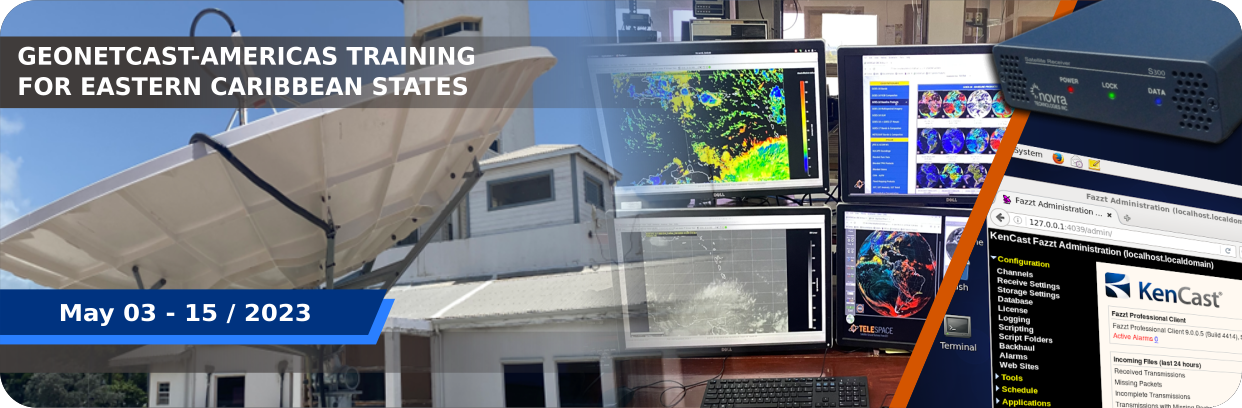

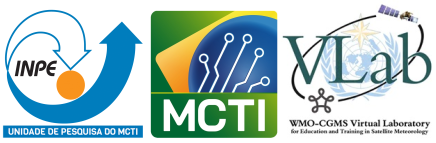

### **Contact:**
####Diego Souza - INPE / CGCT / DISSM - (diego.souza@inpe.br)
To reference this work, please use:
 https://github.com/diegormsouza/Oceanography_Python_May_2022